# INTRODUCTION

Welcome to this Jupyter Notebook, where we dive deep into the exciting world of enhancing NBA game predictions! 🏀📈

The dataset at the heart of this model spans an impressive decade, covering 10 NBA seasons from 2014 to 2023. It's a rich source of box-score statistics and season-wise player ratings, serving as the foundation for our feature-rich predictive model. 📊🏆

This notebook is organized into three key sections, each a vital step in our journey:

1. **Data Preparation, Preprocessing, and Cleaning:**
    - We start with the basics, including some exploratory data analysis (EDA).
    - We identify top-performing players, a crucial step to create the Combined Player Efficiency Rating (PER) feature for each team.
    
    <br> <!-- Add an extra line break here -->
    
2. **Feature Engineering:**
    - Here's where the real magic happens! We engineer a whopping 20 features from our box score stats.
    - We perform rolling averages on the dataset to capture dynamic trends.
    - We also add available information on the next game to bolster our predictions.
    
    <br> <!-- Add an extra line break here -->

3. **Model Training and Evaluation:**
    - We delve into feature selection, ensuring we use the most impactful variables.
    - We've developed a powerful back-testing function for model training and evaluation.
    - We'll showcase the results of our predictions.
    - Last but not least, we leverage the SHAP library to unveil the importance of each feature in driving our model's performance. 📊💡

Get ready for an exciting journey into the world of NBA game prediction, where data science meets the court! 📊🏀🧠

In [1]:
import os
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import RidgeClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix, classification_report
import shap
import joblib

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None) # so we can see all columns in a wide DataFrame
# pd.set_option('display.max_rows', None)

### Load the data that shows player participation in each game

In [2]:
playerParticipation = pd.read_csv(r"C:\Users\User\Dropbox\RU45-Sussex OneDrive\NBA Games Prediction Model\data\parsed_csvs\playerParticipation_csv\playerParticipation_running.csv", index_col=0)
playerParticipation

,Team,Season Year,Player 01,Player 02,Player 03,Player 04,Player 05,Player 06,Player 07,Player 08,Player 09,Player 10,Player 11,Player 12,Player 13,Player 14,Player 15
0,LAL,2024,D'Angelo Russell,Anthony Davis,Austin Reaves,Taurean Prince,LeBron James,Gabe Vincent,Cam Reddish,Christian Wood,Rui Hachimura,Jaxson Hayes,Max Christie,Maxwell Lewis,NaN,NaN,NaN
1,DEN,2024,Nikola Jokić,Kentavious Caldwell-Pope,Aaron Gordon,Jamal Murray,Michael Porter Jr.,Reggie Jackson,Christian Braun,Zeke Nnaji,Peyton Watson,NaN,NaN,NaN,NaN,NaN,NaN
2,PHO,2024,Devin Booker,Kevin Durant,Josh Okogie,Jusuf Nurkić,Grayson Allen,Eric Gordon,Drew Eubanks,Yuta Watanabe,Jordan Goodwin,Nassir Little,NaN,NaN,NaN,NaN,NaN
3,GSW,2024,Klay Thompson,Chris Paul,Stephen Curry,Kevon Looney,Andrew Wiggins,Gary Payton II,Jonathan Kuminga,Dario Šarić,Moses Moody,Cory Joseph,NaN,NaN,NaN,NaN,NaN
4,CLE,2024,Max Strus,Donovan Mitchell,Evan Mobley,Darius Garland,Isaac Okoro,Caris LeVert,Georges Niang,Damian Jones,Ty Jerome,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26195,MIA,2014,LeBron James,Dwyane Wade,Chris Bosh,Rashard Lewis,Mario Chalmers,Ray Allen,Chris Andersen,Norris Cole,James Jones,Toney Douglas,Shane Battier,Udonis Haslem,Greg Oden,NaN,NaN
26196,SAS,2014,Kawhi Leonard,Boris Diaw,Tony Parker,Tim Duncan,Danny Green,Manu Ginóbili,Patty Mills,Tiago Splitter,Matt Bonner,Cory Joseph,Marco Belinelli,Aron Baynes,Jeff Ayres,NaN,NaN
26197,MIA,2014,Chris Bosh,LeBron James,Dwyane Wade,Mario Chalmers,Rashard Lewis,Ray Allen,Norris Cole,Chris Andersen,Udonis Haslem,Shane Battier,Toney Douglas,James Jones,Greg Oden,NaN,NaN
26198,MIA,2014,LeBron James,Chris Bosh,Dwyane Wade,Ray Allen,Rashard Lewis,Chris Andersen,Michael Beasley,Mario Chalmers,Shane Battier,Udonis Haslem,Norris Cole,James Jones,Toney Douglas,NaN,NaN


In [3]:
unique_teams = playerParticipation['Team'].unique()
print(unique_teams)

['LAL' 'DEN' 'PHO' 'GSW' 'CLE' 'BRK' 'OKC' 'CHI' 'ATL' 'CHO' 'WAS' 'IND'
 'POR' 'LAC' 'NOP' 'MEM' 'DET' 'MIA' 'BOS' 'NYK' 'HOU' 'ORL' 'DAL' 'SAS'
 'MIN' 'TOR' 'SAC' 'UTA' 'PHI' 'MIL' 'CHA']


In [4]:
# Replace franchise name from CHA to CHO
playerParticipation['Team'] = playerParticipation['Team'].replace('CHA', 'CHO')

In [5]:
unique_teams = playerParticipation['Team'].unique()
print(unique_teams)

['LAL' 'DEN' 'PHO' 'GSW' 'CLE' 'BRK' 'OKC' 'CHI' 'ATL' 'CHO' 'WAS' 'IND'
 'POR' 'LAC' 'NOP' 'MEM' 'DET' 'MIA' 'BOS' 'NYK' 'HOU' 'ORL' 'DAL' 'SAS'
 'MIN' 'TOR' 'SAC' 'UTA' 'PHI' 'MIL']


### Load the data that shows overall player ratings per season and win-share contribution

In [6]:
players = pd.read_csv(r"C:\Users\User\Dropbox\RU45-Sussex OneDrive\NBA Games Prediction Model\data\parsed_csvs\combined_playerStats_csv\playerStats_running.csv", index_col=0)
players

,Player,Pos,Age,Tm,G,MP,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,Unnamed: 19,OWS,DWS,WS,WS/48,Unnamed: 24,OBPM,DBPM,BPM,VORP,Season Year
Rk,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Quincy Acy,SF,23,TOT,63,847,10.1,0.520,0.106,0.376,9.5,19.5,14.4,4.9,1.4,2.5,15.4,10.1,NaN,0.6,0.9,1.5,0.086,NaN,-2.5,0.8,-1.7,0.1,2014
1,Quincy Acy,SF,23,TOR,7,61,17.2,0.542,0.357,0.571,9.5,19.2,14.3,10.1,3.4,3.9,10.2,14.5,NaN,0.1,0.1,0.2,0.188,NaN,1.2,3.7,5.0,0.1,2014
1,Quincy Acy,SF,23,SAC,56,786,9.6,0.518,0.079,0.354,9.5,19.5,14.4,4.4,1.2,2.4,16.0,9.8,NaN,0.5,0.7,1.3,0.078,NaN,-2.8,0.6,-2.2,0.0,2014
2,Steven Adams,C,20,OKC,81,1197,11.2,0.541,0.000,0.735,14.1,17.1,15.6,4.9,1.7,3.9,22.5,11.7,NaN,0.9,1.9,2.9,0.114,NaN,-3.1,0.9,-2.2,-0.1,2014
3,Jeff Adrien,PF,27,TOT,53,961,17.4,0.553,0.000,0.433,11.8,24.8,18.2,6.8,1.3,3.0,10.6,17.3,NaN,1.6,1.1,2.7,0.134,NaN,0.0,-0.9,-0.9,0.3,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482,Thaddeus Young,PF,35,TOR,3,10,13.2,0.410,0.000,0.500,10.4,22.3,16.2,45.2,0.0,0.0,17.0,24.9,NaN,0.0,0.0,0.0,-0.032,NaN,0.2,0.5,0.7,0.0,2024
483,Trae Young,PG,25,ATL,16,572,20.8,0.564,0.447,0.480,1.9,7.0,4.4,41.7,2.1,0.0,14.6,30.3,NaN,1.5,0.1,1.6,0.138,NaN,5.2,-1.9,3.3,0.8,2024
484,Omer Yurtseven,C,25,UTA,12,129,17.4,0.642,0.282,0.179,13.1,24.6,18.6,9.4,0.8,3.5,14.3,15.7,NaN,0.2,0.1,0.3,0.120,NaN,0.2,-0.5,-0.3,0.1,2024


In [7]:
"""
Creating a feature to determine minutes played per game for each player
"""
players['MPG'] = round(players['MP'] / players['G'], 2)
players

,Player,Pos,Age,Tm,G,MP,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,Unnamed: 19,OWS,DWS,WS,WS/48,Unnamed: 24,OBPM,DBPM,BPM,VORP,Season Year,MPG
Rk,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Quincy Acy,SF,23,TOT,63,847,10.1,0.520,0.106,0.376,9.5,19.5,14.4,4.9,1.4,2.5,15.4,10.1,NaN,0.6,0.9,1.5,0.086,NaN,-2.5,0.8,-1.7,0.1,2014,13.44
1,Quincy Acy,SF,23,TOR,7,61,17.2,0.542,0.357,0.571,9.5,19.2,14.3,10.1,3.4,3.9,10.2,14.5,NaN,0.1,0.1,0.2,0.188,NaN,1.2,3.7,5.0,0.1,2014,8.71
1,Quincy Acy,SF,23,SAC,56,786,9.6,0.518,0.079,0.354,9.5,19.5,14.4,4.4,1.2,2.4,16.0,9.8,NaN,0.5,0.7,1.3,0.078,NaN,-2.8,0.6,-2.2,0.0,2014,14.04
2,Steven Adams,C,20,OKC,81,1197,11.2,0.541,0.000,0.735,14.1,17.1,15.6,4.9,1.7,3.9,22.5,11.7,NaN,0.9,1.9,2.9,0.114,NaN,-3.1,0.9,-2.2,-0.1,2014,14.78
3,Jeff Adrien,PF,27,TOT,53,961,17.4,0.553,0.000,0.433,11.8,24.8,18.2,6.8,1.3,3.0,10.6,17.3,NaN,1.6,1.1,2.7,0.134,NaN,0.0,-0.9,-0.9,0.3,2014,18.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482,Thaddeus Young,PF,35,TOR,3,10,13.2,0.410,0.000,0.500,10.4,22.3,16.2,45.2,0.0,0.0,17.0,24.9,NaN,0.0,0.0,0.0,-0.032,NaN,0.2,0.5,0.7,0.0,2024,3.33
483,Trae Young,PG,25,ATL,16,572,20.8,0.564,0.447,0.480,1.9,7.0,4.4,41.7,2.1,0.0,14.6,30.3,NaN,1.5,0.1,1.6,0.138,NaN,5.2,-1.9,3.3,0.8,2024,35.75
484,Omer Yurtseven,C,25,UTA,12,129,17.4,0.642,0.282,0.179,13.1,24.6,18.6,9.4,0.8,3.5,14.3,15.7,NaN,0.2,0.1,0.3,0.120,NaN,0.2,-0.5,-0.3,0.1,2024,10.75


In [8]:
"""
Create a dataframe with some selected features
"""
playerStats_df = players[["Player", "Tm", "MPG", "PER", "WS/48", "Season Year"]]

In [9]:
playerStats_df.head(20)

,Player,Tm,MPG,PER,WS/48,Season Year
Rk,,,,,,
1,Quincy Acy,TOT,13.44,10.1,0.086,2014
1,Quincy Acy,TOR,8.71,17.2,0.188,2014
1,Quincy Acy,SAC,14.04,9.6,0.078,2014
2,Steven Adams,OKC,14.78,11.2,0.114,2014
3,Jeff Adrien,TOT,18.13,17.4,0.134,2014
3,Jeff Adrien,CHA,10.24,14.9,0.170,2014
3,Jeff Adrien,MIL,25.18,18.4,0.121,2014
4,Arron Afflalo,ORL,34.96,16.0,0.099,2014
5,Alexis Ajinça,NOP,16.98,14.6,0.104,2014


In [10]:
"""
To remove the asterisk character (*) from the "Player" column in the playerStats_df DataFrame, you can use the str.replace() method as follows:
NB, in pandas, asterisk can have a meaning as a regular expression, hence we equate the regex=False 
"""
playerStats_df = playerStats_df.copy()
playerStats_df["Player"] = playerStats_df["Player"].str.replace("*", "", regex=False)

In [11]:
playerStats_df.head(20)

,Player,Tm,MPG,PER,WS/48,Season Year
Rk,,,,,,
1,Quincy Acy,TOT,13.44,10.1,0.086,2014
1,Quincy Acy,TOR,8.71,17.2,0.188,2014
1,Quincy Acy,SAC,14.04,9.6,0.078,2014
2,Steven Adams,OKC,14.78,11.2,0.114,2014
3,Jeff Adrien,TOT,18.13,17.4,0.134,2014
3,Jeff Adrien,CHA,10.24,14.9,0.170,2014
3,Jeff Adrien,MIL,25.18,18.4,0.121,2014
4,Arron Afflalo,ORL,34.96,16.0,0.099,2014
5,Alexis Ajinça,NOP,16.98,14.6,0.104,2014


### Exploring a player - LeBron James through the 10 seasons considered

In [12]:
playerStats_df[playerStats_df["Player"] == "LeBron James"]

,Player,Tm,MPG,PER,WS/48,Season Year
Rk,,,,,,
227,LeBron James,MIA,37.69,29.3,0.264,2014
236,LeBron James,CLE,36.13,25.9,0.199,2015
222,LeBron James,CLE,35.64,27.5,0.242,2016
221,LeBron James,CLE,37.76,27.0,0.221,2017
249,LeBron James,CLE,36.90,28.6,0.221,2018
259,LeBron James,LAL,35.22,25.6,0.179,2019
251,LeBron James,LAL,34.57,25.5,0.204,2020
252,LeBron James,LAL,33.42,24.2,0.179,2021
274,LeBron James,LAL,37.21,26.2,0.172,2022


In [13]:
playerStats_df[playerStats_df["Player"] == "Stephen Curry"]

,Player,Tm,MPG,PER,WS/48,Season Year
Rk,,,,,,
111,Stephen Curry,GSW,36.49,24.1,0.225,2014
112,Stephen Curry,GSW,32.66,28.0,0.288,2015
105,Stephen Curry,GSW,34.18,31.5,0.318,2016
98,Stephen Curry,GSW,33.39,24.6,0.229,2017
120,Stephen Curry,GSW,31.98,28.2,0.267,2018
124,Stephen Curry,GSW,33.78,24.4,0.199,2019
121,Stephen Curry,GSW,27.80,21.7,0.103,2020
116,Stephen Curry,GSW,34.16,26.3,0.201,2021
126,Stephen Curry,GSW,34.55,21.4,0.173,2022


## We see some players appearing more than once in a particular year, showing they played for more than one team. e.g.

In [14]:
playerStats_df.groupby(["Player", "Season Year"])

In [15]:
groupDurant = playerStats_df.groupby(["Player", "Season Year"]).get_group(("Kevin Durant", 2023))
groupDurant

,Player,Tm,MPG,PER,WS/48,Season Year
Rk,,,,,,
137,Kevin Durant,TOT,35.57,25.9,0.194,2023
137,Kevin Durant,BRK,35.97,26.2,0.194,2023
137,Kevin Durant,PHO,33.62,24.3,0.196,2023


In [16]:
"""
Now, we want only their total for that year, deleting other rows
So we write a function to iterate through each group
"""
def single_row(df):
    if df.shape[0]==1:
        return df
    else:
        row = df[df["Tm"]=="TOT"]
        row["Tm"] = df.iloc[-1,:]["Tm"]   # Since TOT is not a valid team, we replace TOT with the name of the last team the player played in
        return row

In [17]:
"""
We copy the groupby, and use the apply method to apply this function to each group
"""
playerStats_df = playerStats_df.groupby(["Player", "Season Year"]).apply(single_row)

In [18]:
# playerStats_df

In [19]:
"""
We now have multilevel indexing from the groupby (Player, Year and the original indexing). 
Dropping the Player and Year multi-index:
"""
playerStats_df.index = playerStats_df.index.droplevel()

playerStats_df.index = playerStats_df.index.droplevel()

playerStats_df

,Player,Tm,MPG,PER,WS/48,Season Year
Rk,,,,,,
174,A.J. Green,MIL,9.86,11.5,0.111,2023
152,A.J. Green,MIL,7.36,9.0,0.057,2024
171,A.J. Hammons,DAL,7.41,8.4,-0.001,2017
284,A.J. Lawson,DAL,7.20,13.9,0.063,2023
360,A.J. Price,MIN,3.54,9.7,-0.012,2014
...,...,...,...,...,...,...
24,Ömer Aşık,HOU,20.17,14.0,0.121,2014
24,Ömer Aşık,NOP,26.08,15.5,0.120,2015
26,Ömer Aşık,NOP,17.32,11.0,0.070,2016


In [20]:
"""
View to ascertain that mumtiple rows have been taken care of for players that played for more than one team in a season
"""
playerStats_df[playerStats_df["Player"] == "Kevin Durant"]

,Player,Tm,MPG,PER,WS/48,Season Year
Rk,,,,,,
134,Kevin Durant,OKC,38.54,29.8,0.295,2014
139,Kevin Durant,OKC,33.81,27.6,0.252,2015
126,Kevin Durant,OKC,35.81,28.2,0.270,2016
119,Kevin Durant,GSW,33.39,27.6,0.278,2017
143,Kevin Durant,GSW,34.19,26.0,0.215,2018
150,Kevin Durant,GSW,34.64,24.2,0.204,2019
140,Kevin Durant,BRK,33.06,26.4,0.206,2021
154,Kevin Durant,BRK,37.22,25.6,0.198,2022
137,Kevin Durant,PHO,35.57,25.9,0.194,2023


### Checking Unique teams in the dataframe

In [21]:
unique_teams = playerStats_df['Tm'].unique()
print(unique_teams)

['MIL' 'DAL' 'MIN' 'PHO' 'ATL' 'DEN' 'CHI' 'IND' 'ORL' 'SAC' 'CHO' 'PHI'
 'HOU' 'BOS' 'OKC' 'WAS' 'CHA' 'NOP' 'POR' 'BRK' 'LAC' 'UTA' 'NYK' 'DET'
 'GSW' 'LAL' 'CLE' 'MEM' 'TOR' 'SAS' 'MIA']


In [22]:
# Replace franchise name from CHA to CHO
playerStats_df['Tm'] = playerStats_df['Tm'].replace('CHA', 'CHO')

In [23]:
unique_teams = playerStats_df['Tm'].unique()
print(unique_teams)

['MIL' 'DAL' 'MIN' 'PHO' 'ATL' 'DEN' 'CHI' 'IND' 'ORL' 'SAC' 'CHO' 'PHI'
 'HOU' 'BOS' 'OKC' 'WAS' 'NOP' 'POR' 'BRK' 'LAC' 'UTA' 'NYK' 'DET' 'GSW'
 'LAL' 'CLE' 'MEM' 'TOR' 'SAS' 'MIA']


In [24]:
"""
To print the roster of a team say the Los Angeles Lakers (LAL) for the year 2020
"""
roster_LAL2020 = playerStats_df[(playerStats_df['Tm'] == 'LAL') & (playerStats_df['Season Year'] == 2020)]
print(roster_LAL2020)

                       Player   Tm    MPG   PER  WS/48  Season Year
Rk                                                                 
93                Alex Caruso  LAL  18.36  10.8  0.095         2020
123             Anthony Davis  LAL  34.37  27.4  0.250         2020
59              Avery Bradley  LAL  24.20   8.9  0.062         2020
186               Danny Green  LAL  24.81  10.8  0.096         2020
84             Devontae Cacok  LAL   9.00  28.6  0.226         2020
494              Dion Waiters  LAL  20.70  11.5  0.030         2020
232             Dwight Howard  LAL  18.93  18.7  0.197         2020
457                J.R. Smith  LAL  13.17   0.0 -0.077         2020
327              JaVale McGee  LAL  16.62  19.4  0.198         2020
141              Jared Dudley  LAL   8.09   7.8  0.102         2020
85   Kentavious Caldwell-Pope  LAL  25.54  11.0  0.102         2020
14       Kostas Antetokounmpo  LAL   4.00  16.3  0.193         2020
282                Kyle Kuzma  LAL  25.02  12.2 

## Creating a dataframe to identify top 5 key players per team
Grouping the new dataset by team and season year

In [25]:
teamGroup = playerStats_df.groupby(["Tm", "Season Year"], group_keys=False)

In [26]:
def sort_Top5_players_by_per(group):
    group_above_26 = group[group['MPG'] >= 26]  # Filter players with MPG >= 26
    group_between_18_26 = group[(group['MPG'] >= 18) & (group['MPG'] < 26)]  # Filter players with MPG between 18 and 26

    if len(group_above_26) >= 5:
        top_players = group_above_26.sort_values("WS/48", ascending=False).head(5)  # Select top five players
    else:
        top_players = group_above_26.sort_values("WS/48", ascending=False)  # Select all players with MPG >= 26

        remaining_count = 5 - len(top_players)
        if len(group_between_18_26) > 0:
            remaining_players = group_between_18_26.sort_values("WS/48", ascending=False).head(remaining_count)
            top_players = pd.concat([top_players, remaining_players])

    # Add new columns for PER of top players
    player_columns = ['Top1', 'Top2', 'Top3', 'Top4', 'Top5']  # Specify the player name columns
    per_columns = ['Top1_PER', 'Top2_PER', 'Top3_PER', 'Top4_PER', 'Top5_PER']  # New columns for PER
    concatenated_stats = top_players.groupby(['Tm', 'Season Year'])['Player'].apply(list).apply(pd.Series).rename(columns=lambda x: player_columns[x]).reset_index().reset_index(drop=True)

    # Add PER values to the new columns
    for i, col in enumerate(player_columns):
        player_names = concatenated_stats[col]
        per_values = group[group['Player'].isin(player_names)]['PER'].values
        concatenated_stats[per_columns[i]] = per_values

    return concatenated_stats

top_five_players_per_team = teamGroup.apply(sort_Top5_players_by_per)
top_five_players_per_team

,Tm,Season Year,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER
0,ATL,2014,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1
0,ATL,2015,Al Horford,Jeff Teague,Paul Millsap,DeMarre Carroll,Kyle Korver,21.4,20.6,20.0,15.9,14.8
0,ATL,2016,Paul Millsap,Al Horford,Jeff Teague,Kent Bazemore,Kyle Korver,21.3,19.4,17.9,13.4,9.7
0,ATL,2017,Dwight Howard,Paul Millsap,Tim Hardaway Jr.,Ersan İlyasova,Dennis Schröder,20.8,17.9,15.2,14.6,16.1
0,ATL,2018,Dennis Schröder,Kent Bazemore,Damion Lee,Taurean Prince,John Collins,17.3,14.5,12.0,12.8,18.3
...,...,...,...,...,...,...,...,...,...,...,...,...
0,WAS,2020,Bradley Beal,Dāvis Bertāns,Rui Hachimura,Ish Smith,Thomas Bryant,23.2,15.5,13.5,13.9,21.1
0,WAS,2021,Thomas Bryant,Bradley Beal,Russell Westbrook,Rui Hachimura,Robin Lopez,18.7,22.7,19.5,11.4,16.7
0,WAS,2022,Kristaps Porziņģis,Kentavious Caldwell-Pope,Bradley Beal,Kyle Kuzma,Daniel Gafford,23.7,12.6,17.5,15.2,21.8
0,WAS,2023,Kristaps Porziņģis,Monte Morris,Bradley Beal,Corey Kispert,Deni Avdija,23.1,15.0,19.7,11.5,11.2


### Rearranging some columns in the dataframe - optional just for aesthetics

In [27]:
# Get the column names of the dataframe
column_names = top_five_players_per_team.columns.tolist()

# Remove 'Tm' and 'Season Year' columns from the list
column_names.remove('Tm')
column_names.remove('Season Year')

# Insert 'Tm' and 'Season Year' columns at the desired position
desired_position = len(column_names)  # Last position
column_names.insert(desired_position, 'Tm')
column_names.insert(desired_position + 1, 'Season Year')

# Reorder the columns in the dataframe
top_five_players_per_team = top_five_players_per_team[column_names]
top_five_players_per_team = top_five_players_per_team.rename(columns={'Tm': 'Team'})
top_five_players_per_team

,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,Team,Season Year
0,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,ATL,2014
0,Al Horford,Jeff Teague,Paul Millsap,DeMarre Carroll,Kyle Korver,21.4,20.6,20.0,15.9,14.8,ATL,2015
0,Paul Millsap,Al Horford,Jeff Teague,Kent Bazemore,Kyle Korver,21.3,19.4,17.9,13.4,9.7,ATL,2016
0,Dwight Howard,Paul Millsap,Tim Hardaway Jr.,Ersan İlyasova,Dennis Schröder,20.8,17.9,15.2,14.6,16.1,ATL,2017
0,Dennis Schröder,Kent Bazemore,Damion Lee,Taurean Prince,John Collins,17.3,14.5,12.0,12.8,18.3,ATL,2018
...,...,...,...,...,...,...,...,...,...,...,...,...
0,Bradley Beal,Dāvis Bertāns,Rui Hachimura,Ish Smith,Thomas Bryant,23.2,15.5,13.5,13.9,21.1,WAS,2020
0,Thomas Bryant,Bradley Beal,Russell Westbrook,Rui Hachimura,Robin Lopez,18.7,22.7,19.5,11.4,16.7,WAS,2021
0,Kristaps Porziņģis,Kentavious Caldwell-Pope,Bradley Beal,Kyle Kuzma,Daniel Gafford,23.7,12.6,17.5,15.2,21.8,WAS,2022
0,Kristaps Porziņģis,Monte Morris,Bradley Beal,Corey Kispert,Deni Avdija,23.1,15.0,19.7,11.5,11.2,WAS,2023


## Merging dataframes

In [28]:
"""
Merge the two dataframes based on team and season-year columns
""" 
merged_df = playerParticipation.merge(top_five_players_per_team, on=['Team', 'Season Year'], how='left')
merged_df

,Team,Season Year,Player 01,Player 02,Player 03,Player 04,Player 05,Player 06,Player 07,Player 08,Player 09,Player 10,Player 11,Player 12,Player 13,Player 14,Player 15,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER
0,LAL,2024,D'Angelo Russell,Anthony Davis,Austin Reaves,Taurean Prince,LeBron James,Gabe Vincent,Cam Reddish,Christian Wood,Rui Hachimura,Jaxson Hayes,Max Christie,Maxwell Lewis,NaN,NaN,NaN,Anthony Davis,LeBron James,D'Angelo Russell,Austin Reaves,Taurean Prince,24.9,24.9,18.2,14.3,7.1
1,DEN,2024,Nikola Jokić,Kentavious Caldwell-Pope,Aaron Gordon,Jamal Murray,Michael Porter Jr.,Reggie Jackson,Christian Braun,Zeke Nnaji,Peyton Watson,NaN,NaN,NaN,NaN,NaN,NaN,Nikola Jokić,Michael Porter Jr.,Jamal Murray,Reggie Jackson,Kentavious Caldwell-Pope,34.6,17.1,16.1,14.9,10.5
2,PHO,2024,Devin Booker,Kevin Durant,Josh Okogie,Jusuf Nurkić,Grayson Allen,Eric Gordon,Drew Eubanks,Yuta Watanabe,Jordan Goodwin,Nassir Little,NaN,NaN,NaN,NaN,NaN,Devin Booker,Kevin Durant,Jusuf Nurkić,Grayson Allen,Eric Gordon,25.4,24.9,17.9,11.8,13.3
3,GSW,2024,Klay Thompson,Chris Paul,Stephen Curry,Kevon Looney,Andrew Wiggins,Gary Payton II,Jonathan Kuminga,Dario Šarić,Moses Moody,Cory Joseph,NaN,NaN,NaN,NaN,NaN,Stephen Curry,Chris Paul,Klay Thompson,Andrew Wiggins,Kevon Looney,23.3,15.5,10.5,8.8,15.5
4,CLE,2024,Max Strus,Donovan Mitchell,Evan Mobley,Darius Garland,Isaac Okoro,Caris LeVert,Georges Niang,Damian Jones,Ty Jerome,NaN,NaN,NaN,NaN,NaN,NaN,Jarrett Allen,Donovan Mitchell,Evan Mobley,Max Strus,Caris LeVert,20.1,23.2,19.7,13.1,13.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26195,MIA,2014,LeBron James,Dwyane Wade,Chris Bosh,Rashard Lewis,Mario Chalmers,Ray Allen,Chris Andersen,Norris Cole,James Jones,Toney Douglas,Shane Battier,Udonis Haslem,Greg Oden,NaN,NaN,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8
26196,SAS,2014,Kawhi Leonard,Boris Diaw,Tony Parker,Tim Duncan,Danny Green,Manu Ginóbili,Patty Mills,Tiago Splitter,Matt Bonner,Cory Joseph,Marco Belinelli,Aron Baynes,Jeff Ayres,NaN,NaN,Kawhi Leonard,Tim Duncan,Tony Parker,Manu Ginóbili,Patty Mills,19.4,21.3,18.9,20.0,18.7
26197,MIA,2014,Chris Bosh,LeBron James,Dwyane Wade,Mario Chalmers,Rashard Lewis,Ray Allen,Norris Cole,Chris Andersen,Udonis Haslem,Shane Battier,Toney Douglas,James Jones,Greg Oden,NaN,NaN,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8
26198,MIA,2014,LeBron James,Chris Bosh,Dwyane Wade,Ray Allen,Rashard Lewis,Chris Andersen,Michael Beasley,Mario Chalmers,Shane Battier,Udonis Haslem,Norris Cole,James Jones,Toney Douglas,NaN,NaN,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8


The provided code below aims to create new columns ('Big5', 'Big4', 'Big3', 'Big2', 'Big1') in the DataFrame merged_df to indicate whether the top 5 players are present in each game.

The code essentially classifies each game based on how many of the top 5 players are present, marking them with 1 in the corresponding 'BigX' column.

In [29]:
# Create new columns
merged_df['Big5'] = 0
merged_df['Big4'] = 0
merged_df['Big3'] = 0
merged_df['Big2'] = 0
merged_df['Big1'] = 0

# Iterate over the rows
for index, row in merged_df.iterrows():
    top_players = [row['Top1'], row['Top2'], row['Top3'], row['Top4'], row['Top5']]
    players_in_game = [row['Player 01'], row['Player 02'], row['Player 03'], row['Player 04'], row['Player 05'], row['Player 06'], row['Player 07'], row['Player 08'], row['Player 09'], row['Player 10'], row['Player 11'], row['Player 12'], row['Player 13'], row['Player 14'], row['Player 15']]

    if all(player in players_in_game for player in top_players):
        merged_df.at[index, 'Big5'] = 1
    elif len(set(players_in_game).intersection(top_players)) == 4:
        merged_df.at[index, 'Big4'] = 1
    elif len(set(players_in_game).intersection(top_players)) == 3:
        merged_df.at[index, 'Big3'] = 1
    elif len(set(players_in_game).intersection(top_players)) == 2:
        merged_df.at[index, 'Big2'] = 1
    elif len(set(players_in_game).intersection(top_players)) == 1:
        merged_df.at[index, 'Big1'] = 1

# Print the resulting dataframe
merged_df

,Team,Season Year,Player 01,Player 02,Player 03,Player 04,Player 05,Player 06,Player 07,Player 08,Player 09,Player 10,Player 11,Player 12,Player 13,Player 14,Player 15,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,Big5,Big4,Big3,Big2,Big1
0,LAL,2024,D'Angelo Russell,Anthony Davis,Austin Reaves,Taurean Prince,LeBron James,Gabe Vincent,Cam Reddish,Christian Wood,Rui Hachimura,Jaxson Hayes,Max Christie,Maxwell Lewis,NaN,NaN,NaN,Anthony Davis,LeBron James,D'Angelo Russell,Austin Reaves,Taurean Prince,24.9,24.9,18.2,14.3,7.1,1,0,0,0,0
1,DEN,2024,Nikola Jokić,Kentavious Caldwell-Pope,Aaron Gordon,Jamal Murray,Michael Porter Jr.,Reggie Jackson,Christian Braun,Zeke Nnaji,Peyton Watson,NaN,NaN,NaN,NaN,NaN,NaN,Nikola Jokić,Michael Porter Jr.,Jamal Murray,Reggie Jackson,Kentavious Caldwell-Pope,34.6,17.1,16.1,14.9,10.5,1,0,0,0,0
2,PHO,2024,Devin Booker,Kevin Durant,Josh Okogie,Jusuf Nurkić,Grayson Allen,Eric Gordon,Drew Eubanks,Yuta Watanabe,Jordan Goodwin,Nassir Little,NaN,NaN,NaN,NaN,NaN,Devin Booker,Kevin Durant,Jusuf Nurkić,Grayson Allen,Eric Gordon,25.4,24.9,17.9,11.8,13.3,1,0,0,0,0
3,GSW,2024,Klay Thompson,Chris Paul,Stephen Curry,Kevon Looney,Andrew Wiggins,Gary Payton II,Jonathan Kuminga,Dario Šarić,Moses Moody,Cory Joseph,NaN,NaN,NaN,NaN,NaN,Stephen Curry,Chris Paul,Klay Thompson,Andrew Wiggins,Kevon Looney,23.3,15.5,10.5,8.8,15.5,1,0,0,0,0
4,CLE,2024,Max Strus,Donovan Mitchell,Evan Mobley,Darius Garland,Isaac Okoro,Caris LeVert,Georges Niang,Damian Jones,Ty Jerome,NaN,NaN,NaN,NaN,NaN,NaN,Jarrett Allen,Donovan Mitchell,Evan Mobley,Max Strus,Caris LeVert,20.1,23.2,19.7,13.1,13.7,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26195,MIA,2014,LeBron James,Dwyane Wade,Chris Bosh,Rashard Lewis,Mario Chalmers,Ray Allen,Chris Andersen,Norris Cole,James Jones,Toney Douglas,Shane Battier,Udonis Haslem,Greg Oden,NaN,NaN,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8,1,0,0,0,0
26196,SAS,2014,Kawhi Leonard,Boris Diaw,Tony Parker,Tim Duncan,Danny Green,Manu Ginóbili,Patty Mills,Tiago Splitter,Matt Bonner,Cory Joseph,Marco Belinelli,Aron Baynes,Jeff Ayres,NaN,NaN,Kawhi Leonard,Tim Duncan,Tony Parker,Manu Ginóbili,Patty Mills,19.4,21.3,18.9,20.0,18.7,1,0,0,0,0
26197,MIA,2014,Chris Bosh,LeBron James,Dwyane Wade,Mario Chalmers,Rashard Lewis,Ray Allen,Norris Cole,Chris Andersen,Udonis Haslem,Shane Battier,Toney Douglas,James Jones,Greg Oden,NaN,NaN,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8,1,0,0,0,0
26198,MIA,2014,LeBron James,Chris Bosh,Dwyane Wade,Ray Allen,Rashard Lewis,Chris Andersen,Michael Beasley,Mario Chalmers,Shane Battier,Udonis Haslem,Norris Cole,James Jones,Toney Douglas,NaN,NaN,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8,1,0,0,0,0


In [30]:
# Create new column 'PER_Combined'
merged_df['PER_Combined'] = 0

# Iterate over the rows
for index, row in merged_df.iterrows():
    top_players = [row['Top1'], row['Top2'], row['Top3'], row['Top4'], row['Top5']]
    players_in_game = [row[f'Player {i:02d}'] for i in range(1, 16)]

    # Get the common players between the top players and players in the game
    common_players = set(top_players).intersection(players_in_game)

    # Sum the PER values of the common players in the game roster
    per_values = [row[f'Top{i}_PER'] for i in range(1, 6) if row[f'Top{i}'] in common_players]
    merged_df.at[index, 'PER_Combined'] = sum(per_values)
        
# Print the resulting dataframe
merged_df

,Team,Season Year,Player 01,Player 02,Player 03,Player 04,Player 05,Player 06,Player 07,Player 08,Player 09,Player 10,Player 11,Player 12,Player 13,Player 14,Player 15,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,Big5,Big4,Big3,Big2,Big1,PER_Combined
0,LAL,2024,D'Angelo Russell,Anthony Davis,Austin Reaves,Taurean Prince,LeBron James,Gabe Vincent,Cam Reddish,Christian Wood,Rui Hachimura,Jaxson Hayes,Max Christie,Maxwell Lewis,NaN,NaN,NaN,Anthony Davis,LeBron James,D'Angelo Russell,Austin Reaves,Taurean Prince,24.9,24.9,18.2,14.3,7.1,1,0,0,0,0,89.4
1,DEN,2024,Nikola Jokić,Kentavious Caldwell-Pope,Aaron Gordon,Jamal Murray,Michael Porter Jr.,Reggie Jackson,Christian Braun,Zeke Nnaji,Peyton Watson,NaN,NaN,NaN,NaN,NaN,NaN,Nikola Jokić,Michael Porter Jr.,Jamal Murray,Reggie Jackson,Kentavious Caldwell-Pope,34.6,17.1,16.1,14.9,10.5,1,0,0,0,0,93.2
2,PHO,2024,Devin Booker,Kevin Durant,Josh Okogie,Jusuf Nurkić,Grayson Allen,Eric Gordon,Drew Eubanks,Yuta Watanabe,Jordan Goodwin,Nassir Little,NaN,NaN,NaN,NaN,NaN,Devin Booker,Kevin Durant,Jusuf Nurkić,Grayson Allen,Eric Gordon,25.4,24.9,17.9,11.8,13.3,1,0,0,0,0,93.3
3,GSW,2024,Klay Thompson,Chris Paul,Stephen Curry,Kevon Looney,Andrew Wiggins,Gary Payton II,Jonathan Kuminga,Dario Šarić,Moses Moody,Cory Joseph,NaN,NaN,NaN,NaN,NaN,Stephen Curry,Chris Paul,Klay Thompson,Andrew Wiggins,Kevon Looney,23.3,15.5,10.5,8.8,15.5,1,0,0,0,0,73.6
4,CLE,2024,Max Strus,Donovan Mitchell,Evan Mobley,Darius Garland,Isaac Okoro,Caris LeVert,Georges Niang,Damian Jones,Ty Jerome,NaN,NaN,NaN,NaN,NaN,NaN,Jarrett Allen,Donovan Mitchell,Evan Mobley,Max Strus,Caris LeVert,20.1,23.2,19.7,13.1,13.7,0,1,0,0,0,69.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26195,MIA,2014,LeBron James,Dwyane Wade,Chris Bosh,Rashard Lewis,Mario Chalmers,Ray Allen,Chris Andersen,Norris Cole,James Jones,Toney Douglas,Shane Battier,Udonis Haslem,Greg Oden,NaN,NaN,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8,1,0,0,0,0,97.1
26196,SAS,2014,Kawhi Leonard,Boris Diaw,Tony Parker,Tim Duncan,Danny Green,Manu Ginóbili,Patty Mills,Tiago Splitter,Matt Bonner,Cory Joseph,Marco Belinelli,Aron Baynes,Jeff Ayres,NaN,NaN,Kawhi Leonard,Tim Duncan,Tony Parker,Manu Ginóbili,Patty Mills,19.4,21.3,18.9,20.0,18.7,1,0,0,0,0,98.3
26197,MIA,2014,Chris Bosh,LeBron James,Dwyane Wade,Mario Chalmers,Rashard Lewis,Ray Allen,Norris Cole,Chris Andersen,Udonis Haslem,Shane Battier,Toney Douglas,James Jones,Greg Oden,NaN,NaN,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8,1,0,0,0,0,97.1
26198,MIA,2014,LeBron James,Chris Bosh,Dwyane Wade,Ray Allen,Rashard Lewis,Chris Andersen,Michael Beasley,Mario Chalmers,Shane Battier,Udonis Haslem,Norris Cole,James Jones,Toney Douglas,NaN,NaN,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8,1,0,0,0,0,97.1


In [31]:
# Sum the values in the Big5, Big4, Big3, Big2, and Big1 columns
big5_sum = merged_df['Big5'].sum()
big4_sum = merged_df['Big4'].sum()
big3_sum = merged_df['Big3'].sum()
big2_sum = merged_df['Big2'].sum()
big1_sum = merged_df['Big1'].sum()

print("Sum of Big5 column:", big5_sum)
print("Sum of Big4 column:", big4_sum)
print("Sum of Big3 column:", big3_sum)
print("Sum of Big2 column:", big2_sum)
print("Sum of Big1 column:", big1_sum)

Sum of Big5 column: 9389
Sum of Big4 column: 9944
Sum of Big3 column: 4723
Sum of Big2 column: 1527
Sum of Big1 column: 519


In [32]:
Big5_df = merged_df[["Team", "Season Year", 'Top1', 'Top2', 'Top3', 'Top4', 'Top5', 'Top1_PER', 'Top2_PER', 'Top3_PER', 'Top4_PER', 'Top5_PER', 'Big5', 'Big4', 'Big3', 'Big2', 'Big1', 'PER_Combined']]
Big5_df

,Team,Season Year,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,Big5,Big4,Big3,Big2,Big1,PER_Combined
0,LAL,2024,Anthony Davis,LeBron James,D'Angelo Russell,Austin Reaves,Taurean Prince,24.9,24.9,18.2,14.3,7.1,1,0,0,0,0,89.4
1,DEN,2024,Nikola Jokić,Michael Porter Jr.,Jamal Murray,Reggie Jackson,Kentavious Caldwell-Pope,34.6,17.1,16.1,14.9,10.5,1,0,0,0,0,93.2
2,PHO,2024,Devin Booker,Kevin Durant,Jusuf Nurkić,Grayson Allen,Eric Gordon,25.4,24.9,17.9,11.8,13.3,1,0,0,0,0,93.3
3,GSW,2024,Stephen Curry,Chris Paul,Klay Thompson,Andrew Wiggins,Kevon Looney,23.3,15.5,10.5,8.8,15.5,1,0,0,0,0,73.6
4,CLE,2024,Jarrett Allen,Donovan Mitchell,Evan Mobley,Max Strus,Caris LeVert,20.1,23.2,19.7,13.1,13.7,0,1,0,0,0,69.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26195,MIA,2014,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8,1,0,0,0,0,97.1
26196,SAS,2014,Kawhi Leonard,Tim Duncan,Tony Parker,Manu Ginóbili,Patty Mills,19.4,21.3,18.9,20.0,18.7,1,0,0,0,0,98.3
26197,MIA,2014,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8,1,0,0,0,0,97.1
26198,MIA,2014,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8,1,0,0,0,0,97.1


## We try to combine both team data on the same row

In [33]:
# Drop all alternate rows from Big5_df and create a new DataFrame called home_teamStats
home_teamStats = Big5_df.iloc[1::2].reset_index(drop=True)

# # Rename columns with "_opp" suffix (excluding 'Season Year')
# home_teamStats.rename(columns={col: f'{col}_home' for col in home_teamStats.columns if col != 'Season Year'}, inplace=True)

# # Print the extracted DataFrame
# home_teamStats

# Drop all alternate rows from Big5_df and create a new DataFrame called away_teamStats
away_teamStats = Big5_df.iloc[::2].reset_index(drop=True)

# Rename columns with "_opp" suffix (excluding 'Season Year')
away_teamStats.rename(columns={col: f'{col}_opp' for col in away_teamStats.columns if col != 'Season Year'}, inplace=True)

# # Print the extracted DataFrame
# away_teamStats

Big5_df = pd.concat([home_teamStats, away_teamStats], axis=1)
Big5_df

,Team,Season Year,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,Big5,Big4,Big3,Big2,Big1,PER_Combined,Team_opp,Season Year,Top1_opp,Top2_opp,Top3_opp,Top4_opp,Top5_opp,Top1_PER_opp,Top2_PER_opp,Top3_PER_opp,Top4_PER_opp,Top5_PER_opp,Big5_opp,Big4_opp,Big3_opp,Big2_opp,Big1_opp,PER_Combined_opp
0,DEN,2024,Nikola Jokić,Michael Porter Jr.,Jamal Murray,Reggie Jackson,Kentavious Caldwell-Pope,34.6,17.1,16.1,14.9,10.5,1,0,0,0,0,93.2,LAL,2024,Anthony Davis,LeBron James,D'Angelo Russell,Austin Reaves,Taurean Prince,24.9,24.9,18.2,14.3,7.1,1,0,0,0,0,89.4
1,GSW,2024,Stephen Curry,Chris Paul,Klay Thompson,Andrew Wiggins,Kevon Looney,23.3,15.5,10.5,8.8,15.5,1,0,0,0,0,73.6,PHO,2024,Devin Booker,Kevin Durant,Jusuf Nurkić,Grayson Allen,Eric Gordon,25.4,24.9,17.9,11.8,13.3,1,0,0,0,0,93.3
2,BRK,2024,Nic Claxton,Cameron Johnson,Spencer Dinwiddie,Cam Thomas,Mikal Bridges,22.9,17.0,15.7,21.5,18.0,1,0,0,0,0,95.1,CLE,2024,Jarrett Allen,Donovan Mitchell,Evan Mobley,Max Strus,Caris LeVert,20.1,23.2,19.7,13.1,13.7,0,1,0,0,0,69.7
3,CHI,2024,DeMar DeRozan,Zach LaVine,Nikola Vučević,Coby White,Alex Caruso,19.0,16.2,15.2,11.6,18.3,1,0,0,0,0,80.3,OKC,2024,Shai Gilgeous-Alexander,Chet Holmgren,Luguentz Dort,Jalen Williams,Josh Giddey,30.8,22.5,11.4,13.8,12.3,1,0,0,0,0,90.8
4,CHO,2024,Mark Williams,Miles Bridges,LaMelo Ball,Brandon Miller,P.J. Washington,23.9,17.5,20.8,12.3,11.5,0,1,0,0,0,68.5,ATL,2024,Trae Young,Jalen Johnson,Bogdan Bogdanović,Saddiq Bey,De'Andre Hunter,20.8,17.4,17.0,14.2,12.4,1,0,0,0,0,81.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13095,SAS,2014,Kawhi Leonard,Tim Duncan,Tony Parker,Manu Ginóbili,Patty Mills,19.4,21.3,18.9,20.0,18.7,1,0,0,0,0,98.3,MIA,2014,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8,1,0,0,0,0,97.1
13096,SAS,2014,Kawhi Leonard,Tim Duncan,Tony Parker,Manu Ginóbili,Patty Mills,19.4,21.3,18.9,20.0,18.7,1,0,0,0,0,98.3,MIA,2014,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8,1,0,0,0,0,97.1
13097,MIA,2014,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8,1,0,0,0,0,97.1,SAS,2014,Kawhi Leonard,Tim Duncan,Tony Parker,Manu Ginóbili,Patty Mills,19.4,21.3,18.9,20.0,18.7,1,0,0,0,0,98.3
13098,MIA,2014,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8,1,0,0,0,0,97.1,SAS,2014,Kawhi Leonard,Tim Duncan,Tony Parker,Manu Ginóbili,Patty Mills,19.4,21.3,18.9,20.0,18.7,1,0,0,0,0,98.3


## Loading the nba_games.csv file

In [34]:
game_df = pd.read_csv(r"C:\Users\User\Dropbox\RU45-Sussex OneDrive\NBA Games Prediction Model\data\parsed_csvs\scores_csv\nba_games_running.csv", index_col=0)
game_df[game_df['season']==2024]

,mp,mp.1,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,orb,drb,trb,ast,stl,blk,tov,pf,pts,+/-,ts%,efg%,3par,ftr,orb%,drb%,trb%,ast%,stl%,blk%,tov%,usg%,ortg,drtg,mp_max,mp_max.1,fg_max,fga_max,fg%_max,3p_max,3pa_max,3p%_max,ft_max,fta_max,ft%_max,orb_max,drb_max,trb_max,ast_max,stl_max,blk_max,tov_max,pf_max,pts_max,+/-_max,ts%_max,efg%_max,3par_max,ftr_max,orb%_max,drb%_max,trb%_max,ast%_max,stl%_max,blk%_max,tov%_max,usg%_max,ortg_max,drtg_max,team,total,home,index_opp,mp_opp,mp_opp.1,fg_opp,fga_opp,fg%_opp,3p_opp,3pa_opp,3p%_opp,ft_opp,fta_opp,ft%_opp,orb_opp,drb_opp,trb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,pts_opp,+/-_opp,ts%_opp,efg%_opp,3par_opp,ftr_opp,orb%_opp,drb%_opp,trb%_opp,ast%_opp,stl%_opp,blk%_opp,tov%_opp,usg%_opp,ortg_opp,drtg_opp,mp_max_opp,mp_max_opp.1,fg_max_opp,fga_max_opp,fg%_max_opp,3p_max_opp,3pa_max_opp,3p%_max_opp,ft_max_opp,fta_max_opp,ft%_max_opp,orb_max_opp,drb_max_opp,trb_max_opp,ast_max_opp,stl_max_opp,blk_max_opp,tov_max_opp,pf_max_opp,pts_max_opp,+/-_max_opp,ts%_max_opp,efg%_max_opp,3par_max_opp,ftr_max_opp,orb%_max_opp,drb%_max_opp,trb%_max_opp,ast%_max_opp,stl%_max_opp,blk%_max_opp,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won
0,240.0,240.0,41.0,90.0,0.456,10.0,29.0,0.345,15.0,20.0,0.750,13.0,31.0,44.0,23.0,5.0,4.0,11.0,18.0,107.0,NaN,0.541,0.511,0.322,0.222,28.3,77.5,51.2,56.1,5.2,7.0,10.0,100.0,112.3,124.8,NaN,NaN,10.0,17.0,0.750,4.0,6.0,0.667,5.0,7.0,1.0,4.0,7.0,8.0,7.0,2.0,2.0,3.0,3.0,21.0,7.0,1.014,1.000,0.75,0.636,14.2,29.0,15.4,33.9,3.2,4.9,20.0,29.8,175.0,131.0,LAL,107.0,0,1,240.0,240.0,48.0,91.0,0.527,14.0,34.0,0.412,9.0,12.0,0.750,9.0,33.0,42.0,29.0,9.0,6.0,11.0,15.0,119.0,NaN,0.618,0.604,0.374,0.132,22.5,71.7,48.8,60.4,9.4,9.8,10.3,100.0,124.8,112.3,NaN,NaN,12.0,22.0,1.000,3.0,9.0,0.667,2.0,4.0,1.0,3.0,10.0,13.0,11.0,3.0,1.0,3.0,5.0,29.0,15.0,1.000,1.000,1.00,0.667,9.9,34.6,22.2,45.3,4.2,7.3,25.0,62.4,200.0,123.0,DEN,119.0,1,2024,2023-10-24,False
1,240.0,240.0,48.0,91.0,0.527,14.0,34.0,0.412,9.0,12.0,0.750,9.0,33.0,42.0,29.0,9.0,6.0,11.0,15.0,119.0,NaN,0.618,0.604,0.374,0.132,22.5,71.7,48.8,60.4,9.4,9.8,10.3,100.0,124.8,112.3,NaN,NaN,12.0,22.0,1.000,3.0,9.0,0.667,2.0,4.0,1.0,3.0,10.0,13.0,11.0,3.0,1.0,3.0,5.0,29.0,15.0,1.000,1.000,1.00,0.667,9.9,34.6,22.2,45.3,4.2,7.3,25.0,62.4,200.0,123.0,DEN,119.0,1,0,240.0,240.0,41.0,90.0,0.456,10.0,29.0,0.345,15.0,20.0,0.750,13.0,31.0,44.0,23.0,5.0,4.0,11.0,18.0,107.0,NaN,0.541,0.511,0.322,0.222,28.3,77.5,51.2,56.1,5.2,7.0,10.0,100.0,112.3,124.8,NaN,NaN,10.0,17.0,0.750,4.0,6.0,0.667,5.0,7.0,1.0,4.0,7.0,8.0,7.0,2.0,2.0,3.0,3.0,21.0,7.0,1.014,1.000,0.75,0.636,14.2,29.0,15.4,33.9,3.2,4.9,20.0,29.8,175.0,131.0,LAL,107.0,0,2024,2023-10-24,True
2,240.0,240.0,42.0,95.0,0.442,11.0,33.0,0.333,13.0,17.0,0.765,17.0,43.0,60.0,23.0,5.0,7.0,19.0,22.0,108.0,NaN,0.527,0.500,0.347,0.179,35.4,70.5,55.0,54.8,4.9,12.1,15.6,100.0,106.2,102.3,NaN,NaN,13.0,22.0,1.000,3.0,9.0,1.000,3.0,5.0,1.0,4.0,11.0,14.0,8.0,1.0,3.0,6.0,5.0,32.0,7.0,1.500,1.500,1.00,1.333,14.3,31.1,22.1,41.4,16.4,12.9,38.7,30.3,300.0,112.0,PHO,108.0,0,1,240.0,240.0,36.0,101.0,0.356,10.0,43.0,0.233,22.0,28.0,0.786,18.0,31.0,49.0,19.0,11.0,6.0,11.0,23.0,104.0,NaN,0.459,0.406,0.426,0.277,29.5,64.6,45.0,52.8,10.8,9.7,8.8,100.0,102.3,106.2,NaN,NaN,8.0,20.0,0.667,4.0,14.0,0.500,7.0,7.0,1.0,5.0,6.0,11.0,9.0,3.0,2.0,3.0,5.0,27.0,15.0,0.799,0.833,0.70,0.750,21.3,21.5,17.3,41.5,7.9,7.7,23.7,31.5,225.0,118.0,GSW,104.0,1,2024,2023-10-24,True
3,240.0,240.0,36.0,101.0,0.356,10.0,43.0,0.233,22.0,28.0,0.786,18.0,31.0,49.0,19.0,11.0,6.0,11.0,23.0,104.0,NaN,0.459,0.406,0.426,0.277,29.5,64.6,45.0,52.8,10.8,9.7,8.8,100.0,102.3,106.2,NaN,NaN,8.0,20.0,0.667,4.0,14.0,0.500,7.0,7.0,1.0,5.0,6.0,11.0,9.0,3.0,2.0,3.0,5.0,27.0,15.0,0.799,0.833,0.70,0.750,21.3,21.5,17.3,41.5,7.9,7.7,23.7,31.5,225.0,118.0,GSW,104.0,1,0,240.0,240.0,42.0,95.0,0.442,11.0,33.0,0.333,13.0,17.0,0.765,17.0,43.0,60.0,23.0,5.0,7.0,19.0,22.0,108.0,NaN,0.527,0.500,0.347,0.179,35.4,70.5,55.0,54.8,4.9,12.1,15.6,100

In [35]:
# Drop all alternate rows from Big5_df and create a new DataFrame called home_teamStats
game_df_home = game_df.iloc[1::2].reset_index(drop=True)

# Print the extracted DataFrame
game_df_home

,mp,mp.1,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,orb,drb,trb,ast,stl,blk,tov,pf,pts,+/-,ts%,efg%,3par,ftr,orb%,drb%,trb%,ast%,stl%,blk%,tov%,usg%,ortg,drtg,mp_max,mp_max.1,fg_max,fga_max,fg%_max,3p_max,3pa_max,3p%_max,ft_max,fta_max,ft%_max,orb_max,drb_max,trb_max,ast_max,stl_max,blk_max,tov_max,pf_max,pts_max,+/-_max,ts%_max,efg%_max,3par_max,ftr_max,orb%_max,drb%_max,trb%_max,ast%_max,stl%_max,blk%_max,tov%_max,usg%_max,ortg_max,drtg_max,team,total,home,index_opp,mp_opp,mp_opp.1,fg_opp,fga_opp,fg%_opp,3p_opp,3pa_opp,3p%_opp,ft_opp,fta_opp,ft%_opp,orb_opp,drb_opp,trb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,pts_opp,+/-_opp,ts%_opp,efg%_opp,3par_opp,ftr_opp,orb%_opp,drb%_opp,trb%_opp,ast%_opp,stl%_opp,blk%_opp,tov%_opp,usg%_opp,ortg_opp,drtg_opp,mp_max_opp,mp_max_opp.1,fg_max_opp,fga_max_opp,fg%_max_opp,3p_max_opp,3pa_max_opp,3p%_max_opp,ft_max_opp,fta_max_opp,ft%_max_opp,orb_max_opp,drb_max_opp,trb_max_opp,ast_max_opp,stl_max_opp,blk_max_opp,tov_max_opp,pf_max_opp,pts_max_opp,+/-_max_opp,ts%_max_opp,efg%_max_opp,3par_max_opp,ftr_max_opp,orb%_max_opp,drb%_max_opp,trb%_max_opp,ast%_max_opp,stl%_max_opp,blk%_max_opp,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won
0,240.0,240.0,48.0,91.0,0.527,14.0,34.0,0.412,9.0,12.0,0.750,9.0,33.0,42.0,29.0,9.0,6.0,11.0,15.0,119.0,NaN,0.618,0.604,0.374,0.132,22.5,71.7,48.8,60.4,9.4,9.8,10.3,100.0,124.8,112.3,NaN,NaN,12.0,22.0,1.000,3.0,9.0,0.667,2.0,4.0,1.0,3.0,10.0,13.0,11.0,3.0,1.0,3.0,5.0,29.0,15.0,1.000,1.000,1.000,0.667,9.9,34.6,22.2,45.3,4.2,7.3,25.0,62.4,200.0,123.0,DEN,119.0,1,0,240.0,240.0,41.0,90.0,0.456,10.0,29.0,0.345,15.0,20.0,0.750,13.0,31.0,44.0,23.0,5.0,4.0,11.0,18.0,107.0,NaN,0.541,0.511,0.322,0.222,28.3,77.5,51.2,56.1,5.2,7.0,10.0,100.0,112.3,124.8,NaN,NaN,10.0,17.0,0.750,4.0,6.0,0.667,5.0,7.0,1.0,4.0,7.0,8.0,7.0,2.0,2.0,3.0,3.0,21.0,7.0,1.014,1.000,0.750,0.636,14.2,29.0,15.4,33.9,3.2,4.9,20.0,29.8,175.0,131.0,LAL,107.0,0,2024,2023-10-24,True
1,240.0,240.0,36.0,101.0,0.356,10.0,43.0,0.233,22.0,28.0,0.786,18.0,31.0,49.0,19.0,11.0,6.0,11.0,23.0,104.0,NaN,0.459,0.406,0.426,0.277,29.5,64.6,45.0,52.8,10.8,9.7,8.8,100.0,102.3,106.2,NaN,NaN,8.0,20.0,0.667,4.0,14.0,0.500,7.0,7.0,1.0,5.0,6.0,11.0,9.0,3.0,2.0,3.0,5.0,27.0,15.0,0.799,0.833,0.700,0.750,21.3,21.5,17.3,41.5,7.9,7.7,23.7,31.5,225.0,118.0,GSW,104.0,1,0,240.0,240.0,42.0,95.0,0.442,11.0,33.0,0.333,13.0,17.0,0.765,17.0,43.0,60.0,23.0,5.0,7.0,19.0,22.0,108.0,NaN,0.527,0.500,0.347,0.179,35.4,70.5,55.0,54.8,4.9,12.1,15.6,100.0,106.2,102.3,NaN,NaN,13.0,22.0,1.000,3.0,9.0,1.000,3.0,5.0,1.0,4.0,11.0,14.0,8.0,1.0,3.0,6.0,5.0,32.0,7.0,1.500,1.500,1.000,1.333,14.3,31.1,22.1,41.4,16.4,12.9,38.7,30.3,300.0,112.0,PHO,108.0,0,2024,2023-10-24,False
2,240.0,240.0,42.0,84.0,0.500,9.0,27.0,0.333,20.0,26.0,0.769,13.0,37.0,50.0,30.0,6.0,6.0,17.0,16.0,113.0,NaN,0.592,0.554,0.321,0.310,31.0,80.4,56.8,71.4,6.2,11.8,15.1,100.0,115.9,116.9,NaN,NaN,13.0,21.0,0.800,2.0,6.0,0.667,8.0,11.0,1.0,4.0,9.0,10.0,9.0,3.0,3.0,3.0,4.0,36.0,8.0,1.000,1.000,1.000,0.750,16.2,40.9,23.7,49.7,4.2,15.8,50.0,45.6,154.0,125.0,BRK,113.0,1,0,240.0,240.0,44.0,94.0,0.468,17.0,43.0,0.395,9.0,10.0,0.900,9.0,29.0,38.0,25.0,10.0,6.0,10.0,23.0,114.0,NaN,0.579,0.559,0.457,0.106,19.6,69.0,43.2,56.8,10.3,10.5,9.2,100.0,116.9,115.9,NaN,NaN,11.0,21.0,1.000,7.0,13.0,0.538,4.0,5.0,1.0,3.0,12.0,12.0,6.0,4.0,2.0,6.0,5.0,27.0,13.0,1.000,1.000,1.000,0.500,10.6,35.2,16.8,27.6,5.5,5.0,50.0,26.6,200.0,125.0,CLE,114.0,0,2024,2023-10-25,False
3,240.0,240.0,39.0,94.0,0.415,12.0,42.0,0.286,14.0,18.0,0.778,13.0,29.0,42.0,26.0,10.0,3.0,12.0,16.0,104.0,NaN,0.510,0.479,0.447,0.191,25.5,85.3,49.4,66.7,10.2,7.0,10.5,100.0,105.8,126.2,NaN,NaN,9.0,20.0,0.750,3.0,9.0,0.750,6.0,6.0,1.0,4.0,8.0,9.0,4.0,3.0,2.0,4.0,3.0,20.0,3.0,0.917,0.917,1.000,0.429,17.7,77.0,30.8,33.6,5.3,7.0,32.2,38.6,155.0,134.0,CHI,104.0,1,0,240.0,240.0,45.0,82.0,0.549,19.0,39.0,0.487,15.0,18.0,0.833,5.0,38.0,43.0,30.0,6.0,4.0,15.0,19.0,124.0,NaN,0.690,0.665,0.476,0.220,14.7,74.5,50.6,66.7,6.1,7.7

In [36]:
combined_df = pd.concat([game_df_home, Big5_df], axis=1)
combined_df

,mp,mp.1,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,orb,drb,trb,ast,stl,blk,tov,pf,pts,+/-,ts%,efg%,3par,ftr,orb%,drb%,trb%,ast%,stl%,blk%,tov%,usg%,ortg,drtg,mp_max,mp_max.1,fg_max,fga_max,fg%_max,3p_max,3pa_max,3p%_max,ft_max,fta_max,ft%_max,orb_max,drb_max,trb_max,ast_max,stl_max,blk_max,tov_max,pf_max,pts_max,+/-_max,ts%_max,efg%_max,3par_max,ftr_max,orb%_max,drb%_max,trb%_max,ast%_max,stl%_max,blk%_max,tov%_max,usg%_max,ortg_max,drtg_max,team,total,home,index_opp,mp_opp,mp_opp.1,fg_opp,fga_opp,fg%_opp,3p_opp,3pa_opp,3p%_opp,ft_opp,fta_opp,ft%_opp,orb_opp,drb_opp,trb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,pts_opp,+/-_opp,ts%_opp,efg%_opp,3par_opp,ftr_opp,orb%_opp,drb%_opp,trb%_opp,ast%_opp,stl%_opp,blk%_opp,tov%_opp,usg%_opp,ortg_opp,drtg_opp,mp_max_opp,mp_max_opp.1,fg_max_opp,fga_max_opp,fg%_max_opp,3p_max_opp,3pa_max_opp,3p%_max_opp,ft_max_opp,fta_max_opp,ft%_max_opp,orb_max_opp,drb_max_opp,trb_max_opp,ast_max_opp,stl_max_opp,blk_max_opp,tov_max_opp,pf_max_opp,pts_max_opp,+/-_max_opp,ts%_max_opp,efg%_max_opp,3par_max_opp,ftr_max_opp,orb%_max_opp,drb%_max_opp,trb%_max_opp,ast%_max_opp,stl%_max_opp,blk%_max_opp,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won,Team,Season Year,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,Big5,Big4,Big3,Big2,Big1,PER_Combined,Team_opp,Season Year,Top1_opp,Top2_opp,Top3_opp,Top4_opp,Top5_opp,Top1_PER_opp,Top2_PER_opp,Top3_PER_opp,Top4_PER_opp,Top5_PER_opp,Big5_opp,Big4_opp,Big3_opp,Big2_opp,Big1_opp,PER_Combined_opp
0,240.0,240.0,48.0,91.0,0.527,14.0,34.0,0.412,9.0,12.0,0.750,9.0,33.0,42.0,29.0,9.0,6.0,11.0,15.0,119.0,NaN,0.618,0.604,0.374,0.132,22.5,71.7,48.8,60.4,9.4,9.8,10.3,100.0,124.8,112.3,NaN,NaN,12.0,22.0,1.000,3.0,9.0,0.667,2.0,4.0,1.0,3.0,10.0,13.0,11.0,3.0,1.0,3.0,5.0,29.0,15.0,1.000,1.000,1.000,0.667,9.9,34.6,22.2,45.3,4.2,7.3,25.0,62.4,200.0,123.0,DEN,119.0,1,0,240.0,240.0,41.0,90.0,0.456,10.0,29.0,0.345,15.0,20.0,0.750,13.0,31.0,44.0,23.0,5.0,4.0,11.0,18.0,107.0,NaN,0.541,0.511,0.322,0.222,28.3,77.5,51.2,56.1,5.2,7.0,10.0,100.0,112.3,124.8,NaN,NaN,10.0,17.0,0.750,4.0,6.0,0.667,5.0,7.0,1.0,4.0,7.0,8.0,7.0,2.0,2.0,3.0,3.0,21.0,7.0,1.014,1.000,0.750,0.636,14.2,29.0,15.4,33.9,3.2,4.9,20.0,29.8,175.0,131.0,LAL,107.0,0,2024,2023-10-24,True,DEN,2024,Nikola Jokić,Michael Porter Jr.,Jamal Murray,Reggie Jackson,Kentavious Caldwell-Pope,34.6,17.1,16.1,14.9,10.5,1,0,0,0,0,93.2,LAL,2024,Anthony Davis,LeBron James,D'Angelo Russell,Austin Reaves,Taurean Prince,24.9,24.9,18.2,14.3,7.1,1,0,0,0,0,89.4
1,240.0,240.0,36.0,101.0,0.356,10.0,43.0,0.233,22.0,28.0,0.786,18.0,31.0,49.0,19.0,11.0,6.0,11.0,23.0,104.0,NaN,0.459,0.406,0.426,0.277,29.5,64.6,45.0,52.8,10.8,9.7,8.8,100.0,102.3,106.2,NaN,NaN,8.0,20.0,0.667,4.0,14.0,0.500,7.0,7.0,1.0,5.0,6.0,11.0,9.0,3.0,2.0,3.0,5.0,27.0,15.0,0.799,0.833,0.700,0.750,21.3,21.5,17.3,41.5,7.9,7.7,23.7,31.5,225.0,118.0,GSW,104.0,1,0,240.0,240.0,42.0,95.0,0.442,11.0,33.0,0.333,13.0,17.0,0.765,17.0,43.0,60.0,23.0,5.0,7.0,19.0,22.0,108.0,NaN,0.527,0.500,0.347,0.179,35.4,70.5,55.0,54.8,4.9,12.1,15.6,100.0,106.2,102.3,NaN,NaN,13.0,22.0,1.000,3.0,9.0,1.000,3.0,5.0,1.0,4.0,11.0,14.0,8.0,1.0,3.0,6.0,5.0,32.0,7.0,1.500,1.500,1.000,1.333,14.3,31.1,22.1,41.4,16.4,12.9,38.7,30.3,300.0,112.0,PHO,108.0,0,2024,2023-10-24,False,GSW,2024,Stephen Curry,Chris Paul,Klay Thompson,Andrew Wiggins,Kevon Looney,23.3,15.5,10.5,8.8,15.5,1,0,0,0,0,73.6,PHO,2024,Devin Booker,Kevin Durant,Jusuf Nurkić,Grayson Allen,Eric Gordon,25.4,24.9,17.9,11.8,13.3,1,0,0,0,0,93.3
2,240.0,240.0,42.0,84.0,0.500,9.0,27.0,0.333,20.0,26.0,0.769,13.0,37.0,50.0,30.0,6.0,6.0,17.0,16.0,113.0,NaN,0.592,0.554,0.321,0.310,31.0,80.4,56.8,71.4,6.2,11.8,15.1,100.0,115.9,116.9,NaN,NaN,13.0,21.0,0.800,2.0,6.0,0.667,8.0,11.0,1.0,4.0,9.0,10.0,9.0,3.0,3.0,3.0,4.0,36.0,8.0,1.000,1.000,1.000,0.750,16.2,40.9,23.7,49.7,4.2,15.8,50.0,45.6,154.0,125.0,BRK,113.0,1,0,240.0,240.0,44.0,94.0,0.468,17.0,43.0,0.395,9.0,10.0,0.900,9.0,29.0,38.0,25.0,10.0,6.0,10.0,23.0,114.0,NaN,

In [37]:
combined_df.team.unique()

array(['DEN', 'GSW', 'BRK', 'CHI', 'CHO', 'IND', 'LAC', 'MEM', 'MIA',
       'NYK', 'ORL', 'SAS', 'TOR', 'UTA', 'LAL', 'MIL', 'ATL', 'BOS',
       'CLE', 'DAL', 'POR', 'SAC', 'DET', 'MIN', 'NOP', 'PHO', 'WAS',
       'HOU', 'OKC', 'PHI', 'CHA'], dtype=object)

In [38]:
combined_df.team_opp.unique()

array(['LAL', 'PHO', 'CLE', 'OKC', 'ATL', 'WAS', 'POR', 'NOP', 'DET',
       'BOS', 'HOU', 'DAL', 'MIN', 'SAC', 'PHI', 'NYK', 'MIA', 'TOR',
       'BRK', 'DEN', 'ORL', 'GSW', 'LAC', 'IND', 'CHI', 'UTA', 'MEM',
       'SAS', 'CHO', 'MIL', 'CHA'], dtype=object)

In [39]:
# Replace 'CHA' with 'CHO' in the 'team' column of combined_df
combined_df['team'] = combined_df['team'].replace('CHA', 'CHO')
combined_df['team_opp'] = combined_df['team_opp'].replace('CHA', 'CHO')
# Check the unique values in the 'team' column after the replacement
print(combined_df['team'].unique())
print(combined_df['team'].unique())

['DEN' 'GSW' 'BRK' 'CHI' 'CHO' 'IND' 'LAC' 'MEM' 'MIA' 'NYK' 'ORL' 'SAS'
 'TOR' 'UTA' 'LAL' 'MIL' 'ATL' 'BOS' 'CLE' 'DAL' 'POR' 'SAC' 'DET' 'MIN'
 'NOP' 'PHO' 'WAS' 'HOU' 'OKC' 'PHI']
['DEN' 'GSW' 'BRK' 'CHI' 'CHO' 'IND' 'LAC' 'MEM' 'MIA' 'NYK' 'ORL' 'SAS'
 'TOR' 'UTA' 'LAL' 'MIL' 'ATL' 'BOS' 'CLE' 'DAL' 'POR' 'SAC' 'DET' 'MIN'
 'NOP' 'PHO' 'WAS' 'HOU' 'OKC' 'PHI']


## Further Data Cleaning

When working with time series data, it's recommended to use the date as index or the index should be alinged with the date

In [40]:
combined_df = combined_df.sort_values("date")
combined_df = combined_df.reset_index(drop=True)
combined_df

,mp,mp.1,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,orb,drb,trb,ast,stl,blk,tov,pf,pts,+/-,ts%,efg%,3par,ftr,orb%,drb%,trb%,ast%,stl%,blk%,tov%,usg%,ortg,drtg,mp_max,mp_max.1,fg_max,fga_max,fg%_max,3p_max,3pa_max,3p%_max,ft_max,fta_max,ft%_max,orb_max,drb_max,trb_max,ast_max,stl_max,blk_max,tov_max,pf_max,pts_max,+/-_max,ts%_max,efg%_max,3par_max,ftr_max,orb%_max,drb%_max,trb%_max,ast%_max,stl%_max,blk%_max,tov%_max,usg%_max,ortg_max,drtg_max,team,total,home,index_opp,mp_opp,mp_opp.1,fg_opp,fga_opp,fg%_opp,3p_opp,3pa_opp,3p%_opp,ft_opp,fta_opp,ft%_opp,orb_opp,drb_opp,trb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,pts_opp,+/-_opp,ts%_opp,efg%_opp,3par_opp,ftr_opp,orb%_opp,drb%_opp,trb%_opp,ast%_opp,stl%_opp,blk%_opp,tov%_opp,usg%_opp,ortg_opp,drtg_opp,mp_max_opp,mp_max_opp.1,fg_max_opp,fga_max_opp,fg%_max_opp,3p_max_opp,3pa_max_opp,3p%_max_opp,ft_max_opp,fta_max_opp,ft%_max_opp,orb_max_opp,drb_max_opp,trb_max_opp,ast_max_opp,stl_max_opp,blk_max_opp,tov_max_opp,pf_max_opp,pts_max_opp,+/-_max_opp,ts%_max_opp,efg%_max_opp,3par_max_opp,ftr_max_opp,orb%_max_opp,drb%_max_opp,trb%_max_opp,ast%_max_opp,stl%_max_opp,blk%_max_opp,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won,Team,Season Year,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,Big5,Big4,Big3,Big2,Big1,PER_Combined,Team_opp,Season Year,Top1_opp,Top2_opp,Top3_opp,Top4_opp,Top5_opp,Top1_PER_opp,Top2_PER_opp,Top3_PER_opp,Top4_PER_opp,Top5_PER_opp,Big5_opp,Big4_opp,Big3_opp,Big2_opp,Big1_opp,PER_Combined_opp
0,240.0,240.0,34.0,71.0,0.479,7.0,17.0,0.412,22.0,32.0,0.688,10.0,34.0,44.0,17.0,4.0,18.0,20.0,13.0,97.0,NaN,0.570,0.528,0.239,0.451,27.8,72.3,53.0,50.0,4.2,24.3,19.0,100.0,102.1,91.6,NaN,NaN,8.0,16.0,0.750,3.0,6.0,0.667,5.0,7.0,1.0,6.0,10.0,16.0,5.0,2.0,7.0,5.0,5.0,24.0,15.0,0.922,0.875,0.800,6.000,29.7,38.0,34.4,29.0,3.3,16.9,50.0,29.2,150.0,104.0,IND,97.0,1,0,240.0,240.0,36.0,93.0,0.387,9.0,19.0,0.474,6.0,10.0,0.600,13.0,26.0,39.0,17.0,10.0,6.0,17.0,26.0,87.0,NaN,0.447,0.435,0.204,0.108,27.7,72.2,47.0,47.2,10.5,11.1,14.9,100.0,91.6,102.1,NaN,NaN,8.0,14.0,0.800,3.0,7.0,1.00,3.0,5.0,1.0,5.0,5.0,10.0,7.0,2.0,3.0,5.0,4.0,18.0,10.0,0.900,0.900,0.538,0.455,19.0,37.1,21.6,54.9,3.9,18.5,31.3,30.1,151.0,111.0,ORL,87.0,0,2014,2013-10-29,True,IND,2014,Paul George,David West,George Hill,Lance Stephenson,Roy Hibbert,20.1,17.5,13.4,14.7,13.5,1,0,0,0,0,79.2,ORL,2014,Nikola Vučević,Tobias Harris,Arron Afflalo,Jameer Nelson,Victor Oladipo,18.8,16.5,16.0,13.9,13.6,0,1,0,0,0,62.3
1,240.0,240.0,42.0,93.0,0.452,14.0,29.0,0.483,18.0,28.0,0.643,18.0,34.0,52.0,23.0,8.0,6.0,19.0,23.0,116.0,NaN,0.551,0.527,0.312,0.301,37.5,77.3,56.5,54.8,8.0,9.7,15.3,100.0,115.6,102.6,NaN,NaN,8.0,13.0,0.750,3.0,6.0,1.000,6.0,8.0,1.0,7.0,12.0,13.0,6.0,1.0,2.0,5.0,5.0,22.0,19.0,1.000,1.000,0.750,0.800,38.8,53.5,27.7,33.6,3.7,12.1,50.0,29.6,210.0,110.0,LAL,116.0,1,0,240.0,240.0,41.0,83.0,0.494,8.0,21.0,0.381,13.0,23.0,0.565,10.0,30.0,40.0,27.0,11.0,4.0,16.0,21.0,103.0,NaN,0.553,0.542,0.253,0.277,22.7,62.5,43.5,65.9,11.0,6.3,14.7,100.0,102.6,115.6,NaN,NaN,8.0,15.0,1.000,3.0,6.0,1.00,5.0,10.0,1.0,4.0,7.0,11.0,11.0,5.0,3.0,4.0,5.0,19.0,2.0,1.000,1.000,0.667,1.000,12.3,25.3,16.2,42.8,6.6,19.0,31.8,41.2,200.0,127.0,LAC,103.0,0,2014,2013-10-29,True,LAL,2014,Jodie Meeks,Pau Gasol,Nick Young,Wesley Johnson,Kendall Marshall,14.7,19.3,16.0,11.0,12.6,0,1,0,0,0,61.0,LAC,2014,Chris Paul,Blake Griffin,DeAndre Jordan,J.J. Redick,Jamal Crawford,25.9,23.9,18.2,16.6,17.3,1,0,0,0,0,101.9
2,240.0,240.0,37.0,72.0,0.514,11.0,20.0,0.550,22.0,29.0,0.759,5.0,35.0,40.0,26.0,10.0,7.0,18.0,21.0,107.0,NaN,0.631,0.590,0.278,0.403,14.3,76.1,49.4,70.3,10.3,12.3,17.5,100.0,110.2,97.9,NaN,NaN,6.0,13.0,0.833,4.0,6.0,1.000,7.0,9.0,1.0,2.0,7.0,8.0,8.0,5.0,3.0,3.0,4.0,17.0,17.0,1.167,1.167,0.857,0.875,10.2,44.1,28.6,40.5,9.2,10.2,38.1,24.5,209.0,106.0,MIA,107.0,1,0,240.0,240.0,35.0,83.0,0.422,7.0,26.0,0.269,18.0,23.0,0.783,11.0,30.0,41.0,23.0,11.0,4.0,18.0,27.0,95.0,NaN,0.510,0.464,0.313,0.277,2

## To see the uniqueness in participation of the top player in each game

In [41]:
# Count values for Big3, Big2, and Big1
Big5_counts = combined_df['Big5'].value_counts()
Big4_counts = combined_df['Big4'].value_counts()
Big3_counts = combined_df['Big3'].value_counts()
Big2_counts = combined_df['Big2'].value_counts()
Big1_counts = combined_df['Big1'].value_counts()

# Concatenate counts into a single DataFrame
combined_counts = pd.concat([Big5_counts, Big4_counts, Big3_counts, Big2_counts, Big1_counts], axis=1)
combined_counts.columns = ['Big5', 'Big4', 'Big3', 'Big2', 'Big1']

# Display the combined counts
print(combined_counts)

   Big5  Big4   Big3   Big2   Big1
0  8282  8123  10786  12399  12856
1  4818  4977   2314    701    244


## List of columns to drop

In [42]:
print(combined_df.columns)

Index(['mp', 'mp.1', 'fg', 'fga', 'fg%', '3p', '3pa', '3p%', 'ft', 'fta',
       ...
       'Top2_PER_opp', 'Top3_PER_opp', 'Top4_PER_opp', 'Top5_PER_opp',
       'Big5_opp', 'Big4_opp', 'Big3_opp', 'Big2_opp', 'Big1_opp',
       'PER_Combined_opp'],
      dtype='object', length=186)


In [43]:
# Mostly duplicate columns like, pts and pts_opp which are replica columns of total and total_opp
columns_to_drop = ['pts', 'pts_opp', "mp.1", "mp_opp.1", "index_opp", "Team", "Season Year", 'Big5', 'Big4', 'Big3', 'Big2', 'Big1', 'Team_opp', 'Big5_opp', 'Big4_opp', 'Big3_opp', 'Big2_opp', 'Big1_opp']

# Drop the specified columns
combined_df = combined_df.drop(columns=columns_to_drop)

## Treating missing values

In [44]:
nulls = pd.isnull(combined_df).sum().sort_values(ascending=False).head(20)
nulls = nulls[nulls > 0]
nulls

mp_max          13100
+/-_opp         13100
mp_max_opp.1    13100
mp_max_opp      13100
+/-             13100
mp_max.1        13100
+/-_max_opp         8
+/-_max             7
dtype: int64

In [45]:
# Create a boolean mask to identify rows with null values in the specified columns
# mask = (combined_df['total'].isnull()) | (combined_df['total_opp'].isnull())
mask = (combined_df['+/-_max'].isnull()) | (combined_df['+/-_max_opp'].isnull())

# Filter the dataset to show only the rows with null values in the specified columns
null_rows = combined_df[mask]
null_rows

,mp,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,orb,drb,trb,ast,stl,blk,tov,pf,+/-,ts%,efg%,3par,ftr,orb%,drb%,trb%,ast%,stl%,blk%,tov%,usg%,ortg,drtg,mp_max,mp_max.1,fg_max,fga_max,fg%_max,3p_max,3pa_max,3p%_max,ft_max,fta_max,ft%_max,orb_max,drb_max,trb_max,ast_max,stl_max,blk_max,tov_max,pf_max,pts_max,+/-_max,ts%_max,efg%_max,3par_max,ftr_max,orb%_max,drb%_max,trb%_max,ast%_max,stl%_max,blk%_max,tov%_max,usg%_max,ortg_max,drtg_max,team,total,home,mp_opp,fg_opp,fga_opp,fg%_opp,3p_opp,3pa_opp,3p%_opp,ft_opp,fta_opp,ft%_opp,orb_opp,drb_opp,trb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,+/-_opp,ts%_opp,efg%_opp,3par_opp,ftr_opp,orb%_opp,drb%_opp,trb%_opp,ast%_opp,stl%_opp,blk%_opp,tov%_opp,usg%_opp,ortg_opp,drtg_opp,mp_max_opp,mp_max_opp.1,fg_max_opp,fga_max_opp,fg%_max_opp,3p_max_opp,3pa_max_opp,3p%_max_opp,ft_max_opp,fta_max_opp,ft%_max_opp,orb_max_opp,drb_max_opp,trb_max_opp,ast_max_opp,stl_max_opp,blk_max_opp,tov_max_opp,pf_max_opp,pts_max_opp,+/-_max_opp,ts%_max_opp,efg%_max_opp,3par_max_opp,ftr_max_opp,orb%_max_opp,drb%_max_opp,trb%_max_opp,ast%_max_opp,stl%_max_opp,blk%_max_opp,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,PER_Combined,Top1_opp,Top2_opp,Top3_opp,Top4_opp,Top5_opp,Top1_PER_opp,Top2_PER_opp,Top3_PER_opp,Top4_PER_opp,Top5_PER_opp,PER_Combined_opp
12663,240.0,41.0,105.0,0.390,17.0,50.0,0.340,10.0,12.0,0.833,15.0,36.0,51.0,24.0,5.0,5.0,12.0,24.0,NaN,0.494,0.471,0.476,0.114,26.3,85.7,51.5,58.5,4.9,7.8,9.8,100.0,106.1,112.9,NaN,NaN,9.0,15.0,1.000,9.0,14.0,0.643,3.0,3.0,1.000,7.0,6.0,13.0,5.0,1.0,2.0,3.0,5.0,27.0,NaN,1.000,1.000,1.000,0.222,17.9,24.7,19.2,47.9,3.5,5.4,50.0,33.9,182.0,118.0,WAS,109.0,1,240.0,44.0,88.0,0.500,8.0,24.0,0.333,20.0,26.0,0.769,6.0,42.0,48.0,26.0,2.0,14.0,10.0,16.0,NaN,0.583,0.545,0.273,0.295,14.3,73.7,48.5,59.1,1.9,25.5,9.1,100.0,112.9,106.1,NaN,NaN,11.0,17.0,1.000,2.0,5.0,1.0,13.0,14.0,1.0,2.0,10.0,12.0,6.0,1.0,3.0,2.0,3.0,30.0,NaN,1.000,1.000,1.000,1.000,7.0,25.6,17.2,26.2,2.2,8.6,20.0,32.7,200.0,115.0,ORL,116.0,0,2023,2023-03-31,False,Kristaps Porziņģis,Monte Morris,Bradley Beal,Corey Kispert,Deni Avdija,23.1,15.0,19.7,11.5,11.2,37.7,Wendell Carter Jr.,Markelle Fultz,Franz Wagner,Paolo Banchero,Moritz Wagner,17.3,16.6,15.9,14.9,17.4,82.1
12664,240.0,41.0,95.0,0.432,13.0,39.0,0.333,16.0,19.0,0.842,12.0,27.0,39.0,25.0,10.0,4.0,16.0,22.0,NaN,0.537,0.500,0.411,0.200,24.0,64.3,42.4,61.0,9.7,5.9,13.4,100.0,108.0,119.7,NaN,NaN,8.0,18.0,0.727,4.0,7.0,0.667,7.0,8.0,1.000,5.0,6.0,11.0,7.0,3.0,3.0,5.0,6.0,25.0,NaN,0.861,0.818,1.000,0.727,15.4,22.0,18.5,35.0,4.4,6.7,28.6,28.3,159.0,130.0,MIN,111.0,1,240.0,45.0,90.0,0.500,9.0,22.0,0.409,24.0,30.0,0.800,15.0,38.0,53.0,28.0,10.0,5.0,16.0,17.0,NaN,0.596,0.550,0.244,0.333,35.7,76.0,57.6,62.2,9.7,8.9,13.4,100.0,119.7,108.0,NaN,NaN,15.0,26.0,1.000,3.0,4.0,1.0,8.0,10.0,1.0,8.0,9.0,17.0,10.0,2.0,2.0,3.0,3.0,38.0,NaN,1.000,1.000,1.000,1.500,24.8,55.1,30.0,37.4,4.1,5.3,23.1,36.5,206.0,118.0,LAL,123.0,0,2023,2023-03-31,False,Rudy Gobert,Karl-Anthony Towns,Mike Conley,Kyle Anderson,Jaden McDaniels,18.9,18.8,14.7,14.8,12.0,79.2,Anthony Davis,Austin Reaves,LeBron James,D'Angelo Russell,Dennis Schröder,27.8,14.9,23.9,16.3,11.5,94.4
12665,240.0,40.0,85.0,0.471,19.0,38.0,0.500,15.0,23.0,0.652,9.0,24.0,33.0,29.0,9.0,6.0,18.0,15.0,NaN,0.599,0.582,0.447,0.271,21.4,75.0,44.6,72.5,9.0,12.2,15.9,100.0,114.1,138.1,NaN,NaN,10.0,20.0,0.700,4.0,10.0,1.000,4.0,7.0,1.000,5.0,5.0,10.0,6.0,2.0,2.0,6.0,4.0,27.0,NaN,0.829,0.813,0.750,0.700,20.4,30.8,23.1,29.9,4.1,8.2,29.1,31.9,171.0,142.0,POR,114.0,1,240.0,54.0,88.0,0.614,19.0,39.0,0.487,11.0,15.0,0.733,8.0,33.0,41.0,38.0,11.0,7.0,13.0,21.0,NaN,0.729,0.722,0.443,0.170,25.0,78.6,55.4,70.4,11.0,14.9,12.1,100.0,138.1,114.1,NaN,NaN,9.0,14.0,1.000,4.0,8.0,1.0,6.0,6.0,1.0,3.0,9.0,12.0,11.0,2.0,3.0,5.0,4.0,20.0,NaN,1.333,1.333,1.000,1.000,13.6,50.4,32.7,48.8,13.1,11.3,28.6,36.5,267.0,125.0,SAC,138.0,0,2023,2023-03-31,False,Dam

In [46]:
"""Inputing some missing values with means column values"""

# Calculate the mean for each column
mean_max_opp = combined_df['+/-_max_opp'].mean()
mean_max = combined_df['+/-_max'].mean()

# Replace NaN values with the mean of the respective columns
combined_df['+/-_max_opp'].fillna(mean_max_opp, inplace=True)
combined_df['+/-_max'].fillna(mean_max, inplace=True)

In [47]:
# combined_df = pd.concat([combined_df, PER_df], axis=1)

# Calculate the mean values of "PER_Combined" and "PER_Combined_opp" columns
mean_PER_combined = combined_df["PER_Combined"].mean()
mean_PER_combined_opp = combined_df["PER_Combined_opp"].mean()

print(mean_PER_combined)
print(mean_PER_combined_opp)

# Fill null values in "PER_Combined" and "PER_Combined_opp" columns with their respective mean values
combined_df["PER_Combined"].fillna((mean_PER_combined/2), inplace=True)
combined_df["PER_Combined_opp"].fillna((mean_PER_combined_opp/2), inplace=True)

# Replace values below half of the mean with half of the mean in "PER_Combined" column
combined_df.loc[combined_df["PER_Combined"] < (mean_PER_combined / 2), "PER_Combined"] = mean_PER_combined / 2

# Replace values below half of the mean with half of the mean in "PER_Combined_opp" column
combined_df.loc[combined_df["PER_Combined_opp"] < (mean_PER_combined_opp / 2), "PER_Combined_opp"] = mean_PER_combined_opp / 2

69.12808396946564
68.01135114503816


In [48]:
# Get the number of null values in each column and sort in descending order
combined_df.isnull().sum().sort_values(ascending=False).head(10)

mp_max          13100
mp_max_opp.1    13100
+/-_opp         13100
mp_max_opp      13100
+/-             13100
mp_max.1        13100
drb_max_opp         0
3pa_max_opp         0
3p%_max_opp         0
ft_max_opp          0
dtype: int64

In [49]:
# Drop all null columns (columns with at least one NaN value)
combined_df = combined_df.dropna(axis=1)

In [50]:
# Get the number of null values in each column and sort in descending order
combined_df.isnull().sum().sort_values(ascending=False)

mp                  0
ast_opp             0
3p_max_opp          0
3pa_max_opp         0
3p%_max_opp         0
                   ..
orb%_max            0
drb%_max            0
trb%_max            0
ast%_max            0
PER_Combined_opp    0
Length: 161, dtype: int64

In [51]:
combined_df

,mp,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,orb,drb,trb,ast,stl,blk,tov,pf,ts%,efg%,3par,ftr,orb%,drb%,trb%,ast%,stl%,blk%,tov%,usg%,ortg,drtg,fg_max,fga_max,fg%_max,3p_max,3pa_max,3p%_max,ft_max,fta_max,ft%_max,orb_max,drb_max,trb_max,ast_max,stl_max,blk_max,tov_max,pf_max,pts_max,+/-_max,ts%_max,efg%_max,3par_max,ftr_max,orb%_max,drb%_max,trb%_max,ast%_max,stl%_max,blk%_max,tov%_max,usg%_max,ortg_max,drtg_max,team,total,home,mp_opp,fg_opp,fga_opp,fg%_opp,3p_opp,3pa_opp,3p%_opp,ft_opp,fta_opp,ft%_opp,orb_opp,drb_opp,trb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,ts%_opp,efg%_opp,3par_opp,ftr_opp,orb%_opp,drb%_opp,trb%_opp,ast%_opp,stl%_opp,blk%_opp,tov%_opp,usg%_opp,ortg_opp,drtg_opp,fg_max_opp,fga_max_opp,fg%_max_opp,3p_max_opp,3pa_max_opp,3p%_max_opp,ft_max_opp,fta_max_opp,ft%_max_opp,orb_max_opp,drb_max_opp,trb_max_opp,ast_max_opp,stl_max_opp,blk_max_opp,tov_max_opp,pf_max_opp,pts_max_opp,+/-_max_opp,ts%_max_opp,efg%_max_opp,3par_max_opp,ftr_max_opp,orb%_max_opp,drb%_max_opp,trb%_max_opp,ast%_max_opp,stl%_max_opp,blk%_max_opp,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,PER_Combined,Top1_opp,Top2_opp,Top3_opp,Top4_opp,Top5_opp,Top1_PER_opp,Top2_PER_opp,Top3_PER_opp,Top4_PER_opp,Top5_PER_opp,PER_Combined_opp
0,240.0,34.0,71.0,0.479,7.0,17.0,0.412,22.0,32.0,0.688,10.0,34.0,44.0,17.0,4.0,18.0,20.0,13.0,0.570,0.528,0.239,0.451,27.8,72.3,53.0,50.0,4.2,24.3,19.0,100.0,102.1,91.6,8.0,16.0,0.750,3.0,6.0,0.667,5.0,7.0,1.0,6.0,10.0,16.0,5.0,2.0,7.0,5.0,5.0,24.0,15.0,0.922,0.875,0.800,6.000,29.7,38.0,34.4,29.0,3.3,16.9,50.0,29.2,150.0,104.0,IND,97.0,1,240.0,36.0,93.0,0.387,9.0,19.0,0.474,6.0,10.0,0.600,13.0,26.0,39.0,17.0,10.0,6.0,17.0,26.0,0.447,0.435,0.204,0.108,27.7,72.2,47.0,47.2,10.5,11.1,14.9,100.0,91.6,102.1,8.0,14.0,0.800,3.0,7.0,1.00,3.0,5.0,1.0,5.0,5.0,10.0,7.0,2.0,3.0,5.0,4.0,18.0,10.0,0.900,0.900,0.538,0.455,19.0,37.1,21.6,54.9,3.9,18.5,31.3,30.1,151.0,111.0,ORL,87.0,0,2014,2013-10-29,True,Paul George,David West,George Hill,Lance Stephenson,Roy Hibbert,20.1,17.5,13.4,14.7,13.5,79.2,Nikola Vučević,Tobias Harris,Arron Afflalo,Jameer Nelson,Victor Oladipo,18.8,16.5,16.0,13.9,13.6,62.3
1,240.0,42.0,93.0,0.452,14.0,29.0,0.483,18.0,28.0,0.643,18.0,34.0,52.0,23.0,8.0,6.0,19.0,23.0,0.551,0.527,0.312,0.301,37.5,77.3,56.5,54.8,8.0,9.7,15.3,100.0,115.6,102.6,8.0,13.0,0.750,3.0,6.0,1.000,6.0,8.0,1.0,7.0,12.0,13.0,6.0,1.0,2.0,5.0,5.0,22.0,19.0,1.000,1.000,0.750,0.800,38.8,53.5,27.7,33.6,3.7,12.1,50.0,29.6,210.0,110.0,LAL,116.0,1,240.0,41.0,83.0,0.494,8.0,21.0,0.381,13.0,23.0,0.565,10.0,30.0,40.0,27.0,11.0,4.0,16.0,21.0,0.553,0.542,0.253,0.277,22.7,62.5,43.5,65.9,11.0,6.3,14.7,100.0,102.6,115.6,8.0,15.0,1.000,3.0,6.0,1.00,5.0,10.0,1.0,4.0,7.0,11.0,11.0,5.0,3.0,4.0,5.0,19.0,2.0,1.000,1.000,0.667,1.000,12.3,25.3,16.2,42.8,6.6,19.0,31.8,41.2,200.0,127.0,LAC,103.0,0,2014,2013-10-29,True,Jodie Meeks,Pau Gasol,Nick Young,Wesley Johnson,Kendall Marshall,14.7,19.3,16.0,11.0,12.6,61.0,Chris Paul,Blake Griffin,DeAndre Jordan,J.J. Redick,Jamal Crawford,25.9,23.9,18.2,16.6,17.3,101.9
2,240.0,37.0,72.0,0.514,11.0,20.0,0.550,22.0,29.0,0.759,5.0,35.0,40.0,26.0,10.0,7.0,18.0,21.0,0.631,0.590,0.278,0.403,14.3,76.1,49.4,70.3,10.3,12.3,17.5,100.0,110.2,97.9,6.0,13.0,0.833,4.0,6.0,1.000,7.0,9.0,1.0,2.0,7.0,8.0,8.0,5.0,3.0,3.0,4.0,17.0,17.0,1.167,1.167,0.857,0.875,10.2,44.1,28.6,40.5,9.2,10.2,38.1,24.5,209.0,106.0,MIA,107.0,1,240.0,35.0,83.0,0.422,7.0,26.0,0.269,18.0,23.0,0.783,11.0,30.0,41.0,23.0,11.0,4.0,18.0,27.0,0.510,0.464,0.313,0.277,23.9,85.7,50.6,65.7,11.3,7.7,16.2,100.0,97.9,110.2,13.0,18.0,0.722,2.0,7.0,0.50,6.0,7.0,1.0,4.0,9.0,11.0,4.0,5.0,2.0,5.0,6.0,31.0,10.0,0.767,0.722,0.667,0.583,19.8,61.3,32.4,26.0,8.3,9.2,29.1,29.6,218.0,118.0,CHI,95.0,0,2014,2013-10-29,True,LeBron James,Chris Bosh,Dwyane Wade,Mario Chalmers,Ray Allen,29.3,19.0,22.0,14.0,12.8,97.1,Joakim Noah,D.J. Augustin,Jimmy Butler,Mike Dunleavy,Taj Gibson,20.0,16.2,13.5,1

# FEATURE ENGINEERING

In [52]:
"""
When working with time series data, it's recommended to use the date as index or the index should be alinged with the date
"""
stats_df = combined_df.sort_values("date")
stats_df = combined_df.reset_index(drop=True)

## Adding a target column
Defining a function to add a new column, that will show result of the next game

In [53]:
def add_target(group):
    group["target"] = group["won"].shift(-1)
    return group

stats_df = stats_df.groupby("team", group_keys=True).apply(add_target)
stats_df.index = stats_df.index.droplevel()
stats_df

,mp,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,orb,drb,trb,ast,stl,blk,tov,pf,ts%,efg%,3par,ftr,orb%,drb%,trb%,ast%,stl%,blk%,tov%,usg%,ortg,drtg,fg_max,fga_max,fg%_max,3p_max,3pa_max,3p%_max,ft_max,fta_max,ft%_max,orb_max,drb_max,trb_max,ast_max,stl_max,blk_max,tov_max,pf_max,pts_max,+/-_max,ts%_max,efg%_max,3par_max,ftr_max,orb%_max,drb%_max,trb%_max,ast%_max,stl%_max,blk%_max,tov%_max,usg%_max,ortg_max,drtg_max,team,total,home,mp_opp,fg_opp,fga_opp,fg%_opp,3p_opp,3pa_opp,3p%_opp,ft_opp,fta_opp,ft%_opp,orb_opp,drb_opp,trb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,ts%_opp,efg%_opp,3par_opp,ftr_opp,orb%_opp,drb%_opp,trb%_opp,ast%_opp,stl%_opp,blk%_opp,tov%_opp,usg%_opp,ortg_opp,drtg_opp,fg_max_opp,fga_max_opp,fg%_max_opp,3p_max_opp,3pa_max_opp,3p%_max_opp,ft_max_opp,fta_max_opp,ft%_max_opp,orb_max_opp,drb_max_opp,trb_max_opp,ast_max_opp,stl_max_opp,blk_max_opp,tov_max_opp,pf_max_opp,pts_max_opp,+/-_max_opp,ts%_max_opp,efg%_max_opp,3par_max_opp,ftr_max_opp,orb%_max_opp,drb%_max_opp,trb%_max_opp,ast%_max_opp,stl%_max_opp,blk%_max_opp,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,PER_Combined,Top1_opp,Top2_opp,Top3_opp,Top4_opp,Top5_opp,Top1_PER_opp,Top2_PER_opp,Top3_PER_opp,Top4_PER_opp,Top5_PER_opp,PER_Combined_opp,target
30,240.0,36.0,77.0,0.468,10.0,23.0,0.435,20.0,31.0,0.645,7.0,30.0,37.0,24.0,7.0,3.0,13.0,12.0,0.563,0.532,0.299,0.403,17.9,75.0,46.8,66.7,7.5,4.6,12.5,100.0,108.9,101.4,9.0,14.0,0.643,5.0,8.0,0.667,8.0,9.0,1.0,3.0,13.0,16.0,12.0,3.0,1.0,3.0,2.0,22.0,20.0,0.708,0.750,0.750,1.000,17.2,50.2,33.9,51.7,4.6,10.3,33.3,25.7,124.0,111.0,ATL,102.0,1,240.0,40.0,88.0,0.455,7.0,23.0,0.304,8.0,14.0,0.571,10.0,32.0,42.0,15.0,5.0,6.0,12.0,25.0,0.504,0.494,0.261,0.159,25.0,82.1,53.2,37.5,5.3,11.1,11.3,100.0,101.4,108.9,14.0,23.0,0.714,3.0,5.0,1.00,3.0,6.0,1.0,3.0,6.0,9.0,4.0,2.0,2.0,4.0,4.0,31.0,14.0,0.830,0.929,1.000,0.857,15.5,31.8,23.6,47.9,3.1,10.0,50.0,37.6,157.0,117.0,TOR,95.0,0,2014,2013-11-01,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Kyle Lowry,DeMar DeRozan,Jonas Valančiūnas,Amir Johnson,Terrence Ross,20.1,18.4,16.1,15.4,12.0,82.0,True
88,240.0,43.0,90.0,0.478,6.0,19.0,0.316,12.0,17.0,0.706,7.0,32.0,39.0,36.0,9.0,6.0,12.0,15.0,0.533,0.511,0.211,0.189,20.6,78.0,52.0,83.7,9.3,9.2,11.0,100.0,107.0,96.8,8.0,16.0,1.000,2.0,5.0,1.000,6.0,6.0,1.0,2.0,9.0,11.0,13.0,4.0,4.0,5.0,4.0,19.0,23.0,1.020,1.200,0.750,0.400,8.3,30.9,20.7,43.2,5.8,9.9,46.0,43.6,122.0,107.0,ATL,104.0,1,240.0,38.0,82.0,0.463,8.0,17.0,0.471,10.0,18.0,0.556,9.0,27.0,36.0,22.0,9.0,2.0,17.0,24.0,0.523,0.512,0.207,0.220,22.0,79.4,48.0,57.9,9.3,2.8,15.9,100.0,96.8,107.0,8.0,16.0,0.667,3.0,6.0,1.00,3.0,5.0,1.0,2.0,5.0,6.0,7.0,2.0,1.0,4.0,5.0,21.0,9.0,0.667,0.667,0.667,0.600,34.6,27.7,18.9,33.4,3.6,4.7,28.8,39.8,134.0,114.0,ORL,94.0,0,2014,2013-11-09,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Nikola Vučević,Tobias Harris,Arron Afflalo,Jameer Nelson,Victor Oladipo,18.8,16.5,16.0,13.9,13.6,62.3,False
120,240.0,35.0,77.0,0.455,5.0,24.0,0.208,16.0,21.0,0.762,8.0,39.0,47.0,22.0,1.0,6.0,15.0,15.0,0.528,0.487,0.312,0.273,21.6,83.0,56.0,62.9,1.1,11.1,14.8,100.0,102.5,107.0,11.0,17.0,0.786,3.0,10.0,0.333,11.0,14.0,1.0,3.0,9.0,9.0,8.0,1.0,3.0,4.0,4.0,25.0,12.0,0.773,0.786,1.000,0.824,23.5,28.0,22.1,36.3,1.7,8.5,80.0,32.3,138.0,115.0,ATL,91.0,1,240.0,37.0,88.0,0.420,12.0,34.0,0.353,9.0,13.0,0.692,8.0,29.0,37.0,24.0,11.0,3.0,3.0,19.0,0.507,0.489,0.386,0.148,17.0,78.4,44.0,64.9,12.4,5.7,3.1,100.0,107.0,102.5,9.0,25.0,1.000,3.0,7.0,0.50,4.0,5.0,1.0,4.0,7.0,11.0,9.0,4.0,1.0,2.0,4.0,25.0,15.0,1.000,1.000,1.000,0.400,13.2,29.3,20.3,36.2,6.8,2.9,6.8,36.2,209.0,112.0,NYK,95.0,0,2014,2013-11-13,False,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Carmelo Anthony,Tyson Chandler,J.R. Smith,Andrea Bargnani,Raymond Felto

In [54]:
"""
Since the next game a team would be involved in is not played yet, we have instances of NAN in our target
Also we convert the booleans to integers in the target column
"""
# Replace missing values in "target" column with 2
stats_df.loc[pd.isnull(stats_df["target"]), "target"] = 2

# Convert "target" column to integers
stats_df["target"] = stats_df["target"].astype(int, errors="ignore")

In [55]:
needed = stats_df[['team', 'team_opp', 'season', 'won','target']]
needed

,team,team_opp,season,won,target
30,ATL,TOR,2014,True,1
88,ATL,ORL,2014,True,0
120,ATL,NYK,2014,False,1
133,ATL,PHI,2014,True,1
168,ATL,DET,2014,True,0
...,...,...,...,...,...
12955,WAS,CHO,2024,False,0
12993,WAS,DAL,2024,False,0
13004,WAS,NYK,2024,False,0
13029,WAS,MIL,2024,False,0


In [56]:
"""
Checking for null values in the dataset
"""
stats_df.isnull().sum().sort_values(ascending=False)

mp              0
3par_max_opp    0
3p_max_opp      0
3pa_max_opp     0
3p%_max_opp     0
               ..
orb%_max        0
drb%_max        0
trb%_max        0
ast%_max        0
target          0
Length: 162, dtype: int64

In [57]:
"""
Evaluating the unique occurances in the won column. The win and loss values are the same as expected.
"""
stats_df["won"].value_counts()

True     7512
False    5588
Name: won, dtype: int64

In [58]:
"""
Evaluating the unique occurances in the target column. There is an inbalance between the win and losses because of the 
newly introduced class (2) for the next game
"""
stats_df["target"].value_counts()

1    7488
0    5582
2      30
Name: target, dtype: int64

## Additional Features:

## 1-7. Recent Performance Metrics: 
Calculate performance metrics for each team based on their recent games, such as average points scored, average points allowed, shooting percentage, three-point percentage, free-throw percentage, and rebounding rates. This can provide insights into the current form and momentum of the teams.

In [59]:
# Assuming you have the stats_df DataFrame with 'team', 'season', 'date', 'total', 'total_opp', 'fg', 'fga', '3p', '3pa', 'ft', 'fta', 'oreb', 'dreb', and other relevant columns

# Define a function to calculate recent performance metrics for each team
def calculate_recent_performance_metrics(row, stats_df, num_recent_games=5):
    team = row['team']
    season = row['season']
    current_date = row['date']

    # Get the recent games for the team in the same season, excluding the current game
    recent_games = stats_df[(stats_df['team'] == team) & (stats_df['season'] == season) & (stats_df['date'] < current_date)].tail(num_recent_games)

    # Calculate average points scored and allowed in recent games
    if len(recent_games) > 0:
        average_points_scored = recent_games['total'].mean()
        average_points_allowed = recent_games['total_opp'].mean()
    else:
        average_points_scored = 0.0
        average_points_allowed = 0.0

    # Calculate shooting percentages in recent games
    if recent_games['fga'].sum() == 0:
        shooting_percentage = 0.0
    else:
        shooting_percentage = recent_games['fg'].sum() / recent_games['fga'].sum()

    if recent_games['3pa'].sum() == 0:
        three_point_percentage = 0.0
    else:
        three_point_percentage = recent_games['3p'].sum() / recent_games['3pa'].sum()

    if recent_games['fta'].sum() == 0:
        free_throw_percentage = 0.0
    else:
        free_throw_percentage = recent_games['ft'].sum() / recent_games['fta'].sum()

    # Calculate rebounding rates in recent games
    total_rebounds = recent_games['orb'].sum() + recent_games['drb'].sum()
    if total_rebounds == 0:
        offensive_rebound_rate = 0.0
        defensive_rebound_rate = 0.0
    else:
        offensive_rebound_rate = recent_games['orb'].sum() / total_rebounds
        defensive_rebound_rate = recent_games['drb'].sum() / total_rebounds

    return average_points_scored, average_points_allowed, shooting_percentage, three_point_percentage, free_throw_percentage, offensive_rebound_rate, defensive_rebound_rate

# Calculate recent performance metrics for each game and add them as new columns
stats_df[['avg_points_scored', 'avg_points_allowed', 'shooting_percentage', 'three_point_percentage', 'free_throw_percentage', 'offensive_rebound_rate', 'defensive_rebound_rate']] = stats_df.apply(lambda row: pd.Series(calculate_recent_performance_metrics(row, stats_df)), axis=1)

# Print the updated DataFrame with the new features
stats_df

,mp,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,orb,drb,trb,ast,stl,blk,tov,pf,ts%,efg%,3par,ftr,orb%,drb%,trb%,ast%,stl%,blk%,tov%,usg%,ortg,drtg,fg_max,fga_max,fg%_max,3p_max,3pa_max,3p%_max,ft_max,fta_max,ft%_max,orb_max,drb_max,trb_max,ast_max,stl_max,blk_max,tov_max,pf_max,pts_max,+/-_max,ts%_max,efg%_max,3par_max,ftr_max,orb%_max,drb%_max,trb%_max,ast%_max,stl%_max,blk%_max,tov%_max,usg%_max,ortg_max,drtg_max,team,total,home,mp_opp,fg_opp,fga_opp,fg%_opp,3p_opp,3pa_opp,3p%_opp,ft_opp,fta_opp,ft%_opp,orb_opp,drb_opp,trb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,ts%_opp,efg%_opp,3par_opp,ftr_opp,orb%_opp,drb%_opp,trb%_opp,ast%_opp,stl%_opp,blk%_opp,tov%_opp,usg%_opp,ortg_opp,drtg_opp,fg_max_opp,fga_max_opp,fg%_max_opp,3p_max_opp,3pa_max_opp,3p%_max_opp,ft_max_opp,fta_max_opp,ft%_max_opp,orb_max_opp,drb_max_opp,trb_max_opp,ast_max_opp,stl_max_opp,blk_max_opp,tov_max_opp,pf_max_opp,pts_max_opp,+/-_max_opp,ts%_max_opp,efg%_max_opp,3par_max_opp,ftr_max_opp,orb%_max_opp,drb%_max_opp,trb%_max_opp,ast%_max_opp,stl%_max_opp,blk%_max_opp,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,PER_Combined,Top1_opp,Top2_opp,Top3_opp,Top4_opp,Top5_opp,Top1_PER_opp,Top2_PER_opp,Top3_PER_opp,Top4_PER_opp,Top5_PER_opp,PER_Combined_opp,target,avg_points_scored,avg_points_allowed,shooting_percentage,three_point_percentage,free_throw_percentage,offensive_rebound_rate,defensive_rebound_rate
30,240.0,36.0,77.0,0.468,10.0,23.0,0.435,20.0,31.0,0.645,7.0,30.0,37.0,24.0,7.0,3.0,13.0,12.0,0.563,0.532,0.299,0.403,17.9,75.0,46.8,66.7,7.5,4.6,12.5,100.0,108.9,101.4,9.0,14.0,0.643,5.0,8.0,0.667,8.0,9.0,1.0,3.0,13.0,16.0,12.0,3.0,1.0,3.0,2.0,22.0,20.0,0.708,0.750,0.750,1.000,17.2,50.2,33.9,51.7,4.6,10.3,33.3,25.7,124.0,111.0,ATL,102.0,1,240.0,40.0,88.0,0.455,7.0,23.0,0.304,8.0,14.0,0.571,10.0,32.0,42.0,15.0,5.0,6.0,12.0,25.0,0.504,0.494,0.261,0.159,25.0,82.1,53.2,37.5,5.3,11.1,11.3,100.0,101.4,108.9,14.0,23.0,0.714,3.0,5.0,1.00,3.0,6.0,1.0,3.0,6.0,9.0,4.0,2.0,2.0,4.0,4.0,31.0,14.0,0.830,0.929,1.000,0.857,15.5,31.8,23.6,47.9,3.1,10.0,50.0,37.6,157.0,117.0,TOR,95.0,0,2014,2013-11-01,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Kyle Lowry,DeMar DeRozan,Jonas Valančiūnas,Amir Johnson,Terrence Ross,20.1,18.4,16.1,15.4,12.0,82.0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
88,240.0,43.0,90.0,0.478,6.0,19.0,0.316,12.0,17.0,0.706,7.0,32.0,39.0,36.0,9.0,6.0,12.0,15.0,0.533,0.511,0.211,0.189,20.6,78.0,52.0,83.7,9.3,9.2,11.0,100.0,107.0,96.8,8.0,16.0,1.000,2.0,5.0,1.000,6.0,6.0,1.0,2.0,9.0,11.0,13.0,4.0,4.0,5.0,4.0,19.0,23.0,1.020,1.200,0.750,0.400,8.3,30.9,20.7,43.2,5.8,9.9,46.0,43.6,122.0,107.0,ATL,104.0,1,240.0,38.0,82.0,0.463,8.0,17.0,0.471,10.0,18.0,0.556,9.0,27.0,36.0,22.0,9.0,2.0,17.0,24.0,0.523,0.512,0.207,0.220,22.0,79.4,48.0,57.9,9.3,2.8,15.9,100.0,96.8,107.0,8.0,16.0,0.667,3.0,6.0,1.00,3.0,5.0,1.0,2.0,5.0,6.0,7.0,2.0,1.0,4.0,5.0,21.0,9.0,0.667,0.667,0.667,0.600,34.6,27.7,18.9,33.4,3.6,4.7,28.8,39.8,134.0,114.0,ORL,94.0,0,2014,2013-11-09,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Nikola Vučević,Tobias Harris,Arron Afflalo,Jameer Nelson,Victor Oladipo,18.8,16.5,16.0,13.9,13.6,62.3,0,102.000000,95.000000,0.467532,0.434783,0.645161,0.189189,0.810811
120,240.0,35.0,77.0,0.455,5.0,24.0,0.208,16.0,21.0,0.762,8.0,39.0,47.0,22.0,1.0,6.0,15.0,15.0,0.528,0.487,0.312,0.273,21.6,83.0,56.0,62.9,1.1,11.1,14.8,100.0,102.5,107.0,11.0,17.0,0.786,3.0,10.0,0.333,11.0,14.0,1.0,3.0,9.0,9.0,8.0,1.0,3.0,4.0,4.0,25.0,12.0,0.773,0.786,1.000,0.824,23.5,28.0,22.1,36.3,1.7,8.5,80.0,32.3,138.0,115.0,ATL,91.0,1,240.0,37.0,88.0,0.420,12.0,34.0,0.353,9.0,13.0,0.692,8.0,29.0,37.0,24.0,11.0,3.0,3.0,19.0,0.507,0.489,0.386,0.148,17.0,78.4,44.0,64.9,12.4,5.7,3.1,100.0,107.0,102.5,9.0,25.0,1.000,3.0,7.0,0.50,4.0,5.0,1.0,4.0,7.0,11.0,9.0,4.0,1.0,2.0,4.0,25.0,15.0,1

## 8-9. Point Differentials: 
Calculate the point differentials (score difference) and cumulative point differentials for each team in previous games. Point differentials can provide insights into team strength

In [60]:
# Assuming you have the stats_df DataFrame with 'team', 'team_opp', 'season', 'total', and 'total_opp' columns

# Calculate the point differentials for each game
stats_df['point_differential'] = stats_df['total'] - stats_df['total_opp']

# Group the data by team and season
team_season_group = stats_df.groupby(['team', 'season'])

# Calculate the cumulative point differentials for each team in previous games
stats_df['cumulative_point_differential'] = team_season_group['point_differential'].cumsum()

# Print the updated DataFrame with the new features
stats_df

,mp,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,orb,drb,trb,ast,stl,blk,tov,pf,ts%,efg%,3par,ftr,orb%,drb%,trb%,ast%,stl%,blk%,tov%,usg%,ortg,drtg,fg_max,fga_max,fg%_max,3p_max,3pa_max,3p%_max,ft_max,fta_max,ft%_max,orb_max,drb_max,trb_max,ast_max,stl_max,blk_max,tov_max,pf_max,pts_max,+/-_max,ts%_max,efg%_max,3par_max,ftr_max,orb%_max,drb%_max,trb%_max,ast%_max,stl%_max,blk%_max,tov%_max,usg%_max,ortg_max,drtg_max,team,total,home,mp_opp,fg_opp,fga_opp,fg%_opp,3p_opp,3pa_opp,3p%_opp,ft_opp,fta_opp,ft%_opp,orb_opp,drb_opp,trb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,ts%_opp,efg%_opp,3par_opp,ftr_opp,orb%_opp,drb%_opp,trb%_opp,ast%_opp,stl%_opp,blk%_opp,tov%_opp,usg%_opp,ortg_opp,drtg_opp,fg_max_opp,fga_max_opp,fg%_max_opp,3p_max_opp,3pa_max_opp,3p%_max_opp,ft_max_opp,fta_max_opp,ft%_max_opp,orb_max_opp,drb_max_opp,trb_max_opp,ast_max_opp,stl_max_opp,blk_max_opp,tov_max_opp,pf_max_opp,pts_max_opp,+/-_max_opp,ts%_max_opp,efg%_max_opp,3par_max_opp,ftr_max_opp,orb%_max_opp,drb%_max_opp,trb%_max_opp,ast%_max_opp,stl%_max_opp,blk%_max_opp,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,PER_Combined,Top1_opp,Top2_opp,Top3_opp,Top4_opp,Top5_opp,Top1_PER_opp,Top2_PER_opp,Top3_PER_opp,Top4_PER_opp,Top5_PER_opp,PER_Combined_opp,target,avg_points_scored,avg_points_allowed,shooting_percentage,three_point_percentage,free_throw_percentage,offensive_rebound_rate,defensive_rebound_rate,point_differential,cumulative_point_differential
30,240.0,36.0,77.0,0.468,10.0,23.0,0.435,20.0,31.0,0.645,7.0,30.0,37.0,24.0,7.0,3.0,13.0,12.0,0.563,0.532,0.299,0.403,17.9,75.0,46.8,66.7,7.5,4.6,12.5,100.0,108.9,101.4,9.0,14.0,0.643,5.0,8.0,0.667,8.0,9.0,1.0,3.0,13.0,16.0,12.0,3.0,1.0,3.0,2.0,22.0,20.0,0.708,0.750,0.750,1.000,17.2,50.2,33.9,51.7,4.6,10.3,33.3,25.7,124.0,111.0,ATL,102.0,1,240.0,40.0,88.0,0.455,7.0,23.0,0.304,8.0,14.0,0.571,10.0,32.0,42.0,15.0,5.0,6.0,12.0,25.0,0.504,0.494,0.261,0.159,25.0,82.1,53.2,37.5,5.3,11.1,11.3,100.0,101.4,108.9,14.0,23.0,0.714,3.0,5.0,1.00,3.0,6.0,1.0,3.0,6.0,9.0,4.0,2.0,2.0,4.0,4.0,31.0,14.0,0.830,0.929,1.000,0.857,15.5,31.8,23.6,47.9,3.1,10.0,50.0,37.6,157.0,117.0,TOR,95.0,0,2014,2013-11-01,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Kyle Lowry,DeMar DeRozan,Jonas Valančiūnas,Amir Johnson,Terrence Ross,20.1,18.4,16.1,15.4,12.0,82.0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.0,7.0
88,240.0,43.0,90.0,0.478,6.0,19.0,0.316,12.0,17.0,0.706,7.0,32.0,39.0,36.0,9.0,6.0,12.0,15.0,0.533,0.511,0.211,0.189,20.6,78.0,52.0,83.7,9.3,9.2,11.0,100.0,107.0,96.8,8.0,16.0,1.000,2.0,5.0,1.000,6.0,6.0,1.0,2.0,9.0,11.0,13.0,4.0,4.0,5.0,4.0,19.0,23.0,1.020,1.200,0.750,0.400,8.3,30.9,20.7,43.2,5.8,9.9,46.0,43.6,122.0,107.0,ATL,104.0,1,240.0,38.0,82.0,0.463,8.0,17.0,0.471,10.0,18.0,0.556,9.0,27.0,36.0,22.0,9.0,2.0,17.0,24.0,0.523,0.512,0.207,0.220,22.0,79.4,48.0,57.9,9.3,2.8,15.9,100.0,96.8,107.0,8.0,16.0,0.667,3.0,6.0,1.00,3.0,5.0,1.0,2.0,5.0,6.0,7.0,2.0,1.0,4.0,5.0,21.0,9.0,0.667,0.667,0.667,0.600,34.6,27.7,18.9,33.4,3.6,4.7,28.8,39.8,134.0,114.0,ORL,94.0,0,2014,2013-11-09,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Nikola Vučević,Tobias Harris,Arron Afflalo,Jameer Nelson,Victor Oladipo,18.8,16.5,16.0,13.9,13.6,62.3,0,102.000000,95.000000,0.467532,0.434783,0.645161,0.189189,0.810811,10.0,17.0
120,240.0,35.0,77.0,0.455,5.0,24.0,0.208,16.0,21.0,0.762,8.0,39.0,47.0,22.0,1.0,6.0,15.0,15.0,0.528,0.487,0.312,0.273,21.6,83.0,56.0,62.9,1.1,11.1,14.8,100.0,102.5,107.0,11.0,17.0,0.786,3.0,10.0,0.333,11.0,14.0,1.0,3.0,9.0,9.0,8.0,1.0,3.0,4.0,4.0,25.0,12.0,0.773,0.786,1.000,0.824,23.5,28.0,22.1,36.3,1.7,8.5,80.0,32.3,138.0,115.0,ATL,91.0,1,240.0,37.0,88.0,0.420,12.0,34.0,0.353,9.0,13.0,0.692,8.0,29.0,37.0,24.0,11.0,3.0,3.0,19.0,0.507,0.489,0.386,0.148,17.0,78.4,44.0,64.9,12.4,5.7,3.1,100.0,107.0,102.5,9.0,25.0,1.000,3.

## 10-12. Win percentage
The result is a DataFrame stats_df with the 'win_%' column, which represents the win percentage for each team in the same season. This allows you to analyze the performance of each team based on their win percentages.

In [61]:
# Step 1: Sort the DataFrame by 'team', 'season', and 'date' in ascending order
stats_df = stats_df.sort_values(by=['team', 'season', 'date'])

# Step 2: Calculate the total number of wins for each team up to the current date within each season
stats_df['cumulative_wins'] = stats_df.groupby(['team', 'season'])['won'].cumsum()

# Step 3: Calculate the total number of games played by each team up to the current date within each season
stats_df['cumulative_games_played'] = stats_df.groupby(['team', 'season']).cumcount() + 1

# Step 4: Calculate the updated win percentage for each team up to the current date within each season
stats_df['win_percent'] = stats_df['cumulative_wins'] / stats_df['cumulative_games_played'] * 100

# Step 5: Fill any missing values with 0 in case there are no games played yet for a team within a season
stats_df['win_percent'] = stats_df['win_percent'].fillna(0)

# Step 6: Print the updated DataFrame with the new 'win_percent' column
print(stats_df[['date', 'team', 'season', 'won', 'win_percent']])
stats_df

             date team  season    won  win_percent
30     2013-11-01  ATL    2014   True   100.000000
88     2013-11-09  ATL    2014   True   100.000000
120    2013-11-13  ATL    2014  False    66.666667
133    2013-11-15  ATL    2014   True    75.000000
168    2013-11-20  ATL    2014   True    80.000000
...           ...  ...     ...    ...          ...
12955  2023-11-10  WAS    2024  False    33.333333
12993  2023-11-15  WAS    2024  False    25.000000
13004  2023-11-17  WAS    2024  False    20.000000
13029  2023-11-20  WAS    2024  False    16.666667
13066  2023-11-25  WAS    2024  False    14.285714

[13100 rows x 5 columns]


,mp,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,orb,drb,trb,ast,stl,blk,tov,pf,ts%,efg%,3par,ftr,orb%,drb%,trb%,ast%,stl%,blk%,tov%,usg%,ortg,drtg,fg_max,fga_max,fg%_max,3p_max,3pa_max,3p%_max,ft_max,fta_max,ft%_max,orb_max,drb_max,trb_max,ast_max,stl_max,blk_max,tov_max,pf_max,pts_max,+/-_max,ts%_max,efg%_max,3par_max,ftr_max,orb%_max,drb%_max,trb%_max,ast%_max,stl%_max,blk%_max,tov%_max,usg%_max,ortg_max,drtg_max,team,total,home,mp_opp,fg_opp,fga_opp,fg%_opp,3p_opp,3pa_opp,3p%_opp,ft_opp,fta_opp,ft%_opp,orb_opp,drb_opp,trb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,ts%_opp,efg%_opp,3par_opp,ftr_opp,orb%_opp,drb%_opp,trb%_opp,ast%_opp,stl%_opp,blk%_opp,tov%_opp,usg%_opp,ortg_opp,drtg_opp,fg_max_opp,fga_max_opp,fg%_max_opp,3p_max_opp,3pa_max_opp,3p%_max_opp,ft_max_opp,fta_max_opp,ft%_max_opp,orb_max_opp,drb_max_opp,trb_max_opp,ast_max_opp,stl_max_opp,blk_max_opp,tov_max_opp,pf_max_opp,pts_max_opp,+/-_max_opp,ts%_max_opp,efg%_max_opp,3par_max_opp,ftr_max_opp,orb%_max_opp,drb%_max_opp,trb%_max_opp,ast%_max_opp,stl%_max_opp,blk%_max_opp,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,PER_Combined,Top1_opp,Top2_opp,Top3_opp,Top4_opp,Top5_opp,Top1_PER_opp,Top2_PER_opp,Top3_PER_opp,Top4_PER_opp,Top5_PER_opp,PER_Combined_opp,target,avg_points_scored,avg_points_allowed,shooting_percentage,three_point_percentage,free_throw_percentage,offensive_rebound_rate,defensive_rebound_rate,point_differential,cumulative_point_differential,cumulative_wins,cumulative_games_played,win_percent
30,240.0,36.0,77.0,0.468,10.0,23.0,0.435,20.0,31.0,0.645,7.0,30.0,37.0,24.0,7.0,3.0,13.0,12.0,0.563,0.532,0.299,0.403,17.9,75.0,46.8,66.7,7.5,4.6,12.5,100.0,108.9,101.4,9.0,14.0,0.643,5.0,8.0,0.667,8.0,9.0,1.0,3.0,13.0,16.0,12.0,3.0,1.0,3.0,2.0,22.0,20.0,0.708,0.750,0.750,1.000,17.2,50.2,33.9,51.7,4.6,10.3,33.3,25.7,124.0,111.0,ATL,102.0,1,240.0,40.0,88.0,0.455,7.0,23.0,0.304,8.0,14.0,0.571,10.0,32.0,42.0,15.0,5.0,6.0,12.0,25.0,0.504,0.494,0.261,0.159,25.0,82.1,53.2,37.5,5.3,11.1,11.3,100.0,101.4,108.9,14.0,23.0,0.714,3.0,5.0,1.00,3.0,6.0,1.0,3.0,6.0,9.0,4.0,2.0,2.0,4.0,4.0,31.0,14.0,0.830,0.929,1.000,0.857,15.5,31.8,23.6,47.9,3.1,10.0,50.0,37.6,157.0,117.0,TOR,95.0,0,2014,2013-11-01,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Kyle Lowry,DeMar DeRozan,Jonas Valančiūnas,Amir Johnson,Terrence Ross,20.1,18.4,16.1,15.4,12.0,82.0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.0,7.0,1,1,100.000000
88,240.0,43.0,90.0,0.478,6.0,19.0,0.316,12.0,17.0,0.706,7.0,32.0,39.0,36.0,9.0,6.0,12.0,15.0,0.533,0.511,0.211,0.189,20.6,78.0,52.0,83.7,9.3,9.2,11.0,100.0,107.0,96.8,8.0,16.0,1.000,2.0,5.0,1.000,6.0,6.0,1.0,2.0,9.0,11.0,13.0,4.0,4.0,5.0,4.0,19.0,23.0,1.020,1.200,0.750,0.400,8.3,30.9,20.7,43.2,5.8,9.9,46.0,43.6,122.0,107.0,ATL,104.0,1,240.0,38.0,82.0,0.463,8.0,17.0,0.471,10.0,18.0,0.556,9.0,27.0,36.0,22.0,9.0,2.0,17.0,24.0,0.523,0.512,0.207,0.220,22.0,79.4,48.0,57.9,9.3,2.8,15.9,100.0,96.8,107.0,8.0,16.0,0.667,3.0,6.0,1.00,3.0,5.0,1.0,2.0,5.0,6.0,7.0,2.0,1.0,4.0,5.0,21.0,9.0,0.667,0.667,0.667,0.600,34.6,27.7,18.9,33.4,3.6,4.7,28.8,39.8,134.0,114.0,ORL,94.0,0,2014,2013-11-09,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Nikola Vučević,Tobias Harris,Arron Afflalo,Jameer Nelson,Victor Oladipo,18.8,16.5,16.0,13.9,13.6,62.3,0,102.000000,95.000000,0.467532,0.434783,0.645161,0.189189,0.810811,10.0,17.0,2,2,100.000000
120,240.0,35.0,77.0,0.455,5.0,24.0,0.208,16.0,21.0,0.762,8.0,39.0,47.0,22.0,1.0,6.0,15.0,15.0,0.528,0.487,0.312,0.273,21.6,83.0,56.0,62.9,1.1,11.1,14.8,100.0,102.5,107.0,11.0,17.0,0.786,3.0,10.0,0.333,11.0,14.0,1.0,3.0,9.0,9.0,8.0,1.0,3.0,4.0,4.0,25.0,12.0,0.773,0.786,1.000,0.824,23.5,28.0,22.1,36.3,1.7,8.5,80.0,32.3,138.0,115.0,ATL,91.0,1,240.0,37.0,88.0,0.420,12.0,34.0,0.353,9.0,13.0,0.692,8.0,29.0,37.0,24.0,11.0,3.0,3.0,19.0,0.507,0.48

## 13-14. Win Streak and Losing Streak: 
Include features that track the number of consecutive wins or losses for each team. Momentum can influence future game results.

In [62]:
# Step 1: Create boolean masks for rows where the team won or lost the game
mask_won = stats_df['won'] == 1
mask_lost = stats_df['won'] == 0

# Step 2: Calculate the win streak values using the cumulative sum of the win mask
stats_df['win_streak'] = mask_won.groupby((~mask_won).cumsum()).cumsum().astype(int)

# Step 3: Calculate the losing streak values using the cumulative sum of the lose mask
stats_df['losing_streak'] = mask_lost.groupby((~mask_lost).cumsum()).cumsum().astype(int)

stats_df

,mp,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,orb,drb,trb,ast,stl,blk,tov,pf,ts%,efg%,3par,ftr,orb%,drb%,trb%,ast%,stl%,blk%,tov%,usg%,ortg,drtg,fg_max,fga_max,fg%_max,3p_max,3pa_max,3p%_max,ft_max,fta_max,ft%_max,orb_max,drb_max,trb_max,ast_max,stl_max,blk_max,tov_max,pf_max,pts_max,+/-_max,ts%_max,efg%_max,3par_max,ftr_max,orb%_max,drb%_max,trb%_max,ast%_max,stl%_max,blk%_max,tov%_max,usg%_max,ortg_max,drtg_max,team,total,home,mp_opp,fg_opp,fga_opp,fg%_opp,3p_opp,3pa_opp,3p%_opp,ft_opp,fta_opp,ft%_opp,orb_opp,drb_opp,trb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,ts%_opp,efg%_opp,3par_opp,ftr_opp,orb%_opp,drb%_opp,trb%_opp,ast%_opp,stl%_opp,blk%_opp,tov%_opp,usg%_opp,ortg_opp,drtg_opp,fg_max_opp,fga_max_opp,fg%_max_opp,3p_max_opp,3pa_max_opp,3p%_max_opp,ft_max_opp,fta_max_opp,ft%_max_opp,orb_max_opp,drb_max_opp,trb_max_opp,ast_max_opp,stl_max_opp,blk_max_opp,tov_max_opp,pf_max_opp,pts_max_opp,+/-_max_opp,ts%_max_opp,efg%_max_opp,3par_max_opp,ftr_max_opp,orb%_max_opp,drb%_max_opp,trb%_max_opp,ast%_max_opp,stl%_max_opp,blk%_max_opp,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,PER_Combined,Top1_opp,Top2_opp,Top3_opp,Top4_opp,Top5_opp,Top1_PER_opp,Top2_PER_opp,Top3_PER_opp,Top4_PER_opp,Top5_PER_opp,PER_Combined_opp,target,avg_points_scored,avg_points_allowed,shooting_percentage,three_point_percentage,free_throw_percentage,offensive_rebound_rate,defensive_rebound_rate,point_differential,cumulative_point_differential,cumulative_wins,cumulative_games_played,win_percent,win_streak,losing_streak
30,240.0,36.0,77.0,0.468,10.0,23.0,0.435,20.0,31.0,0.645,7.0,30.0,37.0,24.0,7.0,3.0,13.0,12.0,0.563,0.532,0.299,0.403,17.9,75.0,46.8,66.7,7.5,4.6,12.5,100.0,108.9,101.4,9.0,14.0,0.643,5.0,8.0,0.667,8.0,9.0,1.0,3.0,13.0,16.0,12.0,3.0,1.0,3.0,2.0,22.0,20.0,0.708,0.750,0.750,1.000,17.2,50.2,33.9,51.7,4.6,10.3,33.3,25.7,124.0,111.0,ATL,102.0,1,240.0,40.0,88.0,0.455,7.0,23.0,0.304,8.0,14.0,0.571,10.0,32.0,42.0,15.0,5.0,6.0,12.0,25.0,0.504,0.494,0.261,0.159,25.0,82.1,53.2,37.5,5.3,11.1,11.3,100.0,101.4,108.9,14.0,23.0,0.714,3.0,5.0,1.00,3.0,6.0,1.0,3.0,6.0,9.0,4.0,2.0,2.0,4.0,4.0,31.0,14.0,0.830,0.929,1.000,0.857,15.5,31.8,23.6,47.9,3.1,10.0,50.0,37.6,157.0,117.0,TOR,95.0,0,2014,2013-11-01,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Kyle Lowry,DeMar DeRozan,Jonas Valančiūnas,Amir Johnson,Terrence Ross,20.1,18.4,16.1,15.4,12.0,82.0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.0,7.0,1,1,100.000000,1,0
88,240.0,43.0,90.0,0.478,6.0,19.0,0.316,12.0,17.0,0.706,7.0,32.0,39.0,36.0,9.0,6.0,12.0,15.0,0.533,0.511,0.211,0.189,20.6,78.0,52.0,83.7,9.3,9.2,11.0,100.0,107.0,96.8,8.0,16.0,1.000,2.0,5.0,1.000,6.0,6.0,1.0,2.0,9.0,11.0,13.0,4.0,4.0,5.0,4.0,19.0,23.0,1.020,1.200,0.750,0.400,8.3,30.9,20.7,43.2,5.8,9.9,46.0,43.6,122.0,107.0,ATL,104.0,1,240.0,38.0,82.0,0.463,8.0,17.0,0.471,10.0,18.0,0.556,9.0,27.0,36.0,22.0,9.0,2.0,17.0,24.0,0.523,0.512,0.207,0.220,22.0,79.4,48.0,57.9,9.3,2.8,15.9,100.0,96.8,107.0,8.0,16.0,0.667,3.0,6.0,1.00,3.0,5.0,1.0,2.0,5.0,6.0,7.0,2.0,1.0,4.0,5.0,21.0,9.0,0.667,0.667,0.667,0.600,34.6,27.7,18.9,33.4,3.6,4.7,28.8,39.8,134.0,114.0,ORL,94.0,0,2014,2013-11-09,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Nikola Vučević,Tobias Harris,Arron Afflalo,Jameer Nelson,Victor Oladipo,18.8,16.5,16.0,13.9,13.6,62.3,0,102.000000,95.000000,0.467532,0.434783,0.645161,0.189189,0.810811,10.0,17.0,2,2,100.000000,2,0
120,240.0,35.0,77.0,0.455,5.0,24.0,0.208,16.0,21.0,0.762,8.0,39.0,47.0,22.0,1.0,6.0,15.0,15.0,0.528,0.487,0.312,0.273,21.6,83.0,56.0,62.9,1.1,11.1,14.8,100.0,102.5,107.0,11.0,17.0,0.786,3.0,10.0,0.333,11.0,14.0,1.0,3.0,9.0,9.0,8.0,1.0,3.0,4.0,4.0,25.0,12.0,0.773,0.786,1.000,0.824,23.5,28.0,22.1,36.3,1.7,8.5,80.0,32.3,138.0,115.0,ATL,91.0,1,240.0,37.0,88.0,0.420,12.0,34.0,0.353,9.0,13.0,0.692,8.0,29.0,37.0,

## 15-16. Team Elo Rating & Schedule strength
We implement the Elo rating system to update the Elo ratings for each team and opponent in the stats_df DataFrame based on game outcomes. The new Elo ratings are stored in the elo_rating and elo_rating_opp columns.

In [63]:
# Define the initial Elo rating value
initial_elo_rating = 1500

# Create a dictionary to store the current Elo rating for each team
elo_ratings = {team: initial_elo_rating for team in stats_df['team'].unique()}

# Create a dictionary to store the current Elo rating for each opposing team
elo_ratings_opp = {team: initial_elo_rating for team in stats_df['team_opp'].unique()}

# Define K-factor for Elo rating update (you can adjust this value as needed)
k_factor = 32

# Function to calculate the expected win probability based on Elo ratings
def expected_win_probability(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

# Function to update Elo ratings based on the game result
def update_elo_rating(elo_a, elo_b, outcome):
    expected_win = expected_win_probability(elo_a, elo_b)
    if outcome == 1:
        return elo_a + k_factor * (1 - expected_win)
    elif outcome == 0.5:
        return elo_a + k_factor * (0.5 - expected_win)
    else:
        return elo_a + k_factor * (0 - expected_win)

# Iterate through each row in the DataFrame to update Elo ratings
for index, row in stats_df.iterrows():
    team_a = row['team']
    team_b = row['team_opp']
    outcome = row['won']
    
    elo_a = elo_ratings[team_a]
    elo_b = elo_ratings_opp[team_b]
    
    elo_ratings[team_a] = update_elo_rating(elo_a, elo_b, outcome)
    elo_ratings_opp[team_b] = update_elo_rating(elo_b, elo_a, 1 - outcome)

    # Update the 'elo_rating' and 'elo_rating_opp' columns for the current row
    stats_df.at[index, 'elo_rating'] = elo_a
    stats_df.at[index, 'elo_rating_opp'] = elo_b

# Print the DataFrame to verify the 'elo_rating' and 'elo_rating_opp' columns
stats_df

,mp,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,orb,drb,trb,ast,stl,blk,tov,pf,ts%,efg%,3par,ftr,orb%,drb%,trb%,ast%,stl%,blk%,tov%,usg%,ortg,drtg,fg_max,fga_max,fg%_max,3p_max,3pa_max,3p%_max,ft_max,fta_max,ft%_max,orb_max,drb_max,trb_max,ast_max,stl_max,blk_max,tov_max,pf_max,pts_max,+/-_max,ts%_max,efg%_max,3par_max,ftr_max,orb%_max,drb%_max,trb%_max,ast%_max,stl%_max,blk%_max,tov%_max,usg%_max,ortg_max,drtg_max,team,total,home,mp_opp,fg_opp,fga_opp,fg%_opp,3p_opp,3pa_opp,3p%_opp,ft_opp,fta_opp,ft%_opp,orb_opp,drb_opp,trb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,ts%_opp,efg%_opp,3par_opp,ftr_opp,orb%_opp,drb%_opp,trb%_opp,ast%_opp,stl%_opp,blk%_opp,tov%_opp,usg%_opp,ortg_opp,drtg_opp,fg_max_opp,fga_max_opp,fg%_max_opp,3p_max_opp,3pa_max_opp,3p%_max_opp,ft_max_opp,fta_max_opp,ft%_max_opp,orb_max_opp,drb_max_opp,trb_max_opp,ast_max_opp,stl_max_opp,blk_max_opp,tov_max_opp,pf_max_opp,pts_max_opp,+/-_max_opp,ts%_max_opp,efg%_max_opp,3par_max_opp,ftr_max_opp,orb%_max_opp,drb%_max_opp,trb%_max_opp,ast%_max_opp,stl%_max_opp,blk%_max_opp,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,PER_Combined,Top1_opp,Top2_opp,Top3_opp,Top4_opp,Top5_opp,Top1_PER_opp,Top2_PER_opp,Top3_PER_opp,Top4_PER_opp,Top5_PER_opp,PER_Combined_opp,target,avg_points_scored,avg_points_allowed,shooting_percentage,three_point_percentage,free_throw_percentage,offensive_rebound_rate,defensive_rebound_rate,point_differential,cumulative_point_differential,cumulative_wins,cumulative_games_played,win_percent,win_streak,losing_streak,elo_rating,elo_rating_opp
30,240.0,36.0,77.0,0.468,10.0,23.0,0.435,20.0,31.0,0.645,7.0,30.0,37.0,24.0,7.0,3.0,13.0,12.0,0.563,0.532,0.299,0.403,17.9,75.0,46.8,66.7,7.5,4.6,12.5,100.0,108.9,101.4,9.0,14.0,0.643,5.0,8.0,0.667,8.0,9.0,1.0,3.0,13.0,16.0,12.0,3.0,1.0,3.0,2.0,22.0,20.0,0.708,0.750,0.750,1.000,17.2,50.2,33.9,51.7,4.6,10.3,33.3,25.7,124.0,111.0,ATL,102.0,1,240.0,40.0,88.0,0.455,7.0,23.0,0.304,8.0,14.0,0.571,10.0,32.0,42.0,15.0,5.0,6.0,12.0,25.0,0.504,0.494,0.261,0.159,25.0,82.1,53.2,37.5,5.3,11.1,11.3,100.0,101.4,108.9,14.0,23.0,0.714,3.0,5.0,1.00,3.0,6.0,1.0,3.0,6.0,9.0,4.0,2.0,2.0,4.0,4.0,31.0,14.0,0.830,0.929,1.000,0.857,15.5,31.8,23.6,47.9,3.1,10.0,50.0,37.6,157.0,117.0,TOR,95.0,0,2014,2013-11-01,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Kyle Lowry,DeMar DeRozan,Jonas Valančiūnas,Amir Johnson,Terrence Ross,20.1,18.4,16.1,15.4,12.0,82.0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.0,7.0,1,1,100.000000,1,0,1500.000000,1500.000000
88,240.0,43.0,90.0,0.478,6.0,19.0,0.316,12.0,17.0,0.706,7.0,32.0,39.0,36.0,9.0,6.0,12.0,15.0,0.533,0.511,0.211,0.189,20.6,78.0,52.0,83.7,9.3,9.2,11.0,100.0,107.0,96.8,8.0,16.0,1.000,2.0,5.0,1.000,6.0,6.0,1.0,2.0,9.0,11.0,13.0,4.0,4.0,5.0,4.0,19.0,23.0,1.020,1.200,0.750,0.400,8.3,30.9,20.7,43.2,5.8,9.9,46.0,43.6,122.0,107.0,ATL,104.0,1,240.0,38.0,82.0,0.463,8.0,17.0,0.471,10.0,18.0,0.556,9.0,27.0,36.0,22.0,9.0,2.0,17.0,24.0,0.523,0.512,0.207,0.220,22.0,79.4,48.0,57.9,9.3,2.8,15.9,100.0,96.8,107.0,8.0,16.0,0.667,3.0,6.0,1.00,3.0,5.0,1.0,2.0,5.0,6.0,7.0,2.0,1.0,4.0,5.0,21.0,9.0,0.667,0.667,0.667,0.600,34.6,27.7,18.9,33.4,3.6,4.7,28.8,39.8,134.0,114.0,ORL,94.0,0,2014,2013-11-09,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Nikola Vučević,Tobias Harris,Arron Afflalo,Jameer Nelson,Victor Oladipo,18.8,16.5,16.0,13.9,13.6,62.3,0,102.000000,95.000000,0.467532,0.434783,0.645161,0.189189,0.810811,10.0,17.0,2,2,100.000000,2,0,1516.000000,1500.000000
120,240.0,35.0,77.0,0.455,5.0,24.0,0.208,16.0,21.0,0.762,8.0,39.0,47.0,22.0,1.0,6.0,15.0,15.0,0.528,0.487,0.312,0.273,21.6,83.0,56.0,62.9,1.1,11.1,14.8,100.0,102.5,107.0,11.0,17.0,0.786,3.0,10.0,0.333,11.0,14.0,1.0,3.0,9.0,9.0,8.0,1.0,3.0,4.0,4.0,25.0,12.0,0.773,0.786,1.000,0.824,23.5,28.0,22.1,36.3,1.7,8.5,80.0,32.3,138.0,115.0,ATL,

## 17-19. Head-to-Head Performance: 
Create features that capture the historical performance of each team against their upcoming opponent. This includes win ratios, average points scored, and average points allowed.

In [64]:
# Function to calculate head-to-head performance metrics for each team
def calculate_head_to_head_stats(row, stats_df):
    team = row['team']
    team_opp = row['team_opp']
    season = row['season']

    # Get all past games where the current team faced the specific opponent in the same season
    head_to_head_games = stats_df[((stats_df['team'] == team) & (stats_df['team_opp'] == team_opp) & (stats_df['season'] == season))
                                 | ((stats_df['team'] == team_opp) & (stats_df['team_opp'] == team) & (stats_df['season'] == season))]

    # Calculate wins for the current team and the opponent
    num_wins_team = head_to_head_games[head_to_head_games['team'] == team]['won'].sum()
    num_wins_opp = head_to_head_games[head_to_head_games['team'] == team_opp]['won'].sum()

    # Calculate total games played
    total_games_played = head_to_head_games['won'].count()

    # Calculate win ratio against the specific opponent
    win_ratio = num_wins_team / total_games_played if total_games_played > 0 else 0.0

    # Calculate average points scored and allowed against the specific opponent
    average_points_scored = head_to_head_games[head_to_head_games['team'] == team]['total'].mean()
    average_points_allowed = head_to_head_games[head_to_head_games['team'] == team]['total_opp'].mean()

    return win_ratio, average_points_scored, average_points_allowed

# Calculate head-to-head performance metrics for each game and add them as new columns
stats_df[['head_to_head_win_ratio', 'average_points_scored', 'average_points_allowed']] = stats_df.apply(lambda row: pd.Series(calculate_head_to_head_stats(row, stats_df)), axis=1)

# Print the updated DataFrame with the new features
stats_df

,mp,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,orb,drb,trb,ast,stl,blk,tov,pf,ts%,efg%,3par,ftr,orb%,drb%,trb%,ast%,stl%,blk%,tov%,usg%,ortg,drtg,fg_max,fga_max,fg%_max,3p_max,3pa_max,3p%_max,ft_max,fta_max,ft%_max,orb_max,drb_max,trb_max,ast_max,stl_max,blk_max,tov_max,pf_max,pts_max,+/-_max,ts%_max,efg%_max,3par_max,ftr_max,orb%_max,drb%_max,trb%_max,ast%_max,stl%_max,blk%_max,tov%_max,usg%_max,ortg_max,drtg_max,team,total,home,mp_opp,fg_opp,fga_opp,fg%_opp,3p_opp,3pa_opp,3p%_opp,ft_opp,fta_opp,ft%_opp,orb_opp,drb_opp,trb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,ts%_opp,efg%_opp,3par_opp,ftr_opp,orb%_opp,drb%_opp,trb%_opp,ast%_opp,stl%_opp,blk%_opp,tov%_opp,usg%_opp,ortg_opp,drtg_opp,fg_max_opp,fga_max_opp,fg%_max_opp,3p_max_opp,3pa_max_opp,3p%_max_opp,ft_max_opp,fta_max_opp,ft%_max_opp,orb_max_opp,drb_max_opp,trb_max_opp,ast_max_opp,stl_max_opp,blk_max_opp,tov_max_opp,pf_max_opp,pts_max_opp,+/-_max_opp,ts%_max_opp,efg%_max_opp,3par_max_opp,ftr_max_opp,orb%_max_opp,drb%_max_opp,trb%_max_opp,ast%_max_opp,stl%_max_opp,blk%_max_opp,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,PER_Combined,Top1_opp,Top2_opp,Top3_opp,Top4_opp,Top5_opp,Top1_PER_opp,Top2_PER_opp,Top3_PER_opp,Top4_PER_opp,Top5_PER_opp,PER_Combined_opp,target,avg_points_scored,avg_points_allowed,shooting_percentage,three_point_percentage,free_throw_percentage,offensive_rebound_rate,defensive_rebound_rate,point_differential,cumulative_point_differential,cumulative_wins,cumulative_games_played,win_percent,win_streak,losing_streak,elo_rating,elo_rating_opp,head_to_head_win_ratio,average_points_scored,average_points_allowed
30,240.0,36.0,77.0,0.468,10.0,23.0,0.435,20.0,31.0,0.645,7.0,30.0,37.0,24.0,7.0,3.0,13.0,12.0,0.563,0.532,0.299,0.403,17.9,75.0,46.8,66.7,7.5,4.6,12.5,100.0,108.9,101.4,9.0,14.0,0.643,5.0,8.0,0.667,8.0,9.0,1.0,3.0,13.0,16.0,12.0,3.0,1.0,3.0,2.0,22.0,20.0,0.708,0.750,0.750,1.000,17.2,50.2,33.9,51.7,4.6,10.3,33.3,25.7,124.0,111.0,ATL,102.0,1,240.0,40.0,88.0,0.455,7.0,23.0,0.304,8.0,14.0,0.571,10.0,32.0,42.0,15.0,5.0,6.0,12.0,25.0,0.504,0.494,0.261,0.159,25.0,82.1,53.2,37.5,5.3,11.1,11.3,100.0,101.4,108.9,14.0,23.0,0.714,3.0,5.0,1.00,3.0,6.0,1.0,3.0,6.0,9.0,4.0,2.0,2.0,4.0,4.0,31.0,14.0,0.830,0.929,1.000,0.857,15.5,31.8,23.6,47.9,3.1,10.0,50.0,37.6,157.0,117.0,TOR,95.0,0,2014,2013-11-01,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Kyle Lowry,DeMar DeRozan,Jonas Valančiūnas,Amir Johnson,Terrence Ross,20.1,18.4,16.1,15.4,12.0,82.0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.0,7.0,1,1,100.000000,1,0,1500.000000,1500.000000,0.500000,110.0,104.0
88,240.0,43.0,90.0,0.478,6.0,19.0,0.316,12.0,17.0,0.706,7.0,32.0,39.0,36.0,9.0,6.0,12.0,15.0,0.533,0.511,0.211,0.189,20.6,78.0,52.0,83.7,9.3,9.2,11.0,100.0,107.0,96.8,8.0,16.0,1.000,2.0,5.0,1.000,6.0,6.0,1.0,2.0,9.0,11.0,13.0,4.0,4.0,5.0,4.0,19.0,23.0,1.020,1.200,0.750,0.400,8.3,30.9,20.7,43.2,5.8,9.9,46.0,43.6,122.0,107.0,ATL,104.0,1,240.0,38.0,82.0,0.463,8.0,17.0,0.471,10.0,18.0,0.556,9.0,27.0,36.0,22.0,9.0,2.0,17.0,24.0,0.523,0.512,0.207,0.220,22.0,79.4,48.0,57.9,9.3,2.8,15.9,100.0,96.8,107.0,8.0,16.0,0.667,3.0,6.0,1.00,3.0,5.0,1.0,2.0,5.0,6.0,7.0,2.0,1.0,4.0,5.0,21.0,9.0,0.667,0.667,0.667,0.600,34.6,27.7,18.9,33.4,3.6,4.7,28.8,39.8,134.0,114.0,ORL,94.0,0,2014,2013-11-09,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Nikola Vučević,Tobias Harris,Arron Afflalo,Jameer Nelson,Victor Oladipo,18.8,16.5,16.0,13.9,13.6,62.3,0,102.000000,95.000000,0.467532,0.434783,0.645161,0.189189,0.810811,10.0,17.0,2,2,100.000000,2,0,1516.000000,1500.000000,0.250000,98.0,101.5
120,240.0,35.0,77.0,0.455,5.0,24.0,0.208,16.0,21.0,0.762,8.0,39.0,47.0,22.0,1.0,6.0,15.0,15.0,0.528,0.487,0.312,0.273,21.6,83.0,56.0,62.9,1.1,11.1,14.8,100.0,102.5,107.0,11.0,17.0,0.786,3.0,10.0,0.333,11.0,14.0,1.0,3.0,9.0,9.0

## 20. Rest Days: 
Incorporate the number of rest days for each team before a game. Fatigue can affect player performance.

In [65]:
# Convert the 'date' column to pandas datetime format
stats_df['date'] = pd.to_datetime(stats_df['date'])

# Sort the DataFrame by team and game date
stats_df = stats_df.sort_values(by=['team', 'date'])

# Function to calculate the rest days for each game
def calculate_rest_days(row, stats_df):
    team = row['team']
    season = row['season']
    previous_game_date = stats_df[(stats_df['team'] == team) & (stats_df['season'] == season) & (stats_df['date'] < row['date'])]['date'].max()
    if pd.notnull(previous_game_date):
        rest_days = (row['date'] - previous_game_date).days - 1
        return rest_days
    return 0

# Calculate rest days for each game and add it as a new column
stats_df['rest_days'] = stats_df.apply(lambda row: calculate_rest_days(row, stats_df), axis=1)

# Print the updated DataFrame with the new feature
stats_df

,mp,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,orb,drb,trb,ast,stl,blk,tov,pf,ts%,efg%,3par,ftr,orb%,drb%,trb%,ast%,stl%,blk%,tov%,usg%,ortg,drtg,fg_max,fga_max,fg%_max,3p_max,3pa_max,3p%_max,ft_max,fta_max,ft%_max,orb_max,drb_max,trb_max,ast_max,stl_max,blk_max,tov_max,pf_max,pts_max,+/-_max,ts%_max,efg%_max,3par_max,ftr_max,orb%_max,drb%_max,trb%_max,ast%_max,stl%_max,blk%_max,tov%_max,usg%_max,ortg_max,drtg_max,team,total,home,mp_opp,fg_opp,fga_opp,fg%_opp,3p_opp,3pa_opp,3p%_opp,ft_opp,fta_opp,ft%_opp,orb_opp,drb_opp,trb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,ts%_opp,efg%_opp,3par_opp,ftr_opp,orb%_opp,drb%_opp,trb%_opp,ast%_opp,stl%_opp,blk%_opp,tov%_opp,usg%_opp,ortg_opp,drtg_opp,fg_max_opp,fga_max_opp,fg%_max_opp,3p_max_opp,3pa_max_opp,3p%_max_opp,ft_max_opp,fta_max_opp,ft%_max_opp,orb_max_opp,drb_max_opp,trb_max_opp,ast_max_opp,stl_max_opp,blk_max_opp,tov_max_opp,pf_max_opp,pts_max_opp,+/-_max_opp,ts%_max_opp,efg%_max_opp,3par_max_opp,ftr_max_opp,orb%_max_opp,drb%_max_opp,trb%_max_opp,ast%_max_opp,stl%_max_opp,blk%_max_opp,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won,Top1,Top2,Top3,Top4,Top5,Top1_PER,Top2_PER,Top3_PER,Top4_PER,Top5_PER,PER_Combined,Top1_opp,Top2_opp,Top3_opp,Top4_opp,Top5_opp,Top1_PER_opp,Top2_PER_opp,Top3_PER_opp,Top4_PER_opp,Top5_PER_opp,PER_Combined_opp,target,avg_points_scored,avg_points_allowed,shooting_percentage,three_point_percentage,free_throw_percentage,offensive_rebound_rate,defensive_rebound_rate,point_differential,cumulative_point_differential,cumulative_wins,cumulative_games_played,win_percent,win_streak,losing_streak,elo_rating,elo_rating_opp,head_to_head_win_ratio,average_points_scored,average_points_allowed,rest_days
30,240.0,36.0,77.0,0.468,10.0,23.0,0.435,20.0,31.0,0.645,7.0,30.0,37.0,24.0,7.0,3.0,13.0,12.0,0.563,0.532,0.299,0.403,17.9,75.0,46.8,66.7,7.5,4.6,12.5,100.0,108.9,101.4,9.0,14.0,0.643,5.0,8.0,0.667,8.0,9.0,1.0,3.0,13.0,16.0,12.0,3.0,1.0,3.0,2.0,22.0,20.0,0.708,0.750,0.750,1.000,17.2,50.2,33.9,51.7,4.6,10.3,33.3,25.7,124.0,111.0,ATL,102.0,1,240.0,40.0,88.0,0.455,7.0,23.0,0.304,8.0,14.0,0.571,10.0,32.0,42.0,15.0,5.0,6.0,12.0,25.0,0.504,0.494,0.261,0.159,25.0,82.1,53.2,37.5,5.3,11.1,11.3,100.0,101.4,108.9,14.0,23.0,0.714,3.0,5.0,1.00,3.0,6.0,1.0,3.0,6.0,9.0,4.0,2.0,2.0,4.0,4.0,31.0,14.0,0.830,0.929,1.000,0.857,15.5,31.8,23.6,47.9,3.1,10.0,50.0,37.6,157.0,117.0,TOR,95.0,0,2014,2013-11-01,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Kyle Lowry,DeMar DeRozan,Jonas Valančiūnas,Amir Johnson,Terrence Ross,20.1,18.4,16.1,15.4,12.0,82.0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.0,7.0,1,1,100.000000,1,0,1500.000000,1500.000000,0.500000,110.0,104.0,0
88,240.0,43.0,90.0,0.478,6.0,19.0,0.316,12.0,17.0,0.706,7.0,32.0,39.0,36.0,9.0,6.0,12.0,15.0,0.533,0.511,0.211,0.189,20.6,78.0,52.0,83.7,9.3,9.2,11.0,100.0,107.0,96.8,8.0,16.0,1.000,2.0,5.0,1.000,6.0,6.0,1.0,2.0,9.0,11.0,13.0,4.0,4.0,5.0,4.0,19.0,23.0,1.020,1.200,0.750,0.400,8.3,30.9,20.7,43.2,5.8,9.9,46.0,43.6,122.0,107.0,ATL,104.0,1,240.0,38.0,82.0,0.463,8.0,17.0,0.471,10.0,18.0,0.556,9.0,27.0,36.0,22.0,9.0,2.0,17.0,24.0,0.523,0.512,0.207,0.220,22.0,79.4,48.0,57.9,9.3,2.8,15.9,100.0,96.8,107.0,8.0,16.0,0.667,3.0,6.0,1.00,3.0,5.0,1.0,2.0,5.0,6.0,7.0,2.0,1.0,4.0,5.0,21.0,9.0,0.667,0.667,0.667,0.600,34.6,27.7,18.9,33.4,3.6,4.7,28.8,39.8,134.0,114.0,ORL,94.0,0,2014,2013-11-09,True,Al Horford,Paul Millsap,DeMarre Carroll,Kyle Korver,Jeff Teague,22.0,19.8,13.9,13.5,17.1,86.3,Nikola Vučević,Tobias Harris,Arron Afflalo,Jameer Nelson,Victor Oladipo,18.8,16.5,16.0,13.9,13.6,62.3,0,102.000000,95.000000,0.467532,0.434783,0.645161,0.189189,0.810811,10.0,17.0,2,2,100.000000,2,0,1516.000000,1500.000000,0.250000,98.0,101.5,7
120,240.0,35.0,77.0,0.455,5.0,24.0,0.208,16.0,21.0,0.762,8.0,39.0,47.0,22.0,1.0,6.0,15.0,15.0,0.528,0.487,0.312,0.273,21.6,83.0,56.0,62.9,1.1,11.1,14.8,100.0,102.5,107.0,11.0,17.0,0.786,3.0,10.0,0.333,11.0,14.0,1

# Introducing the rolling average after 4 games for each team
Currently we can make our predictions based on the last game played by a team. However, in this implementation, it is possible that a team had a random performance in their last game which might not be truely reflective of the teams performance. Thus it might be useful to evaluate the result from a couple of games back, say 4 previous games and compute a rolling average.

In [66]:
stats_df2 = stats_df.copy()

In [67]:
# Select the featured columns from stats_df2
selected_headers = stats_df2[["date", "season", 'mp', 'team', 'total', 'team_opp', 'total_opp', "won", 'home', 'home_opp', "target"]]

# Add the selected featured columns to stats_df_filtered
featured_columns = ['avg_points_scored', 'avg_points_allowed', 'shooting_percentage', 'three_point_percentage', 
                    'free_throw_percentage', 'offensive_rebound_rate', 'defensive_rebound_rate', 'point_differential', 
                    'cumulative_point_differential', 'PER_Combined', 'PER_Combined_opp', 'win_percent', 'win_streak', 'losing_streak', 
                    'elo_rating', 'elo_rating_opp', 'head_to_head_win_ratio', 'average_points_scored', 'average_points_allowed', 
                    'rest_days', 'cumulative_wins', 'cumulative_games_played']

# Combine selected_headers and featured_columns
stats_df_filtered = pd.concat([selected_headers, stats_df2[featured_columns]], axis=1)

# Display the updated stats_df_filtered
stats_df_filtered

,date,season,mp,team,total,team_opp,total_opp,won,home,home_opp,target,avg_points_scored,avg_points_allowed,shooting_percentage,three_point_percentage,free_throw_percentage,offensive_rebound_rate,defensive_rebound_rate,point_differential,cumulative_point_differential,PER_Combined,PER_Combined_opp,win_percent,win_streak,losing_streak,elo_rating,elo_rating_opp,head_to_head_win_ratio,average_points_scored,average_points_allowed,rest_days,cumulative_wins,cumulative_games_played
30,2013-11-01,2014,240.0,ATL,102.0,TOR,95.0,True,1,0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.0,7.0,86.3,82.0,100.000000,1,0,1500.000000,1500.000000,0.500000,110.0,104.0,0,1,1
88,2013-11-09,2014,240.0,ATL,104.0,ORL,94.0,True,1,0,0,102.000000,95.000000,0.467532,0.434783,0.645161,0.189189,0.810811,10.0,17.0,86.3,62.3,100.000000,2,0,1516.000000,1500.000000,0.250000,98.0,101.5,7,2,2
120,2013-11-13,2014,240.0,ATL,91.0,NYK,95.0,False,1,0,1,103.000000,94.500000,0.473054,0.380952,0.666667,0.184211,0.815789,-4.0,13.0,86.3,65.7,66.666667,0,1,1531.263693,1500.000000,0.250000,99.0,96.5,3,2,3
133,2013-11-15,2014,240.0,ATL,113.0,PHI,103.0,True,1,0,1,99.000000,94.666667,0.467213,0.318182,0.695652,0.178862,0.821138,10.0,23.0,86.3,37.0,75.000000,1,0,1513.827820,1500.000000,0.666667,108.0,99.0,1,3,4
168,2013-11-20,2014,240.0,ATL,93.0,DET,85.0,True,1,0,0,102.500000,96.750000,0.470769,0.348315,0.730000,0.168675,0.831325,8.0,31.0,86.3,82.1,80.000000,2,0,1529.191362,1500.000000,0.250000,94.0,93.5,4,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12955,2023-11-10,2024,240.0,WAS,117.0,CHO,124.0,False,1,0,0,110.000000,116.000000,0.438889,0.329268,0.729167,0.258824,0.741176,-7.0,-19.0,70.5,68.5,33.333333,0,2,1424.540773,1364.031943,0.000000,117.0,124.0,10,1,3
12993,2023-11-15,2024,240.0,WAS,117.0,DAL,130.0,False,1,0,0,112.333333,118.666667,0.455224,0.341667,0.764706,0.239669,0.760331,-13.0,-32.0,70.5,68.0,25.000000,0,3,1405.782074,1498.750453,0.000000,117.0,130.0,4,1,4
13004,2023-11-17,2024,240.0,WAS,99.0,NYK,120.0,False,1,0,0,113.500000,121.500000,0.462185,0.339744,0.780220,0.221557,0.778443,-21.0,-53.0,70.5,63.3,20.000000,0,4,1393.964086,1417.420620,0.000000,99.0,120.0,1,1,5
13029,2023-11-20,2024,240.0,WAS,129.0,MIL,142.0,False,1,0,0,110.600000,121.200000,0.460137,0.335106,0.803738,0.221106,0.778894,-13.0,-66.0,70.5,82.1,16.666667,0,5,1379.042661,1535.989453,0.000000,129.0,142.0,2,1,6


In [68]:
# Defining df_rolling_filtered
df_rolling_filtered = stats_df_filtered[list(featured_columns) + ["won", "team", "season"]]

# List of numeric columns (excluding 'season') for rolling mean calculation
numeric_columns = df_rolling_filtered.select_dtypes(include='number').columns.drop('season')

# Define a function to calculate rolling averages for a team
def find_team_averages(team):
    rolling = team[numeric_columns].rolling(4).mean()
    return rolling

# Apply the rolling averages function to each group (team and season)
df_rolling_filtered = df_rolling_filtered.groupby(["team", "season"], group_keys=False).apply(find_team_averages)

# Rename columns to indicate the 4-game rolling average
rolling_cols = [f"{col}_4" for col in df_rolling_filtered.columns]
df_rolling_filtered.columns = rolling_cols

# Display the updated df_rolling_filtered
df_rolling_filtered

,avg_points_scored_4,avg_points_allowed_4,shooting_percentage_4,three_point_percentage_4,free_throw_percentage_4,offensive_rebound_rate_4,defensive_rebound_rate_4,point_differential_4,cumulative_point_differential_4,PER_Combined_4,PER_Combined_opp_4,win_percent_4,win_streak_4,losing_streak_4,elo_rating_4,elo_rating_opp_4,head_to_head_win_ratio_4,average_points_scored_4,average_points_allowed_4,rest_days_4,cumulative_wins_4,cumulative_games_played_4
30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
133,76.000000,71.041667,0.351950,0.283479,0.501870,0.138065,0.611935,5.75,15.00,86.3,61.750,85.416667,1.00,0.25,1515.272878,1500.000000,0.416667,103.75,100.250,2.75,2.00,2.5
168,101.625000,95.229167,0.469642,0.370558,0.684370,0.180234,0.819766,6.00,21.00,86.3,61.775,80.416667,1.25,0.25,1522.570719,1500.000000,0.354167,99.75,97.625,3.75,2.75,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12955,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12993,83.833333,85.166667,0.331055,0.254690,0.566650,0.185734,0.564266,-8.00,-14.00,70.5,67.350,52.083333,0.25,1.50,1422.695591,1448.296433,0.250000,113.50,121.500,3.75,1.00,2.5
13004,112.208333,115.541667,0.446601,0.339626,0.761705,0.241124,0.758876,-15.00,-29.00,70.5,72.075,32.083333,0.00,2.50,1415.853851,1437.519810,0.000000,110.00,125.000,4.00,1.00,3.5
13029,111.608333,119.341667,0.454109,0.336446,0.769458,0.235289,0.764711,-13.50,-42.50,70.5,70.475,23.750000,0.00,3.50,1400.832399,1454.048117,0.000000,115.50,129.000,4.25,1.00,4.5


In [69]:
# Concatenate the DataFrames along the columns
stats_df2 = pd.concat([stats_df_filtered, df_rolling_filtered], axis=1)

# Drop rows with NaN values
stats_df2 = stats_df2.dropna()

# Display the updated stats_df2
stats_df2

,date,season,mp,team,total,team_opp,total_opp,won,home,home_opp,target,avg_points_scored,avg_points_allowed,shooting_percentage,three_point_percentage,free_throw_percentage,offensive_rebound_rate,defensive_rebound_rate,point_differential,cumulative_point_differential,PER_Combined,PER_Combined_opp,win_percent,win_streak,losing_streak,elo_rating,elo_rating_opp,head_to_head_win_ratio,average_points_scored,average_points_allowed,rest_days,cumulative_wins,cumulative_games_played,avg_points_scored_4,avg_points_allowed_4,shooting_percentage_4,three_point_percentage_4,free_throw_percentage_4,offensive_rebound_rate_4,defensive_rebound_rate_4,point_differential_4,cumulative_point_differential_4,PER_Combined_4,PER_Combined_opp_4,win_percent_4,win_streak_4,losing_streak_4,elo_rating_4,elo_rating_opp_4,head_to_head_win_ratio_4,average_points_scored_4,average_points_allowed_4,rest_days_4,cumulative_wins_4,cumulative_games_played_4
133,2013-11-15,2014,240.0,ATL,113.0,PHI,103.0,True,1,0,1,99.000000,94.666667,0.467213,0.318182,0.695652,0.178862,0.821138,10.0,23.0,86.300000,37.0,75.000000,1,0,1513.827820,1500.000000,0.666667,108.0,99.0,1,3,4,76.000000,71.041667,0.351950,0.283479,0.501870,0.138065,0.611935,5.75,15.00,86.300000,61.750000,85.416667,1.00,0.25,1515.272878,1500.000000,0.416667,103.750,100.250,2.75,2.00,2.5
168,2013-11-20,2014,240.0,ATL,93.0,DET,85.0,True,1,0,0,102.500000,96.750000,0.470769,0.348315,0.730000,0.168675,0.831325,8.0,31.0,86.300000,82.1,80.000000,2,0,1529.191362,1500.000000,0.250000,94.0,93.5,4,4,5,101.625000,95.229167,0.469642,0.370558,0.684370,0.180234,0.819766,6.00,21.00,86.300000,61.775000,80.416667,1.25,0.25,1522.570719,1500.000000,0.354167,99.750,97.625,3.75,2.75,3.5
194,2013-11-23,2014,240.0,ATL,87.0,BOS,94.0,False,1,0,0,100.600000,94.400000,0.477273,0.336538,0.725806,0.161765,0.838235,-7.0,24.0,86.300000,57.2,66.666667,0,1,1543.850204,1500.000000,0.250000,96.0,95.5,2,4,6,101.275000,95.079167,0.472077,0.345997,0.704531,0.173378,0.826622,1.75,22.75,86.300000,60.500000,72.083333,0.75,0.50,1529.533270,1500.000000,0.354167,99.250,96.125,2.50,3.25,4.5
212,2013-11-26,2014,240.0,ATL,92.0,ORL,109.0,False,1,0,1,97.600000,94.200000,0.458738,0.297030,0.761905,0.185366,0.814634,-17.0,7.0,86.300000,62.3,57.142857,0,2,1525.841482,1484.736307,0.250000,98.0,101.5,2,4,7,99.925000,95.004167,0.468498,0.325016,0.728341,0.173667,0.826333,-1.50,21.25,86.300000,59.650000,69.702381,0.75,0.75,1528.177717,1496.184077,0.354167,99.000,97.375,2.25,3.75,5.5
237,2013-11-29,2014,240.0,ATL,88.0,DAL,87.0,True,1,0,1,95.200000,97.200000,0.445570,0.317308,0.791304,0.174129,0.825871,1.0,8.0,72.800000,69.3,62.500000,1,0,1507.957302,1500.000000,0.500000,88.0,87.0,2,5,8,98.975000,95.637500,0.463087,0.324798,0.752254,0.172484,0.827516,-3.75,17.50,82.925000,67.725000,66.577381,0.75,0.75,1526.710087,1496.184077,0.312500,94.000,94.375,2.50,4.25,6.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12731,2023-04-09,2023,240.0,WAS,109.0,HOU,114.0,False,1,0,1,123.400000,119.800000,0.497881,0.367232,0.752294,0.209607,0.790393,-5.0,-15.0,34.564042,60.8,46.341463,0,1,1430.509844,1588.730912,0.000000,109.0,114.0,1,19,41,121.300000,119.550000,0.505320,0.350322,0.771208,0.212016,0.787984,-4.50,-11.25,35.348031,64.526419,46.840933,0.25,1.00,1425.480790,1495.855790,0.187500,115.625,116.625,2.00,18.50,39.5
12993,2023-11-15,2024,240.0,WAS,117.0,DAL,130.0,False,1,0,0,112.333333,118.666667,0.455224,0.341667,0.764706,0.239669,0.760331,-13.0,-32.0,70.500000,68.0,25.000000,0,3,1405.782074,1498.750453,0.000000,117.0,130.0,4,1,4,83.833333,85.166667,0.331055,0.254690,0.566650,0.185734,0.564266,-8.00,-14.00,70.500000,67.350000,52.083333,0.25,1.50,1422.695591,1448.296433,0.250000,113.500,121.500,3.75,1.00,2.5
13004,2023-11-17,2024,240.0,WAS,99.0,NYK,120.0,False,1,0,0,113.500000,121.500000,0.462185,0.339744,0.78

## Adding Some Known Information on the Next Game - Like:

next opponent, date, h2h vs next oponent, combined PER for next opponent, elo rating for next opponent

In [70]:
# %%time

# def shift_col(team, col_name):
#     next_col = team[col_name].shift(-1)
#     return next_col

# def add_col(df, col_name):
#     return df.groupby("team", group_keys=False).apply(lambda x: shift_col(x, col_name))

# # Add col stating if the next game will be at home
# stats_df2["home_next"] = add_col(stats_df2, "home")

# # Add col stating who the next opponent would be
# stats_df2["team_opp_next"] = add_col(stats_df2, "team_opp")

# # Add a col stating the date of the next game
# stats_df2["date_next"] = add_col(stats_df2, "date")

# # Add a col stating the PER_Combined_opp of the next game
# stats_df2["PER_Combined_opp_next"] = add_col(stats_df2, "PER_Combined_opp")

# # Add a col stating the elo_rating_opp of the next game
# stats_df2["elo_rating_opp_next"] = add_col(stats_df2, "elo_rating_opp")

# # Add a col stating the head_to_head_win_ratio of the next game
# stats_df2["head_to_head_win_ratio_next"] = add_col(stats_df2, "head_to_head_win_ratio")

# stats_df2

In [71]:
# Define a function to add the PER_Combined_home_next column
def add_PER_Combined_next(df):
    df['PER_Combined_next'] = df['PER_Combined']
    return df

# Apply the function to add the PER_Combined_home_next column
stats_df2 = add_PER_Combined_next(stats_df2)

# Display the updated stats_df2
stats_df2

,date,season,mp,team,total,team_opp,total_opp,won,home,home_opp,target,avg_points_scored,avg_points_allowed,shooting_percentage,three_point_percentage,free_throw_percentage,offensive_rebound_rate,defensive_rebound_rate,point_differential,cumulative_point_differential,PER_Combined,PER_Combined_opp,win_percent,win_streak,losing_streak,elo_rating,elo_rating_opp,head_to_head_win_ratio,average_points_scored,average_points_allowed,rest_days,cumulative_wins,cumulative_games_played,avg_points_scored_4,avg_points_allowed_4,shooting_percentage_4,three_point_percentage_4,free_throw_percentage_4,offensive_rebound_rate_4,defensive_rebound_rate_4,point_differential_4,cumulative_point_differential_4,PER_Combined_4,PER_Combined_opp_4,win_percent_4,win_streak_4,losing_streak_4,elo_rating_4,elo_rating_opp_4,head_to_head_win_ratio_4,average_points_scored_4,average_points_allowed_4,rest_days_4,cumulative_wins_4,cumulative_games_played_4,PER_Combined_next
133,2013-11-15,2014,240.0,ATL,113.0,PHI,103.0,True,1,0,1,99.000000,94.666667,0.467213,0.318182,0.695652,0.178862,0.821138,10.0,23.0,86.300000,37.0,75.000000,1,0,1513.827820,1500.000000,0.666667,108.0,99.0,1,3,4,76.000000,71.041667,0.351950,0.283479,0.501870,0.138065,0.611935,5.75,15.00,86.300000,61.750000,85.416667,1.00,0.25,1515.272878,1500.000000,0.416667,103.750,100.250,2.75,2.00,2.5,86.300000
168,2013-11-20,2014,240.0,ATL,93.0,DET,85.0,True,1,0,0,102.500000,96.750000,0.470769,0.348315,0.730000,0.168675,0.831325,8.0,31.0,86.300000,82.1,80.000000,2,0,1529.191362,1500.000000,0.250000,94.0,93.5,4,4,5,101.625000,95.229167,0.469642,0.370558,0.684370,0.180234,0.819766,6.00,21.00,86.300000,61.775000,80.416667,1.25,0.25,1522.570719,1500.000000,0.354167,99.750,97.625,3.75,2.75,3.5,86.300000
194,2013-11-23,2014,240.0,ATL,87.0,BOS,94.0,False,1,0,0,100.600000,94.400000,0.477273,0.336538,0.725806,0.161765,0.838235,-7.0,24.0,86.300000,57.2,66.666667,0,1,1543.850204,1500.000000,0.250000,96.0,95.5,2,4,6,101.275000,95.079167,0.472077,0.345997,0.704531,0.173378,0.826622,1.75,22.75,86.300000,60.500000,72.083333,0.75,0.50,1529.533270,1500.000000,0.354167,99.250,96.125,2.50,3.25,4.5,86.300000
212,2013-11-26,2014,240.0,ATL,92.0,ORL,109.0,False,1,0,1,97.600000,94.200000,0.458738,0.297030,0.761905,0.185366,0.814634,-17.0,7.0,86.300000,62.3,57.142857,0,2,1525.841482,1484.736307,0.250000,98.0,101.5,2,4,7,99.925000,95.004167,0.468498,0.325016,0.728341,0.173667,0.826333,-1.50,21.25,86.300000,59.650000,69.702381,0.75,0.75,1528.177717,1496.184077,0.354167,99.000,97.375,2.25,3.75,5.5,86.300000
237,2013-11-29,2014,240.0,ATL,88.0,DAL,87.0,True,1,0,1,95.200000,97.200000,0.445570,0.317308,0.791304,0.174129,0.825871,1.0,8.0,72.800000,69.3,62.500000,1,0,1507.957302,1500.000000,0.500000,88.0,87.0,2,5,8,98.975000,95.637500,0.463087,0.324798,0.752254,0.172484,0.827516,-3.75,17.50,82.925000,67.725000,66.577381,0.75,0.75,1526.710087,1496.184077,0.312500,94.000,94.375,2.50,4.25,6.5,72.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12731,2023-04-09,2023,240.0,WAS,109.0,HOU,114.0,False,1,0,1,123.400000,119.800000,0.497881,0.367232,0.752294,0.209607,0.790393,-5.0,-15.0,34.564042,60.8,46.341463,0,1,1430.509844,1588.730912,0.000000,109.0,114.0,1,19,41,121.300000,119.550000,0.505320,0.350322,0.771208,0.212016,0.787984,-4.50,-11.25,35.348031,64.526419,46.840933,0.25,1.00,1425.480790,1495.855790,0.187500,115.625,116.625,2.00,18.50,39.5,34.564042
12993,2023-11-15,2024,240.0,WAS,117.0,DAL,130.0,False,1,0,0,112.333333,118.666667,0.455224,0.341667,0.764706,0.239669,0.760331,-13.0,-32.0,70.500000,68.0,25.000000,0,3,1405.782074,1498.750453,0.000000,117.0,130.0,4,1,4,83.833333,85.166667,0.331055,0.254690,0.566650,0.185734,0.564266,-8.00,-14.00,70.500000,67.350000,52.083333,0.25,1.50,1422.695591,1448.296433,0.250000,113.500,121.500,3.75,1.00,2.5,70.500000
13004,2023-

In [72]:
%%time

def add_next_game_columns(df, col_name, new_col_name, placeholder_value):
    df[new_col_name] = df.groupby("team")[col_name].shift(-1)
    df[new_col_name] = df[new_col_name].fillna(placeholder_value)
    return df

# Add columns for the next game with a placeholder value (e.g., "Not Played")
placeholder_value = "Not Played"
columns_to_shift = [("home", "home_next"),
                     ("team_opp", "team_opp_next"),
                     ("date", "date_next"),
                     ("PER_Combined_opp", "PER_Combined_opp_next"),
                     ("elo_rating_opp", "elo_rating_opp_next"),
                     ("head_to_head_win_ratio", "head_to_head_win_ratio_next")]

for col_name, new_col_name in columns_to_shift:
    stats_df2 = add_next_game_columns(stats_df2, col_name, new_col_name, placeholder_value)

# Display the updated stats_df2
stats_df2

CPU times: total: 0 ns
Wall time: 28.9 ms


,date,season,mp,team,total,team_opp,total_opp,won,home,home_opp,target,avg_points_scored,avg_points_allowed,shooting_percentage,three_point_percentage,free_throw_percentage,offensive_rebound_rate,defensive_rebound_rate,point_differential,cumulative_point_differential,PER_Combined,PER_Combined_opp,win_percent,win_streak,losing_streak,elo_rating,elo_rating_opp,head_to_head_win_ratio,average_points_scored,average_points_allowed,rest_days,cumulative_wins,cumulative_games_played,avg_points_scored_4,avg_points_allowed_4,shooting_percentage_4,three_point_percentage_4,free_throw_percentage_4,offensive_rebound_rate_4,defensive_rebound_rate_4,point_differential_4,cumulative_point_differential_4,PER_Combined_4,PER_Combined_opp_4,win_percent_4,win_streak_4,losing_streak_4,elo_rating_4,elo_rating_opp_4,head_to_head_win_ratio_4,average_points_scored_4,average_points_allowed_4,rest_days_4,cumulative_wins_4,cumulative_games_played_4,PER_Combined_next,home_next,team_opp_next,date_next,PER_Combined_opp_next,elo_rating_opp_next,head_to_head_win_ratio_next
133,2013-11-15,2014,240.0,ATL,113.0,PHI,103.0,True,1,0,1,99.000000,94.666667,0.467213,0.318182,0.695652,0.178862,0.821138,10.0,23.0,86.300000,37.0,75.000000,1,0,1513.827820,1500.000000,0.666667,108.0,99.0,1,3,4,76.000000,71.041667,0.351950,0.283479,0.501870,0.138065,0.611935,5.75,15.00,86.300000,61.750000,85.416667,1.00,0.25,1515.272878,1500.000000,0.416667,103.750,100.250,2.75,2.00,2.5,86.300000,1.0,DET,2013-11-20 00:00:00,82.1,1500.0,0.25
168,2013-11-20,2014,240.0,ATL,93.0,DET,85.0,True,1,0,0,102.500000,96.750000,0.470769,0.348315,0.730000,0.168675,0.831325,8.0,31.0,86.300000,82.1,80.000000,2,0,1529.191362,1500.000000,0.250000,94.0,93.5,4,4,5,101.625000,95.229167,0.469642,0.370558,0.684370,0.180234,0.819766,6.00,21.00,86.300000,61.775000,80.416667,1.25,0.25,1522.570719,1500.000000,0.354167,99.750,97.625,3.75,2.75,3.5,86.300000,1.0,BOS,2013-11-23 00:00:00,57.2,1500.0,0.25
194,2013-11-23,2014,240.0,ATL,87.0,BOS,94.0,False,1,0,0,100.600000,94.400000,0.477273,0.336538,0.725806,0.161765,0.838235,-7.0,24.0,86.300000,57.2,66.666667,0,1,1543.850204,1500.000000,0.250000,96.0,95.5,2,4,6,101.275000,95.079167,0.472077,0.345997,0.704531,0.173378,0.826622,1.75,22.75,86.300000,60.500000,72.083333,0.75,0.50,1529.533270,1500.000000,0.354167,99.250,96.125,2.50,3.25,4.5,86.300000,1.0,ORL,2013-11-26 00:00:00,62.3,1484.736307,0.25
212,2013-11-26,2014,240.0,ATL,92.0,ORL,109.0,False,1,0,1,97.600000,94.200000,0.458738,0.297030,0.761905,0.185366,0.814634,-17.0,7.0,86.300000,62.3,57.142857,0,2,1525.841482,1484.736307,0.250000,98.0,101.5,2,4,7,99.925000,95.004167,0.468498,0.325016,0.728341,0.173667,0.826333,-1.50,21.25,86.300000,59.650000,69.702381,0.75,0.75,1528.177717,1496.184077,0.354167,99.000,97.375,2.25,3.75,5.5,86.300000,1.0,DAL,2013-11-29 00:00:00,69.3,1500.0,0.5
237,2013-11-29,2014,240.0,ATL,88.0,DAL,87.0,True,1,0,1,95.200000,97.200000,0.445570,0.317308,0.791304,0.174129,0.825871,1.0,8.0,72.800000,69.3,62.500000,1,0,1507.957302,1500.000000,0.500000,88.0,87.0,2,5,8,98.975000,95.637500,0.463087,0.324798,0.752254,0.172484,0.827516,-3.75,17.50,82.925000,67.725000,66.577381,0.75,0.75,1526.710087,1496.184077,0.312500,94.000,94.375,2.50,4.25,6.5,72.800000,1.0,LAC,2013-12-04 00:00:00,85.3,1500.0,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12731,2023-04-09,2023,240.0,WAS,109.0,HOU,114.0,False,1,0,1,123.400000,119.800000,0.497881,0.367232,0.752294,0.209607,0.790393,-5.0,-15.0,34.564042,60.8,46.341463,0,1,1430.509844,1588.730912,0.000000,109.0,114.0,1,19,41,121.300000,119.550000,0.505320,0.350322,0.771208,0.212016,0.787984,-4.50,-11.25,35.348031,64.526419,46.840933,0.25,1.00,1425.480790,1495.855790,0.187500,115.625,116.625,2.00,18.50,39.5,34.564042,1.0,DAL,2023-11-15 00:00:00,68.0,1498.750453,0.0
12993,2023-11-15

In [73]:
"""
Export the CSV and make new seasons updates
"""
stats_df2.to_csv('C:/Users/User/Dropbox/RU45-Sussex OneDrive/NBA Games Prediction Model/data/feature_engineered_csv/score_running.csv')

In [74]:
"""
Load updated csv
"""
forcast_df = pd.read_csv('C:/Users/User/Dropbox/RU45-Sussex OneDrive/NBA Games Prediction Model/data/feature_engineered_csv/score_running.csv', index_col=0)
forcast_df

,date,season,mp,team,total,team_opp,total_opp,won,home,home_opp,target,avg_points_scored,avg_points_allowed,shooting_percentage,three_point_percentage,free_throw_percentage,offensive_rebound_rate,defensive_rebound_rate,point_differential,cumulative_point_differential,PER_Combined,PER_Combined_opp,win_percent,win_streak,losing_streak,elo_rating,elo_rating_opp,head_to_head_win_ratio,average_points_scored,average_points_allowed,rest_days,cumulative_wins,cumulative_games_played,avg_points_scored_4,avg_points_allowed_4,shooting_percentage_4,three_point_percentage_4,free_throw_percentage_4,offensive_rebound_rate_4,defensive_rebound_rate_4,point_differential_4,cumulative_point_differential_4,PER_Combined_4,PER_Combined_opp_4,win_percent_4,win_streak_4,losing_streak_4,elo_rating_4,elo_rating_opp_4,head_to_head_win_ratio_4,average_points_scored_4,average_points_allowed_4,rest_days_4,cumulative_wins_4,cumulative_games_played_4,PER_Combined_next,home_next,team_opp_next,date_next,PER_Combined_opp_next,elo_rating_opp_next,head_to_head_win_ratio_next
133,15/11/2013,2014,240,ATL,113,PHI,103,True,1,0,1,99.000000,94.666667,0.467213,0.318182,0.695652,0.178862,0.821138,10,23,86.300000,37.0,75.000000,1,0,1513.827820,1500.000000,0.666667,108.0,99.0,1,3,4,76.000000,71.041667,0.351950,0.283479,0.501870,0.138065,0.611935,5.75,15.00,86.300000,61.750000,85.416667,1.00,0.25,1515.272878,1500.000000,0.416667,103.750,100.250,2.75,2.00,2.5,86.300000,1,DET,20/11/2013 0:00,82.1,1500.000000,0.25
168,20/11/2013,2014,240,ATL,93,DET,85,True,1,0,0,102.500000,96.750000,0.470769,0.348315,0.730000,0.168675,0.831325,8,31,86.300000,82.1,80.000000,2,0,1529.191362,1500.000000,0.250000,94.0,93.5,4,4,5,101.625000,95.229167,0.469642,0.370558,0.684370,0.180234,0.819766,6.00,21.00,86.300000,61.775000,80.416667,1.25,0.25,1522.570719,1500.000000,0.354167,99.750,97.625,3.75,2.75,3.5,86.300000,1,BOS,23/11/2013 0:00,57.2,1500.000000,0.25
194,23/11/2013,2014,240,ATL,87,BOS,94,False,1,0,0,100.600000,94.400000,0.477273,0.336538,0.725806,0.161765,0.838235,-7,24,86.300000,57.2,66.666667,0,1,1543.850204,1500.000000,0.250000,96.0,95.5,2,4,6,101.275000,95.079167,0.472077,0.345997,0.704531,0.173378,0.826622,1.75,22.75,86.300000,60.500000,72.083333,0.75,0.50,1529.533270,1500.000000,0.354167,99.250,96.125,2.50,3.25,4.5,86.300000,1,ORL,26/11/2013 0:00,62.3,1484.736307,0.25
212,26/11/2013,2014,240,ATL,92,ORL,109,False,1,0,1,97.600000,94.200000,0.458738,0.297030,0.761905,0.185366,0.814634,-17,7,86.300000,62.3,57.142857,0,2,1525.841482,1484.736307,0.250000,98.0,101.5,2,4,7,99.925000,95.004167,0.468498,0.325016,0.728341,0.173667,0.826333,-1.50,21.25,86.300000,59.650000,69.702381,0.75,0.75,1528.177717,1496.184077,0.354167,99.000,97.375,2.25,3.75,5.5,86.300000,1,DAL,29/11/2013 0:00,69.3,1500.000000,0.50
237,29/11/2013,2014,240,ATL,88,DAL,87,True,1,0,1,95.200000,97.200000,0.445570,0.317308,0.791304,0.174129,0.825871,1,8,72.800000,69.3,62.500000,1,0,1507.957302,1500.000000,0.500000,88.0,87.0,2,5,8,98.975000,95.637500,0.463087,0.324798,0.752254,0.172484,0.827516,-3.75,17.50,82.925000,67.725000,66.577381,0.75,0.75,1526.710087,1496.184077,0.312500,94.000,94.375,2.50,4.25,6.5,72.800000,1,LAC,04/12/2013 0:00,85.3,1500.000000,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12731,09/04/2023,2023,240,WAS,109,HOU,114,False,1,0,1,123.400000,119.800000,0.497881,0.367232,0.752294,0.209607,0.790393,-5,-15,34.564042,60.8,46.341463,0,1,1430.509844,1588.730912,0.000000,109.0,114.0,1,19,41,121.300000,119.550000,0.505320,0.350322,0.771208,0.212016,0.787984,-4.50,-11.25,35.348031,64.526419,46.840933,0.25,1.00,1425.480790,1495.855790,0.187500,115.625,116.625,2.00,18.50,39.5,34.564042,1,DAL,15/11/2023 0:00,68.0,1498.750453,0.00
12993,15/11/2023,2024,240,WAS,117,DAL,130,False,1,0,0,112.333333,118.666667,0.455224,0.34

In [75]:
"""
Taking a look at some of the added information
"""
# Define the list of dates you want to filter for
selected_dates1 = ['28/12/2023']
selected_dates2 = ['29/12/2023']
selected_dates3 = ['30/12/2023']

filtered_df1 = forcast_df[(forcast_df["target"] == 2) & (forcast_df["date_next"].isin(selected_dates1))]
filtered_df1 = filtered_df1[["team", "team_opp_next", "date_next"]]
print(selected_dates1)
print(filtered_df1)

filtered_df2 = forcast_df[(forcast_df["target"] == 2) & (forcast_df["date_next"].isin(selected_dates2))]
filtered_df2 = filtered_df2[["team", "team_opp_next", "date_next"]]
print(selected_dates2)
print(filtered_df2)

filtered_df3 = forcast_df[(forcast_df["target"] == 2) & (forcast_df["date_next"].isin(selected_dates3))]
filtered_df3 = filtered_df3[["team", "team_opp_next", "date_next"]]
print(selected_dates3)
print(filtered_df3)

['28/12/2023']
      team team_opp_next   date_next
13091  BOS           DET  28/12/2023
13030  CHI           IND  28/12/2023
13095  DEN           MEM  28/12/2023
13064  GSW           MIA  28/12/2023
13048  LAL           CHO  28/12/2023
13089  MIN           DAL  28/12/2023
13099  NOP           UTA  28/12/2023
13042  POR           SAS  28/12/2023
['29/12/2023']
      team team_opp_next   date_next
13054  ATL           SAC  29/12/2023
13092  CLE           MIL  29/12/2023
13063  HOU           PHI  29/12/2023
13081  LAC           MEM  29/12/2023
13094  ORL           NYK  29/12/2023
13049  PHO           CHO  29/12/2023
13066  WAS           BRK  29/12/2023
['30/12/2023']
      team team_opp_next   date_next
13096  DET           TOR  30/12/2023
13084  IND           NYK  30/12/2023
13080  UTA           MIA  30/12/2023


In [76]:
%%time
# Define a function to calculate the PER_Combined_opp_next based on the opponent in the last game
def calculate_PER_Combined_opp_next(row, stats_df):
    team = row['team']
    last_opponent = row['team_opp']
    
    # Find the most recent PER_Combined_opp for the last opponent
    last_opponent_data = stats_df[(stats_df['team'] == last_opponent)]
    last_PER_Combined_opp = last_opponent_data['PER_Combined_opp'].iloc[-1]
    
    return last_PER_Combined_opp

# Calculate PER_Combined_opp_next only for rows where target is 2
forcast_df.loc[forcast_df['target'] == 2, 'PER_Combined_opp_next'] = forcast_df[forcast_df['target'] == 2].apply(lambda row: calculate_PER_Combined_opp_next(row, forcast_df), axis=1)
# forcast_df.loc[forcast_df['target'] == 2, 'PER_Combined_opp_next'] = forcast_df.loc[forcast_df['target'] == 2, 'team_opp'].map(forcast_df.loc[forcast_df['target'] == 2].groupby('team_opp')['PER_Combined_opp'].last())

# Define a function to calculate the elo_rating_opp_next based on the opponent in the last game
def calculate_elo_rating_opp_next(row, stats_df):
    team = row['team']
    last_opponent = row['team_opp']
    
    # Find the most recent elo_rating_opp for the last opponent
    last_opponent_data = stats_df[(stats_df['team'] == last_opponent)]
    last_elo_rating_opp = last_opponent_data['elo_rating_opp'].iloc[-1]
    
    return last_elo_rating_opp

# Calculate elo_rating_opp_next only for rows where target is 2
forcast_df.loc[forcast_df['target'] == 2, 'elo_rating_opp_next'] = forcast_df[forcast_df['target'] == 2].apply(lambda row: calculate_elo_rating_opp_next(row, forcast_df), axis=1)
# forcast_df.loc[forcast_df['target'] == 2, 'elo_rating_opp_next'] = forcast_df.loc[forcast_df['target'] == 2, 'team_opp'].map(forcast_df.loc[forcast_df['target'] == 2].groupby('team_opp')['elo_rating_opp'].last())

# Define a function to calculate the head_to_head_win_ratio_next based on historical games against the opponent
def calculate_head_to_head_win_ratio_next(row, stats_df):
    team = row['team']
    last_opponent = row['team_opp']
    
    # Find all previous games between the team and the last opponent
    historical_games = stats_df[((stats_df['team'] == team) & (stats_df['team_opp'] == last_opponent)) | ((stats_df['team'] == last_opponent) & (stats_df['team_opp'] == team))]
    
    # Calculate the win ratio based on historical games
    total_games = len(historical_games)
    if total_games > 0:
        wins = historical_games[team == historical_games['team']]['won'].sum()
        win_ratio = wins / total_games
    else:
        win_ratio = 0.0
    
    return win_ratio

# Calculate head_to_head_win_ratio_next only for rows where target is 2
forcast_df.loc[forcast_df['target'] == 2, 'head_to_head_win_ratio_next'] = forcast_df[forcast_df['target'] == 2].apply(lambda row: calculate_head_to_head_win_ratio_next(row, forcast_df), axis=1)
# forcast_df.loc[forcast_df['target'] == 2, 'head_to_head_win_ratio_next'] = forcast_df.apply(lambda row: calculate_head_to_head_win_ratio_next(row, forcast_df), axis=1)

forcast_df

CPU times: total: 141 ms
Wall time: 183 ms


,date,season,mp,team,total,team_opp,total_opp,won,home,home_opp,target,avg_points_scored,avg_points_allowed,shooting_percentage,three_point_percentage,free_throw_percentage,offensive_rebound_rate,defensive_rebound_rate,point_differential,cumulative_point_differential,PER_Combined,PER_Combined_opp,win_percent,win_streak,losing_streak,elo_rating,elo_rating_opp,head_to_head_win_ratio,average_points_scored,average_points_allowed,rest_days,cumulative_wins,cumulative_games_played,avg_points_scored_4,avg_points_allowed_4,shooting_percentage_4,three_point_percentage_4,free_throw_percentage_4,offensive_rebound_rate_4,defensive_rebound_rate_4,point_differential_4,cumulative_point_differential_4,PER_Combined_4,PER_Combined_opp_4,win_percent_4,win_streak_4,losing_streak_4,elo_rating_4,elo_rating_opp_4,head_to_head_win_ratio_4,average_points_scored_4,average_points_allowed_4,rest_days_4,cumulative_wins_4,cumulative_games_played_4,PER_Combined_next,home_next,team_opp_next,date_next,PER_Combined_opp_next,elo_rating_opp_next,head_to_head_win_ratio_next
133,15/11/2013,2014,240,ATL,113,PHI,103,True,1,0,1,99.000000,94.666667,0.467213,0.318182,0.695652,0.178862,0.821138,10,23,86.300000,37.0,75.000000,1,0,1513.827820,1500.000000,0.666667,108.0,99.0,1,3,4,76.000000,71.041667,0.351950,0.283479,0.501870,0.138065,0.611935,5.75,15.00,86.300000,61.750000,85.416667,1.00,0.25,1515.272878,1500.000000,0.416667,103.750,100.250,2.75,2.00,2.5,86.300000,1,DET,20/11/2013 0:00,82.1,1500.000000,0.250000
168,20/11/2013,2014,240,ATL,93,DET,85,True,1,0,0,102.500000,96.750000,0.470769,0.348315,0.730000,0.168675,0.831325,8,31,86.300000,82.1,80.000000,2,0,1529.191362,1500.000000,0.250000,94.0,93.5,4,4,5,101.625000,95.229167,0.469642,0.370558,0.684370,0.180234,0.819766,6.00,21.00,86.300000,61.775000,80.416667,1.25,0.25,1522.570719,1500.000000,0.354167,99.750,97.625,3.75,2.75,3.5,86.300000,1,BOS,23/11/2013 0:00,57.2,1500.000000,0.250000
194,23/11/2013,2014,240,ATL,87,BOS,94,False,1,0,0,100.600000,94.400000,0.477273,0.336538,0.725806,0.161765,0.838235,-7,24,86.300000,57.2,66.666667,0,1,1543.850204,1500.000000,0.250000,96.0,95.5,2,4,6,101.275000,95.079167,0.472077,0.345997,0.704531,0.173378,0.826622,1.75,22.75,86.300000,60.500000,72.083333,0.75,0.50,1529.533270,1500.000000,0.354167,99.250,96.125,2.50,3.25,4.5,86.300000,1,ORL,26/11/2013 0:00,62.3,1484.736307,0.250000
212,26/11/2013,2014,240,ATL,92,ORL,109,False,1,0,1,97.600000,94.200000,0.458738,0.297030,0.761905,0.185366,0.814634,-17,7,86.300000,62.3,57.142857,0,2,1525.841482,1484.736307,0.250000,98.0,101.5,2,4,7,99.925000,95.004167,0.468498,0.325016,0.728341,0.173667,0.826333,-1.50,21.25,86.300000,59.650000,69.702381,0.75,0.75,1528.177717,1496.184077,0.354167,99.000,97.375,2.25,3.75,5.5,86.300000,1,DAL,29/11/2013 0:00,69.3,1500.000000,0.500000
237,29/11/2013,2014,240,ATL,88,DAL,87,True,1,0,1,95.200000,97.200000,0.445570,0.317308,0.791304,0.174129,0.825871,1,8,72.800000,69.3,62.500000,1,0,1507.957302,1500.000000,0.500000,88.0,87.0,2,5,8,98.975000,95.637500,0.463087,0.324798,0.752254,0.172484,0.827516,-3.75,17.50,82.925000,67.725000,66.577381,0.75,0.75,1526.710087,1496.184077,0.312500,94.000,94.375,2.50,4.25,6.5,72.800000,1,LAC,04/12/2013 0:00,85.3,1500.000000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12731,09/04/2023,2023,240,WAS,109,HOU,114,False,1,0,1,123.400000,119.800000,0.497881,0.367232,0.752294,0.209607,0.790393,-5,-15,34.564042,60.8,46.341463,0,1,1430.509844,1588.730912,0.000000,109.0,114.0,1,19,41,121.300000,119.550000,0.505320,0.350322,0.771208,0.212016,0.787984,-4.50,-11.25,35.348031,64.526419,46.840933,0.25,1.00,1425.480790,1495.855790,0.187500,115.625,116.625,2.00,18.50,39.5,34.564042,1,DAL,15/11/2023 0:00,68.0,1498.750453,0.000000
12993,15/11/2023,2024,240,WAS,117,DAL,130,False,1,0,0,112.333333,

<p style = "font-size : 35px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #f9b208; border-radius: 5px 5px; padding: 20px;"><strong>Updating - Selected Date 1</strong></p> 

In [115]:
# Update value for row index 13092 - CLE vs POR
forcast_df.loc[13092, 'PER_Combined_next'] += 0.0  # Add 23.3 for player in
forcast_df.loc[13092, 'PER_Combined_next'] -= 0.0   # Subtract 0 for player out (optional, as subtracting 0 has no effect)

# Update value for row index 13090 - BRK vs CHO
forcast_df.loc[13090, 'PER_Combined_next'] += 21.5  # Add 23.3 for player in
forcast_df.loc[13090, 'PER_Combined_next'] -= 0.0   # Subtract 0 for player out (optional, as subtracting 0 has no effect)

# Update value for row index 13087 - MIA vs IND
forcast_df.loc[13087, 'PER_Combined_next'] += 21.6  # Add 23.3 for player in
forcast_df.loc[13087, 'PER_Combined_next'] -= 0.0   # Subtract 0 for player out (optional, as subtracting 0 has no effect)

# Update value for row index 13086 - NYK vs DET
forcast_df.loc[13086, 'PER_Combined_next'] += 0.0   # Add 0 for player in (optional, as adding 0 has no effect)
forcast_df.loc[13086, 'PER_Combined_next'] -= 0.0  # Subtract 20.8 for player out


# Update value for row index 13030 - CHI vs MIL
forcast_df.loc[13030, 'PER_Combined_next'] += 0.0  # Add 23.3 for player in
forcast_df.loc[13030, 'PER_Combined_next'] -= 16.2   # Subtract 0 for player out (optional, as subtracting 0 has no effect)

# Update value for row index 13089 - MIN vs UTA
forcast_df.loc[13089, 'PER_Combined_next'] += 0.0  # Add 23.3 for player in
forcast_df.loc[13089, 'PER_Combined_next'] -= 20.4   # Subtract 0 for player out (optional, as subtracting 0 has no effect)

# Update value for row index 13067 - OKC vs LAL
forcast_df.loc[13067, 'PER_Combined_next'] += 0.0   # Add 0 for player in (optional, as adding 0 has no effect)
forcast_df.loc[13067, 'PER_Combined_next'] -= 0.0  # Subtract 20.8 for player out

# Update value for row index 13043 - SAS vs ATL
forcast_df.loc[13043, 'PER_Combined_next'] += 0.0   # Add 0 for player in (optional, as adding 0 has no effect)
forcast_df.loc[13043, 'PER_Combined_next'] -= 0.0  # Subtract 20.8 for player out

# Update value for row index 13064 - GSW vs LAC
forcast_df.loc[13064, 'PER_Combined_next'] += 0.0   # Add 0 for player in (optional, as adding 0 has no effect)
forcast_df.loc[13064, 'PER_Combined_next'] -= 15.5  # Subtract 20.8 for player out

In [116]:
# Update value for row index 13092 - CLE vs POR
forcast_df.loc[13092, 'PER_Combined_opp_next'] += 0.0  # Add 23.3 for player in
forcast_df.loc[13092, 'PER_Combined_opp_next'] -= 0.0   # Subtract 0 for player out (optional, as subtracting 0 has no effect)

# Update value for row index 13090 - BRK vs CHO
forcast_df.loc[13090, 'PER_Combined_opp_next'] += 0.0  # Add 23.3 for player in
forcast_df.loc[13090, 'PER_Combined_opp_next'] -= 0.0   # Subtract 0 for player out (optional, as subtracting 0 has no effect)

# Update value for row index 13087 - MIA vs MIL
forcast_df.loc[13087, 'PER_Combined_opp_next'] += 0.0  # Add 23.3 for player in
forcast_df.loc[13087, 'PER_Combined_opp_next'] -= 23.4   # Subtract 0 for player out (optional, as subtracting 0 has no effect)

# Update value for row index 13086 - NYK vs DET
forcast_df.loc[13086, 'PER_Combined_opp_next'] += 0.0   # Add 0 for player in (optional, as adding 0 has no effect)
forcast_df.loc[13086, 'PER_Combined_opp_next'] -= 20.8  # Subtract 20.8 for player out


# Update value for row index 13030 - CHI vs MIL
forcast_df.loc[13030, 'PER_Combined_opp_next'] += 0.0  # Add 23.3 for player in
forcast_df.loc[13030, 'PER_Combined_opp_next'] -= 0.0   # Subtract 0 for player out (optional, as subtracting 0 has no effect)

# Update value for row index 13089 - MIN vs UTA
forcast_df.loc[13089, 'PER_Combined_opp_next'] += 0.0  # Add 23.3 for player in
forcast_df.loc[13089, 'PER_Combined_opp_next'] -= 0.0   # Subtract 0 for player out (optional, as subtracting 0 has no effect)

# Update value for row index 13043 - SAS vs ATL
forcast_df.loc[13043, 'PER_Combined_opp_next'] += 0.0   # Add 0 for player in (optional, as adding 0 has no effect)
forcast_df.loc[13043, 'PER_Combined_opp_next'] -= 0.0  # Subtract 20.8 for player out

# Update value for row index 13064 - GSW vs LAC
forcast_df.loc[13064, 'PER_Combined_opp_next'] += 0.0   # Add 0 for player in (optional, as adding 0 has no effect)
forcast_df.loc[13064, 'PER_Combined_opp_next'] -= 0.0  # Subtract 20.8 for player out

<p style = "font-size : 35px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #f9b208; border-radius: 5px 5px; padding: 20px;"><strong>Updating - Selected Date 2</strong></p> 

<p style = "font-size : 35px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #f9b208; border-radius: 5px 5px; padding: 20px;"><strong>Updating - Selected Date 3</strong></p> 

In [117]:
forcast_df2 = forcast_df.copy()

In [118]:
# forcast_df.drop(columns = 'PER_Combined_next', inplace=True)

In [119]:
"""
Identifying the index number of the next games of interest
"""
# Define the list of dates you want to filter for
selected_dates1 = ['30/11/2023']
selected_dates2 = ['01/12/2023']
selected_dates3 = ['02/12/2023']
target_rows1 = forcast_df[(forcast_df["target"] == 2) & (forcast_df["date_next"].isin(selected_dates1))]
# Get the indices of the rows where the "target" column is equal to 2 and date is selected_dates1
target_indices1 = target_rows1.index
print(selected_dates1)
print(target_indices1)

target_rows2 = forcast_df[(forcast_df["target"] == 2) & (forcast_df["date_next"].isin(selected_dates2))]
# Get the indices of the rows where the "target" column is equal to 2 and date is selected_dates2
target_indices2 = target_rows2.index
print(selected_dates2)
print(target_indices2)

target_rows3 = forcast_df[(forcast_df["target"] == 2) & (forcast_df["date_next"].isin(selected_dates3))]
# Get the indices of the rows where the "target" column is equal to 2 and date is selected_dates3
target_indices3 = target_rows3.index
print(selected_dates3)
print(target_indices3)

['30/11/2023']
Int64Index([13090, 13030, 13092, 13064, 13087, 13089, 13086, 13067, 13043], dtype='int64')
['01/12/2023']
Int64Index([13091, 13052, 13088, 13099, 13094, 13049, 13098], dtype='int64')
['02/12/2023']
Int64Index([13096, 13081, 13048, 13077, 13080], dtype='int64')


In [120]:
"""
Export the CSV and make new seasons updates
"""
forcast_df.to_csv('C:/Users/User/Dropbox/RU45-Sussex OneDrive/NBA Games Prediction Model/data/feature_engineered_csv/score_final.csv')

# Model Training and Evaluation

### Final checks on the data

In [121]:
# Get the number of null values in each column and sort in descending order
forcast_df.isnull().sum().sort_values(ascending=False)

date                           0
losing_streak_4                0
avg_points_scored_4            0
avg_points_allowed_4           0
shooting_percentage_4          0
                              ..
elo_rating                     0
elo_rating_opp                 0
head_to_head_win_ratio         0
average_points_scored          0
head_to_head_win_ratio_next    0
Length: 62, dtype: int64

## We establish a baseline for what good accuracies are and then try to improve model accuracy by engineering new feature 
A team at home is more likely to win than the away team.
we can check how often a team is at home and use it as the baseline. Here we define a lambda function that splits the data into two groups: in one group the teams are home and the other away. It then outputs the win percentage of each group

In [122]:
forcast_df.groupby(["home"]).apply(lambda x: x[x["won"] == 1].shape[0] / x.shape[0])

home
1    0.573741
dtype: float64

<p style = "font-size : 35px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #bedcfa; border-radius: 5px 5px; padding: 20px;"><strong>Machine Learning</strong></p> 

['mp', 'total', 'total_opp', 'home', 'home_opp', 'avg_points_scored', 'avg_points_allowed', 'three_point_percentage', 'free_throw_percentage', 'point_differential', 'cumulative_point_differential', 'PER_Combined', 'win_percent', 'win_streak', 'losing_streak', 'elo_rating', 'elo_rating_opp', 'average_points_scored', 'average_points_allowed', 'rest_days', 'avg_points_scored_4', 'avg_points_allowed_4', 'shooting_percentage_4', 'three_point_percentage_4', 'free_throw_percentage_4', 'offensive_rebound_rate_4', 'defensive_rebound_rate_4', 'point_differential_4', 'cumulative_point_differential_4', 'PER_Combined_opp_4', 'win_percent_4', 'win_streak_4', 'losing_streak_4', 'elo_rating_4', 'elo_rating_opp_4', 'head_to_head_win_ratio_4', 'average_points_scored_4', 'average_points_allowed_4', 'PER_Combined_next', 'home_next']
0.5874766786893209 mins
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iter

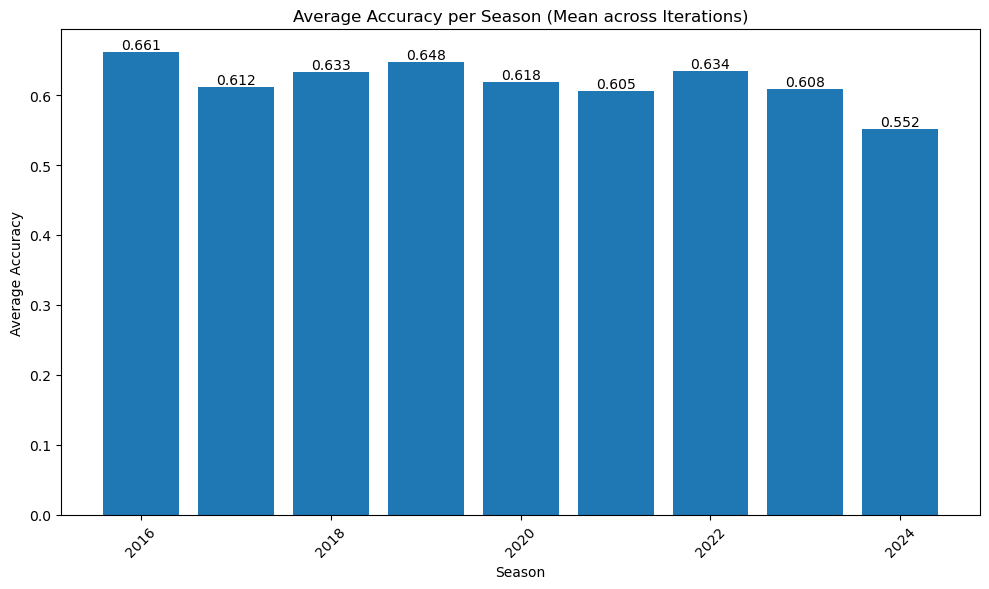

Overall Classification Report (in percentages):
0: {'precision': 59.26, 'recall': 40.62, 'f1-score': 48.2, 'support': 4104.0}

1: {'precision': 64.04, 'recall': 79.35, 'f1-score': 70.88, 'support': 5526.0}

2: {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 30.0}

accuracy: 62.65

macro avg: {'precision': 41.1, 'recall': 39.99, 'f1-score': 39.69, 'support': 9660.0}

weighted avg: {'precision': 61.81, 'recall': 62.65, 'f1-score': 61.02, 'support': 9660.0}



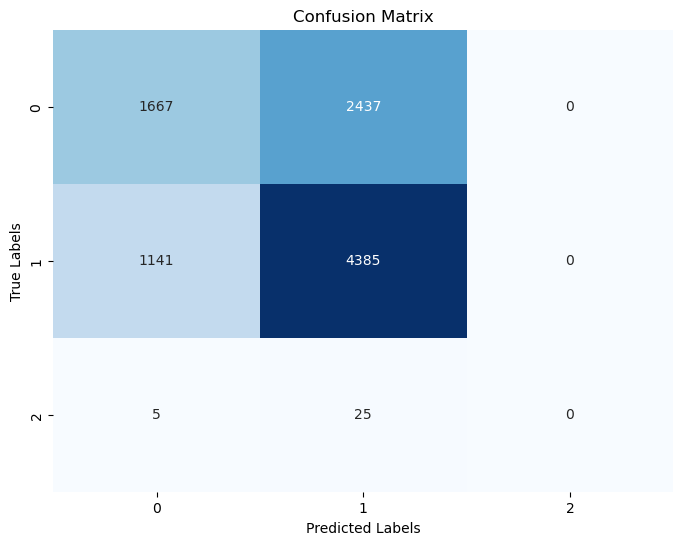

CPU times: total: 2min 16s
Wall time: 39.7 s


['ridge_classifier_model.h5']

In [123]:
%%time

## Machine Learning
removed_columns = ["season", "date", "won", "target", "team", "team_opp"]
removed_columns = list(forcast_df.columns[forcast_df.dtypes == "object"]) + removed_columns
selected_columns = forcast_df.columns[~forcast_df.columns.isin(removed_columns)]
selected_columns = selected_columns[selected_columns != "date_next"]  #Removing "date_next" from the list
# print(selected_columns)

## Data Normalization
scaler = MinMaxScaler()
forcast_df[selected_columns] = scaler.fit_transform(forcast_df[selected_columns])

# Create a Ridge classifier
ridge_classifier = RidgeClassifier()

# Define the TimeSeriesSplit for cross-validation
split = TimeSeriesSplit(n_splits=3)

# Initialize the SequentialFeatureSelector with the RR classifier
sfs = SequentialFeatureSelector(ridge_classifier,  # Use RR as the model
                                n_features_to_select=40,
                                direction="forward",
                                cv=split,
                                n_jobs=1
                                )

# Step 3: Create an empty dictionary to store accuracy results for each year
accuracy_by_year = {}

# Step 4: Create dictionaries to store sum and count of accuracy values for each year
sum_accuracy_by_year = {}
count_accuracy_by_year = {}

def backtest_with_iterative_improvement(data, model, predictors, start=2, step=1, iterations=20):
    all_predictions = []
    seasons = sorted(data["season"].unique())
    
    for iteration in range(iterations):
        print(f"Iteration {iteration + 1}")
        
        if isinstance(model, RidgeClassifier):  # Check if the model is RidgeClassifier
            model.set_params(alpha=0.1 + iteration * 0.1)  # Adapt the hyperparameter 'alpha'
        
        # Initialize the accuracy dictionaries for the current iteration
        accuracy_by_year[iteration + 1] = {}
        sum_accuracy_by_year[iteration + 1] = {}
        count_accuracy_by_year[iteration + 1] = {}
        
        for i in range(start, len(seasons), step):
            season = seasons[i]
            train = data[data["season"] < season]
            test = data[data["season"] == season]

            model.fit(train[predictors], train["target"])
            preds = model.predict(test[predictors])
            preds = pd.Series(preds, index=test.index)
            combined = pd.concat([test["target"], preds], axis=1)
            combined.columns = ["actual", "prediction"]
            all_predictions.append(combined)
            
            # Calculate accuracy for the current year
            accuracy = accuracy_score(combined["actual"], combined["prediction"])
            accuracy_by_year[iteration + 1][season] = accuracy
            
            # Update sum and count of accuracy values for the current year
            if season in sum_accuracy_by_year[iteration + 1]:
                sum_accuracy_by_year[iteration + 1][season] += accuracy
                count_accuracy_by_year[iteration + 1][season] += 1
            else:
                sum_accuracy_by_year[iteration + 1][season] = accuracy
                count_accuracy_by_year[iteration + 1][season] = 1
        
        predictions = pd.concat(all_predictions)
#         predictions = predictions[predictions['actual'] != 2]

        all_predictions = []
        
        # Continue with other steps for each iteration

    return predictions

start = time.time()
sfs.fit(forcast_df[selected_columns], forcast_df["target"])
predictors = list(selected_columns[sfs.get_support()])
print(predictors)
end = time.time()
print(f'{(end - start)/60} mins')

# Call the backtest_with_iterative_improvement function with the accuracy_by_year dictionary
predictions = backtest_with_iterative_improvement(forcast_df, ridge_classifier, predictors)

# List of specific indices you want to see outcomes for
specific_indices1 = [13090, 13030, 13092, 13064, 13087, 13089, 13086, 13067, 13043]
specific_indices2 = [13091, 13052, 13088, 13099, 13094, 13049, 13098]
specific_indices3 = [13096, 13081, 13048, 13077, 13080]

# Filter predictions for specific indices
specific_outcomes1 = predictions[predictions.index.isin(specific_indices1)]
specific_outcomes2 = predictions[predictions.index.isin(specific_indices2)]
specific_outcomes3 = predictions[predictions.index.isin(specific_indices3)]

# Display the outcomes for the specific indices
print(f'{selected_dates1}:')
print(specific_outcomes1)

print(f'{selected_dates2}:')
print(specific_outcomes2)

print(f'{selected_dates3}:')
print(specific_outcomes3)

# Calculate the average accuracy for each year across all iterations
average_accuracy_by_year = {}
for iteration, accuracy_dict in accuracy_by_year.items():
    average_accuracy_by_year[iteration] = {}
    for year, accuracy in accuracy_dict.items():
        average_accuracy_by_year[iteration][year] = sum_accuracy_by_year[iteration][year] / count_accuracy_by_year[iteration][year]

# Extract the years and average accuracies for each iteration
years = list(average_accuracy_by_year[1].keys())
average_accuracies_per_iteration = [average_accuracy_by_year[iteration][year] for iteration in average_accuracy_by_year for year in average_accuracy_by_year[iteration]]

# Reshape the average accuracies to have 10 rows (one row per iteration)
average_accuracies_per_iteration = np.array(average_accuracies_per_iteration).reshape(20, -1)

# Calculate the mean of average accuracies across all iterations for each year
mean_average_accuracies = np.mean(average_accuracies_per_iteration, axis=0)

# Create a bar plot with the mean average accuracy values
plt.figure(figsize=(10, 6))
bars = plt.bar(years, mean_average_accuracies)
plt.xlabel("Season")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy per Season (Mean across Iterations)")
plt.xticks(rotation=45)

# Add text annotations with mean average accuracy values on each bar
for bar, accuracy in zip(bars, mean_average_accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{accuracy:.3f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Calculate the overall classification report
# Assuming you have predictions dictionary with "actual" and "prediction" keys
y_true = predictions["actual"]
y_pred = predictions["prediction"]
overall_classification_report = classification_report(y_true, y_pred, output_dict=True)

# Convert values to percentages and round to 2 decimal places
for class_name, metrics in overall_classification_report.items():
    if class_name not in ["accuracy", "macro avg", "weighted avg"]:
        precision = round(metrics['precision'] * 100, 2)
        recall = round(metrics['recall'] * 100, 2)
        f1_score = round(metrics['f1-score'] * 100, 2)
        support = metrics['support']
        overall_classification_report[class_name] = {
            'precision': precision,
            'recall': recall,
            'f1-score': f1_score,
            'support': support
        }

# Convert macro avg and weighted avg to percentages and round to 2 decimal places
macro_avg = overall_classification_report['macro avg']
macro_avg['precision'] = round(macro_avg['precision'] * 100, 2)
macro_avg['recall'] = round(macro_avg['recall'] * 100, 2)
macro_avg['f1-score'] = round(macro_avg['f1-score'] * 100, 2)

weighted_avg = overall_classification_report['weighted avg']
weighted_avg['precision'] = round(weighted_avg['precision'] * 100, 2)
weighted_avg['recall'] = round(weighted_avg['recall'] * 100, 2)
weighted_avg['f1-score'] = round(weighted_avg['f1-score'] * 100, 2)

# Convert accuracy to percentage and round to 2 decimal places
overall_classification_report['accuracy'] = round(overall_classification_report['accuracy'] * 100, 2)

# Print the modified classification report
print("Overall Classification Report (in percentages):")
for class_name, metrics in overall_classification_report.items():
    print(f"{class_name}: {metrics}")
    print()


# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# Save the trained Ridge classifier model to an h5 file using joblib
model_filename = "ridge_classifier_model.h5"
joblib.dump(ridge_classifier, model_filename)

In [124]:
selected_dates1 = ['30/11/2023']  

todays_games = forcast_df[(forcast_df["target"] == 2) & (forcast_df["date_next"].isin(selected_dates1))][['date_next', 'team', 'team_opp_next']]
result = pd.concat([todays_games, specific_outcomes1], axis=1)

result['live_scores'] = [0,1,0,1,1,1,1,1,0]

print(f'{selected_dates1}:')
print(result)

['30/11/2023']:
        date_next team team_opp_next  actual  prediction  live_scores
13090  30/11/2023  BRK           CHO       2           1            0
13030  30/11/2023  CHI           MIL       2           1            1
13092  30/11/2023  CLE           POR       2           1            0
13064  30/11/2023  GSW           LAC       2           1            1
13087  30/11/2023  MIA           IND       2           1            1
13089  30/11/2023  MIN           UTA       2           1            1
13086  30/11/2023  NYK           DET       2           1            1
13067  30/11/2023  OKC           LAL       2           1            1
13043  30/11/2023  SAS           ATL       2           0            0


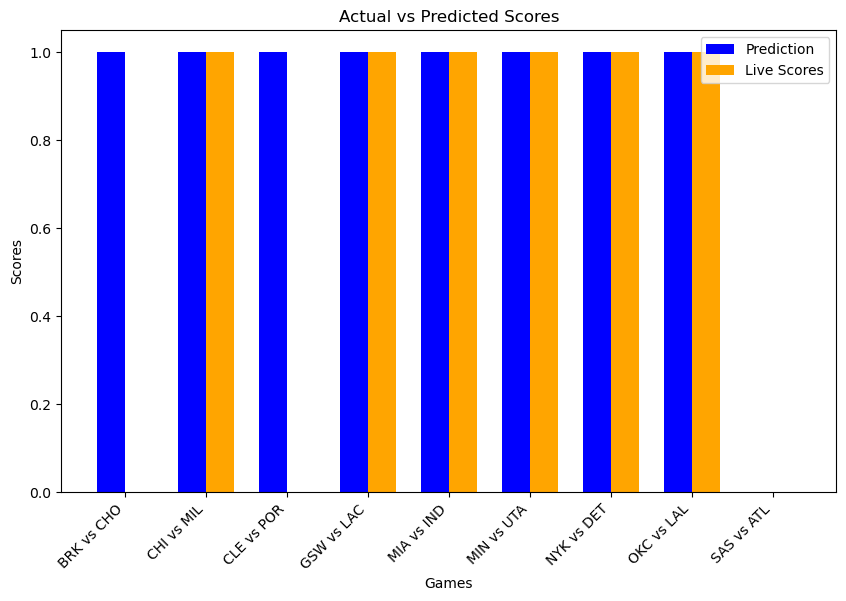

In [125]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Set bar width
bar_width = 0.35

# Set indices for the bars
indices = range(len(result))

# Plot predicted scores in blue
actual_bars = ax.bar(indices, result['prediction'], bar_width, label='Prediction', color='blue')

# Plot live scores in orange
predicted_bars = ax.bar([i + bar_width for i in indices], result['live_scores'], bar_width, label='Live Scores', color='orange')

# Set tick labels
ax.set_xticks([i + bar_width / 2 for i in indices])
ax.set_xticklabels([f"{team} vs {team_opp}" for team, team_opp in zip(result['team'], result['team_opp_next'])], rotation=45, ha="right")

# Set axis labels and title
ax.set_xlabel('Games')
ax.set_ylabel('Scores')
ax.set_title('Actual vs Predicted Scores')

# Show legend
ax.legend()

# Show the plot
plt.show()

In [126]:
tomorrows_games = forcast_df[(forcast_df["target"] == 2) & (forcast_df["date_next"].isin(selected_dates2))][['date_next', 'team', 'team_opp_next']]
result2 = pd.concat([tomorrows_games, specific_outcomes2], axis=1)

result2['live_scores'] = [2,2,2,2,2,2,2]

print(f'{selected_dates2}:')
print(result2)

['01/12/2023']:
        date_next team team_opp_next  actual  prediction  live_scores
13091  01/12/2023  BOS           PHI       2           1            2
13052  01/12/2023  CHO           MIN       2           0            2
13088  01/12/2023  DAL           MEM       2           1            2
13099  01/12/2023  NOP           SAS       2           1            2
13094  01/12/2023  ORL           WAS       2           1            2
13049  01/12/2023  PHO           DEN       2           1            2
13098  01/12/2023  TOR           NYK       2           1            2


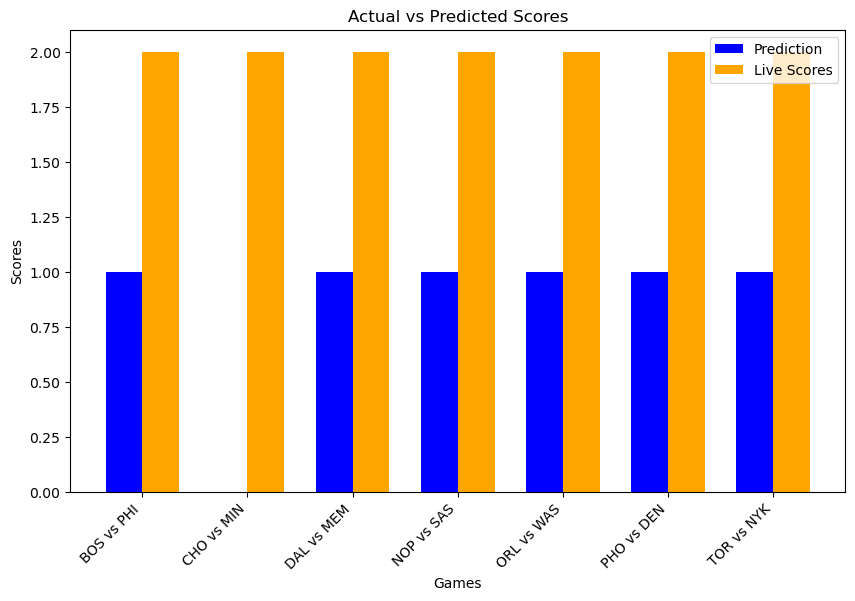

In [127]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Set bar width
bar_width = 0.35

# Set indices for the bars
indices = range(len(result2))

# Plot predicted scores in blue
actual_bars = ax.bar(indices, result2['prediction'], bar_width, label='Prediction', color='blue')

# Plot live scores in orange
predicted_bars = ax.bar([i + bar_width for i in indices], result2['live_scores'], bar_width, label='Live Scores', color='orange')

# Set tick labels
ax.set_xticks([i + bar_width / 2 for i in indices])
ax.set_xticklabels([f"{team} vs {team_opp}" for team, team_opp in zip(result2['team'], result2['team_opp_next'])], rotation=45, ha="right")

# Set axis labels and title
ax.set_xlabel('Games')
ax.set_ylabel('Scores')
ax.set_title('Actual vs Predicted Scores')

# Show legend
ax.legend()

# Show the plot
plt.show()

In [128]:
next_tomorrows_games = forcast_df[(forcast_df["target"] == 2) & (forcast_df["date_next"].isin(selected_dates3))][['date_next', 'team', 'team_opp_next']]
result3 = pd.concat([next_tomorrows_games, specific_outcomes3], axis=1)

result3['live_scores'] = [2, 2, 2, 2, 2]

print(f'{selected_dates3}:')
print(result3)

['02/12/2023']:
        date_next team team_opp_next  actual  prediction  live_scores
13096  02/12/2023  DET           CLE       2           0            2
13081  02/12/2023  LAC           GSW       2           1            2
13048  02/12/2023  LAL           HOU       2           1            2
13077  02/12/2023  MIL           ATL       2           1            2
13080  02/12/2023  UTA           POR       2           1            2


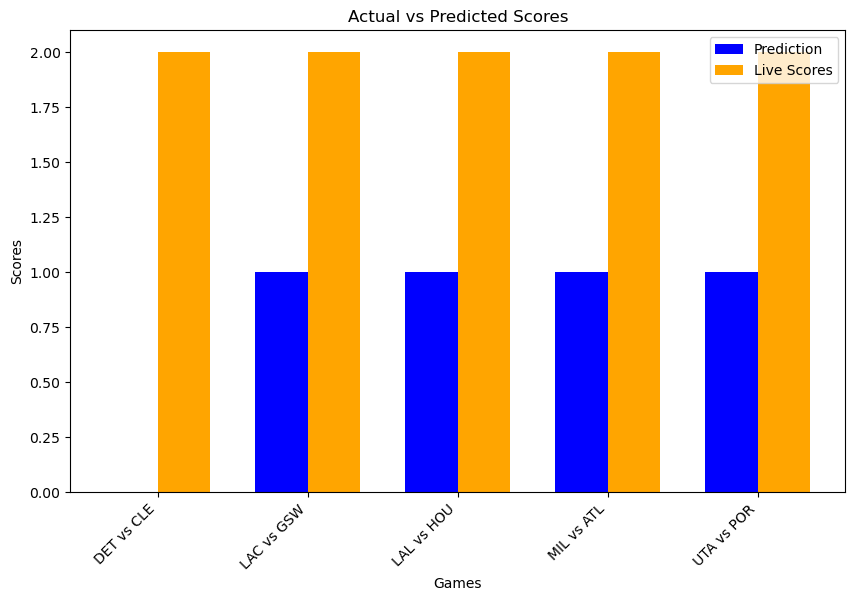

In [129]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Set bar width
bar_width = 0.35

# Set indices for the bars
indices = range(len(result3))

# Plot predicted scores in blue
actual_bars = ax.bar(indices, result3['prediction'], bar_width, label='Prediction', color='blue')

# Plot live scores in orange
predicted_bars = ax.bar([i + bar_width for i in indices], result3['live_scores'], bar_width, label='Live Scores', color='orange')

# Set tick labels
ax.set_xticks([i + bar_width / 2 for i in indices])
ax.set_xticklabels([f"{team} vs {team_opp}" for team, team_opp in zip(result3['team'], result3['team_opp_next'])], rotation=45, ha="right")

# Set axis labels and title
ax.set_xlabel('Games')
ax.set_ylabel('Scores')
ax.set_title('Actual vs Predicted Scores')

# Show legend
ax.legend()

# Show the plot
plt.show()

## Feature Importance

Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
                     Feature  Importance
34              elo_rating_4    0.090206
38  average_points_allowed_4    0.069592
37   average_points_scored_4    0.059927
22      avg_points_allowed_4    0.057152
12              PER_Combined    0.052268
13               win_percent    0.050616
31             win_percent_4    0.047617
6         avg_points_allowed    0.044659
18     average_points_scored    0.034759
21       avg_points_scored_4    0.033717


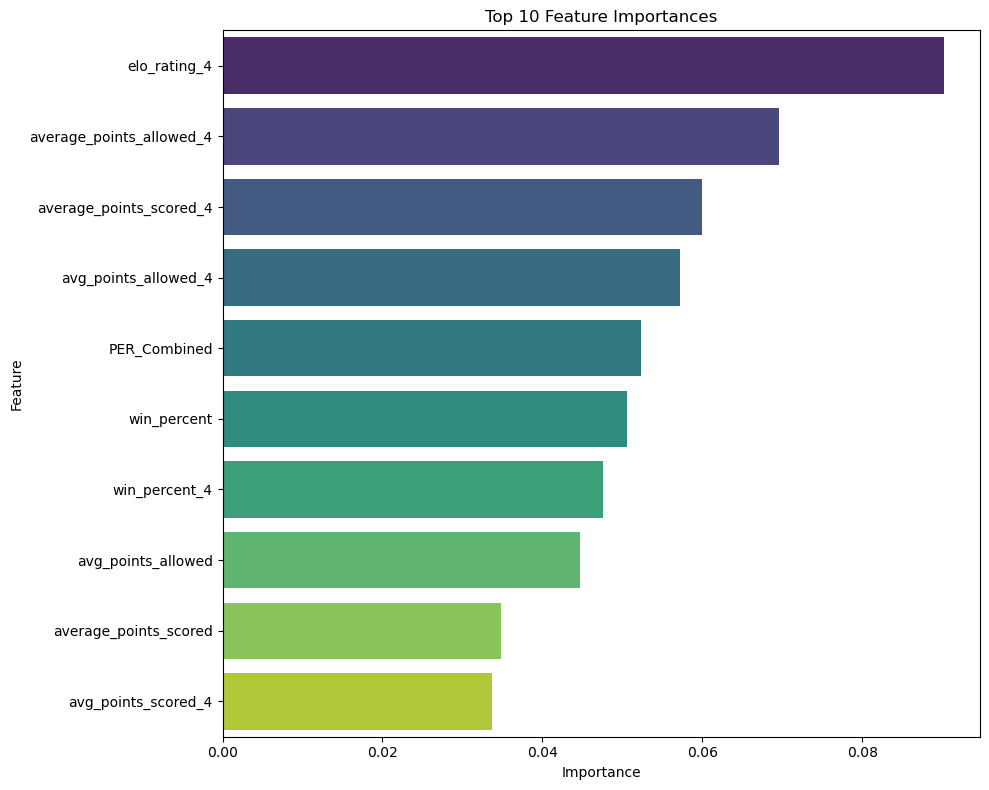

0.06834884484608968 mins


In [110]:
start = time.time()

# Call the backtest_with_iterative_improvement function with the accuracy_by_year dictionary
predictions = backtest_with_iterative_improvement(forcast_df, ridge_classifier, predictors)

# Create an explainer using SHAP
explainer = shap.Explainer(ridge_classifier, forcast_df[predictors])

# Calculate SHAP values for the entire dataset
shap_values = explainer(forcast_df[predictors])

# Get the mean absolute SHAP values for each feature
mean_abs_shap_values = pd.DataFrame(abs(shap_values.values)).mean(axis=0)

# Create a DataFrame to store feature importance scores
feature_importance = pd.DataFrame({"Feature": predictors, "Importance": mean_abs_shap_values})

# Sort the DataFrame by feature importances in descending order
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Print the top 10 features and their importance scores
top_10_features = feature_importance.head(10)
print(top_10_features)

# Create a horizontal bar plot to visualize the top 10 feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=top_10_features, palette="viridis")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

end = time.time()
print(f'{(end - start)/60} mins')

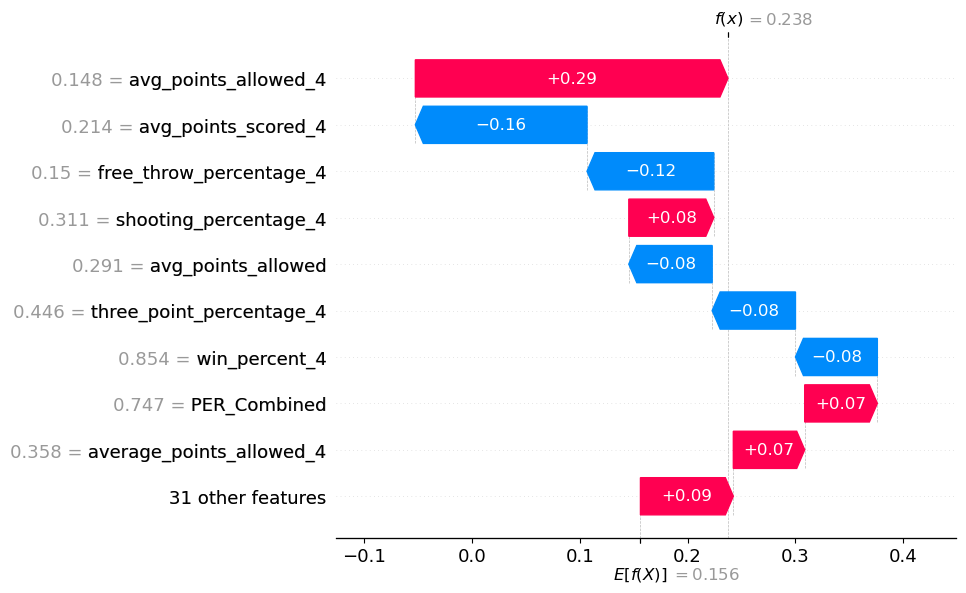

In [111]:
explainer = shap.Explainer(ridge_classifier, forcast_df[predictors])
shap_values = explainer(forcast_df[predictors])
instance_index = 0  # Change this to the index of the instance you want to explain
shap.plots.waterfall(shap_values[instance_index], max_display=10)  # Change max_display as needed